<a href="https://colab.research.google.com/github/rafaelnordavind/IGTIExemplo/blob/master/UnificacaoDadosTI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Unificação de dados relevantes



## 01 - Coleta dos dados


### Dados gerais de servidores (cadastro e remuneração)


Fonte: https://portaldatransparencia.gov.br/download-de-dados/servidores

In [ ]:
import os
import requests
from zipfile import ZipFile
import pandas as pd
from decimal import Decimal, ROUND_HALF_UP

month_ref = "11"
year_ref = "2024"

url = f"https://dadosabertos-download.cgu.gov.br/PortalDaTransparencia/saida/servidores/{year_ref}{month_ref}_Servidores_SIAPE.zip"

zip_file_path = f"{year_ref}{month_ref}_Servidores_SIAPE.zip"

# Caminho para extrair os arquivos
extracted_folder_path = "servidores_data_src"

if not os.path.isfile(zip_file_path):
  print("Arquivo não se encontra no ambiente, baixando...")
  # Fazer o download do arquivo ZIP
  response = requests.get(url)
  with open(zip_file_path, 'wb') as zip_file:
      zip_file.write(response.content)

# Extrair o conteúdo do arquivo ZIP
with ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_folder_path)

# Lista os arquivos extraídos
extracted_files = sorted(os.listdir(extracted_folder_path))
print(extracted_files)

# Criar dataframes pandas para cada planilha
dataframes = []
for file_name in extracted_files:
    if file_name.endswith('.csv'):
        file_path = os.path.join(extracted_folder_path, file_name)
        df = pd.read_csv(file_path, encoding='latin-1', delimiter=';', low_memory=False)
        dataframes.append(df)

if dataframes:
    print("Dataframes carregados")
else:
    print("Nenhum dataframe foi carregado.")

# Dataframes para cada planilha
df_afastamentos = dataframes[0]
df_cadastro = dataframes[1]
df_observacoes = dataframes[2]
df_remuneracao = dataframes[3]

['202411_Afastamentos.csv', '202411_Cadastro.csv', '202411_Observacoes.csv', '202411_Remuneracao.csv']
Dataframes carregados


#### Filtros iniciais e testes para visualização dos dataframes

In [ ]:
# Imprimindo as duas primeiras linhas do dataframe para conferência
print(df_afastamentos.head(2))
# Imprimindo as colunas do dataframe
df_afastamentos.columns

    ANO  MES  Id_SERVIDOR_PORTAL             CPF                        NOME  \
0  2024   11             3240164  ***.976.801-**       ABADIA VIEIRA CALACIA   
1  2024   11             1015463  ***.168.611-**  ADAIL DE CASTRO CAVALHEIRO   

  DATA_INICIO_AFASTAMENTO DATA_FIM_AFASTAMENTO  
0              01/11/2024           01/11/2024  
1              12/11/2024           12/11/2024  


Index(['ANO', 'MES', 'Id_SERVIDOR_PORTAL', 'CPF', 'NOME',
       'DATA_INICIO_AFASTAMENTO', 'DATA_FIM_AFASTAMENTO'],
      dtype='object')

In [ ]:
# Imprimindo as duas primeiras linhas do dataframe para conferência
print(df_cadastro.head(2))
# Filtrando apenas o vinculo CARGO, excluindo função
df_cadastro = df_cadastro[df_cadastro['TIPO_VINCULO'].isin(["Cargo"])]
# Imprimindo as colunas do dataframe
# df_cadastro.dtypes
df_cadastro

   Id_SERVIDOR_PORTAL                        NOME             CPF MATRICULA  \
0             3174964  AARAO CARLOS LUZ MACAMBIRA  ***.017.623-**   016****   
1             2903139    AARAO FERREIRA LIMA NETO  ***.116.132-**   014****   

                DESCRICAO_CARGO CLASSE_CARGO  REFERENCIA_CARGO PADRAO_CARGO  \
0  BIBLIOTECARIO-DOCUMENTALISTA            E               0.0          411   
1                  Sem informaç          NaN              -1.0           -1   

   NIVEL_CARGO SIGLA_FUNCAO  ...  JORNADA_DE_TRABALHO  \
0          0.0           -1  ...    40 HORAS SEMANAIS   
1         -1.0           CD  ...  DEDICACAO EXCLUSIVA   

  DATA_INGRESSO_CARGOFUNCAO  DATA_NOMEACAO_CARGOFUNCAO DATA_INGRESSO_ORGAO  \
0                11/02/2009                        NaN          29/12/2008   
1                21/10/2024                        NaN          24/07/2006   

  DOCUMENTO_INGRESSO_SERVICOPUBLICO  DATA_DIPLOMA_INGRESSO_SERVICOPUBLICO  \
0                               699     

,Id_SERVIDOR_PORTAL,NOME,CPF,MATRICULA,DESCRICAO_CARGO,CLASSE_CARGO,REFERENCIA_CARGO,PADRAO_CARGO,NIVEL_CARGO,SIGLA_FUNCAO,...,JORNADA_DE_TRABALHO,DATA_INGRESSO_CARGOFUNCAO,DATA_NOMEACAO_CARGOFUNCAO,DATA_INGRESSO_ORGAO,DOCUMENTO_INGRESSO_SERVICOPUBLICO,DATA_DIPLOMA_INGRESSO_SERVICOPUBLICO,DIPLOMA_INGRESSO_CARGOFUNCAO,DIPLOMA_INGRESSO_ORGAO,DIPLOMA_INGRESSO_SERVICOPUBLICO,UF_EXERCICIO
0,3174964,AARAO CARLOS LUZ MACAMBIRA,***.017.623-**,016****,BIBLIOTECARIO-DOCUMENTALISTA,E,0.0,411,0.0,-1,...,40 HORAS SEMANAIS,11/02/2009,NaN,29/12/2008,699,11/02/2009,NaN,LEI,PORTARIA,CE
2,2903139,AARAO FERREIRA LIMA NETO,***.116.132-**,014****,PROFESSOR DO MAGISTERIO SUPERIOR,7,0.0,NaN,702.0,-1,...,DEDICACAO EXCLUSIVA,01/03/2013,NaN,24/07/2006,2475,16/08/2006,NaN,PORTARIA,PORTARIA,-1
3,2868174,AARAO MEIR SERRUYA,***.693.832-**,033****,FISIOTERAPEUTA - 30H,S,0.0,NaN,201.0,-1,...,30 HORAS SEMANAIS,07/12/2022,NaN,07/12/2022,NaN,NaN,NaN,CONTRATO,Inválido,-1
4,3137242,AARAO PEREIRA DE ARAUJO JUNIOR,***.031.184-**,002****,PROFESSOR ENS BASICO TECN TECNOLOGICO,D,0.0,NaN,501.0,-1,...,DEDICACAO EXCLUSIVA,01/03/2013,NaN,29/12/2008,000000124,03/05/1993,NaN,LEI,PORTARIA,PB
5,3205874,AARAO SOARES,***.859.807-**,014****,AGENTE DE COMBATE AS ENDEMIAS,S,0.0,V,0.0,-1,...,40 HORAS SEMANAIS,04/09/2014,NaN,04/09/2014,13026,04/09/2014,NaN,LEI,LEI,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763946,-11,Sigiloso,NaN,001****,Sigiloso,NaN,NaN,NaN,NaN,-11,...,Sem informaç,NaN,NaN,NaN,NaN,NaN,NaN,Sem informaç,Sem informaç,-1
763947,-11,Sigiloso,NaN,001****,Sigiloso,NaN,NaN,NaN,NaN,-11,...,Sem informaç,NaN,NaN,NaN,NaN,NaN,NaN,Sem informaç,Sem informaç,-1
763948,-11,Sigiloso,NaN,001****,Sigiloso,NaN,NaN,NaN,NaN,-11,...,Sem informaç,NaN,NaN,NaN,NaN,NaN,NaN,Sem informaç,Sem informaç,-1
763949,-11,Sigiloso,NaN,003****,Sigiloso,NaN,NaN,NaN,NaN,-11,...,Sem informaç,NaN,NaN,NaN,NaN,NaN,NaN,Sem informaç,Sem informaç,-1


In [ ]:
# Imprimindo as duas primeiras linhas do dataframe para conferência
print(df_observacoes.head(2))
# Imprimindo as colunas do dataframe
df_observacoes.columns

    ANO  MES  Id_SERVIDOR_PORTAL                   NOME             CPF  \
0  2024   11             2352265  ABDON MOREIRA LUSTOSA  ***.716.344-**   
1  2024   11             2212875     ABDON TAVARES REIS  ***.523.941-**   

                                          OBSERVACAO  
0  SERVIDOR PERCEBE PARCELA REMUNERATORIA NAO INC...  
1  OS VALORES DEMONSTRADOS ACIMA INCLUEM REMUNERA...  


Index(['ANO', 'MES', 'Id_SERVIDOR_PORTAL', 'NOME', 'CPF', 'OBSERVACAO'], dtype='object')

In [ ]:
# Imprimindo as duas primeiras linhas do dataframe para conferência
print(df_remuneracao.head(2))

# Convertendo o valor da remuneração para o tipo decimal com apenas duas casas decimais para permitir cálculos monetários com mais precisão
df_remuneracao = df_remuneracao.dropna(subset=['Id_SERVIDOR_PORTAL', 'MES'], how='any')
df_remuneracao['REMUNERAÇÃO BÁSICA BRUTA (R$)'] = df_remuneracao['REMUNERAÇÃO BÁSICA BRUTA (R$)'].str.replace(',', '.').apply(lambda x: Decimal(x).quantize(Decimal('0.00')))
df_remuneracao['Id_SERVIDOR_PORTAL'] = df_remuneracao['Id_SERVIDOR_PORTAL'].astype(int)
df_remuneracao['MES'] = df_remuneracao['MES'].astype(int)
#df_remuneracao.dtypes
#df_remuneracao.columns
df_remuneracao

    ANO   MES  Id_SERVIDOR_PORTAL             CPF                        NOME  \
0  2024  11.0           3174964.0  ***.017.623-**  AARAO CARLOS LUZ MACAMBIRA   
1  2024  11.0           2903139.0  ***.116.132-**    AARAO FERREIRA LIMA NETO   

  REMUNERAÇÃO BÁSICA BRUTA (R$) REMUNERAÇÃO BÁSICA BRUTA (U$) ABATE-TETO (R$)  \
0                       9741,30                          0,00            0,00   
1                      23008,10                          0,00            0,00   

  ABATE-TETO (U$) GRATIFICAÇÃO NATALINA (R$)  ...  \
0            0,00                    9741,30  ...   
1            0,00                   23008,10  ...   

  REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (R$)  \
0                                     9500,15   
1                                    23071,72   

  REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (U$)  \
0                                        0,00   
1                                        0,00   

  VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSO

<ipython-input-6-5b9a0b4114f8>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_remuneracao['REMUNERAÇÃO BÁSICA BRUTA (R$)'] = df_remuneracao['REMUNERAÇÃO BÁSICA BRUTA (R$)'].str.replace(',', '.').apply(lambda x: Decimal(x).quantize(Decimal('0.00')))
<ipython-input-6-5b9a0b4114f8>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_remuneracao['Id_SERVIDOR_PORTAL'] = df_remuneracao['Id_SERVIDOR_PORTAL'].astype(int)
<ipython-input-6-5b9a0b4114f8>:8: SettingWithCopyWarning: 
A value is trying to be set on 

,ANO,MES,Id_SERVIDOR_PORTAL,CPF,NOME,REMUNERAÇÃO BÁSICA BRUTA (R$),REMUNERAÇÃO BÁSICA BRUTA (U$),ABATE-TETO (R$),ABATE-TETO (U$),GRATIFICAÇÃO NATALINA (R$),...,REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (R$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (U$),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (U$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (U$)(*),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (R$),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (U$),TOTAL DE VERBAS INDENIZATÓRIAS (R$)(*),TOTAL DE VERBAS INDENIZATÓRIAS (U$)(*)
0,2024,11,3174964,***.017.623-**,AARAO CARLOS LUZ MACAMBIRA,9741.30,"0,00","0,00","0,00","9741,30",...,"9500,15","0,00","1316,75","0,00","0,00","0,00","0,00","0,00","1316,75","0,00"
1,2024,11,2903139,***.116.132-**,AARAO FERREIRA LIMA NETO,23008.10,"0,00","0,00","0,00","23008,10",...,"23071,72","0,00","1000,00","0,00","0,00","0,00","0,00","0,00","1000,00","0,00"
2,2024,11,3137242,***.031.184-**,AARAO PEREIRA DE ARAUJO JUNIOR,22898.13,"0,00","0,00","0,00","26189,52",...,"23753,78","0,00","1397,38","0,00","0,00","0,00","0,00","0,00","1397,38","0,00"
3,2024,11,3205874,***.859.807-**,AARAO SOARES,6427.49,"0,00","0,00","0,00","6427,49",...,"7060,20","0,00","7108,37","0,00","0,00","0,00","0,00","0,00","7108,37","0,00"
4,2024,11,3449428,***.086.942-**,AARAO TEIXEIRA DOS SANTOS,6081.74,"0,00","0,00","0,00","6081,74",...,"6597,81","0,00","1542,24","0,00","0,00","0,00","0,00","0,00","1542,24","0,00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522736,2024,11,1103719,***.846.893-**,ZUZILENE DA SILVA EVANGELISTA,6681.70,"0,00","0,00","0,00","6681,70",...,"10160,82","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00"
522737,2024,11,1215374,***.041.463-**,ZUZITA DOS SANTOS VIANA,10541.32,"0,00","0,00","0,00","11797,40",...,"11788,76","0,00","1000,00","0,00","0,00","0,00","0,00","0,00","1000,00","0,00"
522738,2024,11,110228,***.058.252-**,ZYON OLIVEIRA ALBUQUERQUE,2676.24,"0,00","0,00","0,00","2676,24",...,"5156,37","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00"
522739,2024,11,3858823,***.226.094-**,ZYOON IBEVILLY ANDRADE CIPRIANO,0.00,"0,00","0,00","0,00","0,00",...,"696,05","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00"


### Obtendo a área do cargo de Técnico de Laboratório

Obs.: Esses dados foram coletados a partir de busca no Diário oficial da nomeação do servidor utilizando o nome do servidor e a data em que entrou no referido cargo.

Os dados de aproximadamente 40% dos servidores do cargo de técnico de laboratório área foram coletados.

**URL do estudo:**
https://drive.google.com/drive/folders/1yz4ikF77bOHVl3sDaDgLMGAtEdxGhKY3


---


Favor baixar o csv em: https://docs.google.com/spreadsheets/d/1sHvafdta4hAuHNVQklvjrZZFJ0ybVHE0YECg83M8_ZI/edit#gid=1368145627 e realizar o upload neste notebook python.

In [ ]:
import requests

def csv_from_gsheet(sheet_id, gid='0', filename='file.csv'):
  """
  Baixa um arquivo CSV de uma planilha Google.

  Args:
    sheet_id: O ID da planilha Google.
    gid: O ID da aba da planilha.
    filename: O nome do arquivo CSV a ser salvo.
  """

  url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

  response = requests.get(url)
  response.raise_for_status()  # Lança uma exceção para erros de HTTP

  with open(filename, "wb") as f:
    f.write(response.content)

In [ ]:
import os
import pandas as pd
from google.colab import files

fn = 'tlab_dou - tlab_dou.csv'
csv_from_gsheet('1sHvafdta4hAuHNVQklvjrZZFJ0ybVHE0YECg83M8_ZI',
                '1368145627',
                filename=fn)
if not os.path.isfile(fn):
  uploaded = files.upload()

  for fn in uploaded.keys():
    print('Arquivo "{name}" com {length} bytes foi enviado'.format(
        name=fn, length=len(uploaded[fn])))

# Lendo o arquivo
df_tlab_dou = pd.read_csv(fn)

df_tlab_dou


,Id_SERVIDOR_PORTAL,NOME_x,CARGO_AREA,UORG,ORG,DATA_INGRESSO_CARGOFUNCAO,RESULTADO,URL_NOMEACAO
0,310760284.0,ABDIAS PIRES DE ALMEIDA FILHO,NaN,CENTRO DE CIENCIAS DA SAUDE,Universidade Federal da Paraíba,01/03/2005,[' E I 13 332997 <font color=black><b>ABDI...,['http://pesquisa.in.gov.br/imprensa/jsp/visua...
1,311461371.0,ABEL BARBOSA LIRA NETO,ANATOMIA E NECRÓPSIA,CAMPUS ARAPIRACA,Universidade Federal de Alagoas,10/09/2013,"[' Classe D, Nível I, em regime de 40h (quare...",['http://pesquisa.in.gov.br/imprensa/jsp/visua...
2,310166769.0,ABENE SILVA RIBEIRO,QUÍMICA,DEPART DE QUIMICA FUNDAMENTAL - CCEN,Universidade Federal de Pernambuco,02/05/2008,[' No - 490 - Nomear <font color=black><b>A...,['http://pesquisa.in.gov.br/imprensa/jsp/visua...
3,311634045.0,ABINADABIS PARENTES MENDES,ANÁLISE CLÍNICA,COORDENACAO ADMINISTRATIVO ISB,Fundação Universidade Federal do Amazonas,09/06/2017,[' Nome C a rg o Local <font color=black...,['http://pesquisa.in.gov.br/imprensa/jsp/visua...
4,310777830.0,ABRAAO DE SOUZA LOPES,INFORMÁTICA,DEPTO DE ENSINO PESQ E EXTENSAO HUMAITA,Instituto Federal do Amazonas,23/02/2015,"[' horas semanais, em vaga distribuída através...",['http://pesquisa.in.gov.br/imprensa/jsp/visua...
...,...,...,...,...,...,...,...,...
10209,310006865.0,ZILMARA VIEIRA PEDROSA,NaN,INST. DE PESQ. FARMACOS E MEDICAMENTOS,Universidade Federal da Paraíba,18/10/2011,[' HUMANOS PORTARIAS DE 19 DE OUTUBRO DE 20...,['http://pesquisa.in.gov.br/imprensa/jsp/visua...
10210,311978688.0,ZORAIDE NASCIMENTO DA SILVA,NaN,DEPARTAMENTO DE BROMATOLOGIA,Universidade Federal Fluminense - RJ,01/03/2005,[' DANTAS RIBEIRO S I 1366063 <font color=b...,['http://pesquisa.in.gov.br/imprensa/jsp/visua...
10211,310925271.0,ZOZILENE NASCIMENTO SANTOS TELES,PATOLOGIA CLINICA,NUC GEST TEC ESPECIFICO-CCAAB,Universidade Federal do Recôncavo da Bahia,30/11/2006,"[' (qua- renta) horas semanais, <font color=bl...",['http://pesquisa.in.gov.br/imprensa/jsp/visua...
10212,309904741.0,ZOZIMO ORACTZ NETO,NaN,HC/DAS/UAD/AC - SECAO DE BACTERIOLOGIA,Universidade Federal do Paraná,01/03/2005,[' S III 11 6 1 4 2 6 <font color=black><b>...,['http://pesquisa.in.gov.br/imprensa/jsp/visua...


### Obtendo a área do cargo de Tecnólogo Formação

Obs.: Esses dados foram coletados a partir de busca no Diário oficial da nomeação do servidor utilizando o nome do servidor e a data em que entrou no referido cargo.

Os dados de aproximadamente 60% dos servidores do cargo de Tecnólogo Formação área foram coletados.

**URL do estudo:**
https://drive.google.com/drive/folders/1CubbXFVvzi7yZXePiEOmtjjlQgTFN_cD


---


Favor baixar o csv em: https://docs.google.com/spreadsheets/d/17qnHdojHnaW9Fgf9nqggaNmx8cA8QUSNTTXpclZ6dpI/edit#gid=1246209288 e realizar o upload neste notebook python.

In [ ]:
import os
import pandas as pd
from google.colab import files

fn = 'tecn_dou - tecn_dou.csv'
csv_from_gsheet('17qnHdojHnaW9Fgf9nqggaNmx8cA8QUSNTTXpclZ6dpI',
                '1246209288',
                filename=fn)
if not os.path.isfile(fn):
  uploaded = files.upload()

  for fn in uploaded.keys():
    print('Arquivo "{name}" com {length} bytes foi enviado'.format(
        name=fn, length=len(uploaded[fn])))

# Lendo o arquivo
df_tecn_dou = pd.read_csv(fn)

df_tecn_dou

,Id_SERVIDOR_PORTAL,NOME_x,CARGO_AREA,UORG,ORG,DATA_INGRESSO_CARGOFUNCAO,RESULTADO,URL_NOMEACAO,Unnamed: 8,Unnamed: 9
0,313105404,ADA GUAGLIARDI FARIA,GOVERNANÇA DE TECNOLOGIA DA INFORMAÇÃO,DIRETORIA DE INOV.ADM.PUBLICA/RT,Instituto Federal do Rio de Janeiro,07/03/2016,"[' em concurso público, <font color=black><...",['https://pesquisa.in.gov.br/imprensa/jsp/visu...,NaN,NaN
1,310119220,ADAO MAXIMILIANO DE SOUZA REGIS,GESTÃO DE RECURSOS HUMANOS,PARAGOMINAS/COORD. DE GESTÃO DE PESSOAS,Instituto Federal do Pará,07/10/2021,"[""Designar o servidor <span class='highlight' ...",['https://www.in.gov.br/web/dou/-/portarias-de...,NaN,NaN
2,311501843,ADEILTON DE SOUSA MENEZES,GESTÃO PÚBLICA,COORD DE ADM E INFRAESTRUTURA - ALM,Instituto Federal do Norte de Minas Gerais,15/10/2021,"[""a pedido, a contar de 15 de outubro de 2021,...",['https://www.in.gov.br/web/dou/-/portaria-n-3...,NaN,NaN
3,311446518,ADELAINE SILVA NOGUEIRA,GESTÃO DE PESSOAS,COORDENACAO DE GESTAO DE PESSOAS - JAN,Instituto Federal do Norte de Minas Gerais,08/03/2017,[' candidato Código da Vaga <font color=bla...,['https://pesquisa.in.gov.br/imprensa/jsp/visu...,NaN,NaN
4,310320174,ADELIA MARA BELEM LIMA,FARMÁCIA ANÁLISE DE AGENTES DOPANTES NÃO,NUCLEO DE BIOLOGIA ESTRUTURAL E BIOIMAGE,Universidade Federal do Rio de Janeiro,25/08/2014,[' pelo Reitor da Universidade Federal do Rio ...,['https://pesquisa.in.gov.br/imprensa/jsp/visu...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
912,310580735,YULIAN SILVA MORAES,CONTROLE DE OBRAS CONSTUÇÕES,DIRETORIA DE GESTAO DE INFRAESTRUTURA,Instituto Federal do Maranhão,28/04/2015,"[' nº 161, de 21 de maio de 2014, DOU de 22 de...",['https://pesquisa.in.gov.br/imprensa/jsp/visu...,NaN,NaN
913,310814937,YURI VINICIUS SILVA,NaN,"PRO-REITORIA DE EXTENSAO,CULTURA E ASSUN",Fundação Universidade Federal do Tocantins,24/01/2018,"[""Nº 60 - Nomear, na forma do artigo 9º, incis...",['https://www.in.gov.br/web/dou/-/portarias-de...,NaN,NaN
914,312822174,ZELINDA CRISLAYNE DE SOUZA,GESTÃO DE PESSOAS,PRO-REITORIA DE GESTAO DE PESSOAS,Instituto Federal do Norte de Minas Gerais,01/02/2018,"[' I, da Lei nº 8.112, <font color=black><b>de...",['https://pesquisa.in.gov.br/imprensa/jsp/visu...,NaN,NaN
915,313300592,ZENILTON JOSE DA ROCHA,GESTÃO PÚBLICA,COORDENADORIA DE GESTAO DE PESSOAS,Instituto Federal de São Paulo,23/04/2019,"[""definitivo, de acordo com os artigos 9° e 10...",['https://www.in.gov.br/web/dou/-/portarias-de...,NaN,NaN


### Dados de remuneração do PCCTAE

Fonte: https://www.planalto.gov.br/ccivil_03/_ato2004-2006/2005/lei/anexo/AnexoI-Lei11091.htm

In [ ]:

niveis_dict = {
    "A101": 1446.12,
    "A102": 1502.52,
    "A103": 1561.12,
    "A104": 1622.01,
    "A105": 1685.26,
    "A106": 1750.99,
    "A107": 1819.28,
    "A108": 1890.22,
    "A109": 1963.95,
    "A110": 2040.55,
    "A111": 2120.13,
    "A112": 2202.80,
    "A113": 2288.72,
    "A114": 2377.98,
    "A115": 2470.71,
    "A116": 2567.08,
    "A201": 1502.52,
    "A202": 1561.12,
    "A203": 1622.01,
    "A204": 1685.26,
    "A205": 1750.99,
    "A206": 1819.28,
    "A207": 1890.22,
    "A208": 1963.95,
    "A209": 2040.55,
    "A210": 2120.13,
    "A211": 2202.80,
    "A212": 2288.72,
    "A213": 2377.98,
    "A214": 2470.71,
    "A215": 2567.08,
    "A216": 2667.19,
    "A301": 1561.12,
    "A302": 1622.01,
    "A303": 1685.26,
    "A304": 1750.99,
    "A305": 1819.28,
    "A306": 1890.22,
    "A307": 1963.95,
    "A308": 2040.55,
    "A309": 2120.13,
    "A310": 2202.80,
    "A311": 2288.72,
    "A312": 2377.98,
    "A313": 2470.71,
    "A314": 2567.08,
    "A315": 2667.19,
    "A316": 2771.22,
    "A401": 1622.01,
    "A402": 1685.26,
    "A403": 1750.99,
    "A404": 1819.28,
    "A405": 1890.22,
    "A406": 1963.95,
    "A407": 2040.55,
    "A408": 2120.13,
    "A409": 2202.80,
    "A410": 2288.72,
    "A411": 2377.98,
    "A412": 2470.71,
    "A413": 2567.08,
    "A414": 2667.19,
    "A415": 2771.22,
    "A416": 2879.29,
    "B101": 1750.99,
    "B102": 1819.28,
    "B103": 1890.22,
    "B104": 1963.95,
    "B105": 2040.55,
    "B106": 2120.13,
    "B107": 2202.80,
    "B108": 2288.72,
    "B109": 2377.98,
    "B110": 2470.71,
    "B111": 2567.08,
    "B112": 2667.19,
    "B113": 2771.22,
    "B114": 2879.29,
    "B115": 2991.58,
    "B116": 3108.25,
    "B201": 1819.28,
    "B202": 1890.22,
    "B203": 1963.95,
    "B204": 2040.55,
    "B205": 2120.13,
    "B206": 2202.80,
    "B207": 2288.72,
    "B208": 2377.98,
    "B209": 2470.71,
    "B210": 2567.08,
    "B211": 2667.19,
    "B212": 2771.22,
    "B213": 2879.29,
    "B214": 2991.58,
    "B215": 3108.25,
    "B216": 3229.47,
    "B301": 1890.22,
    "B302": 1963.95,
    "B303": 2040.55,
    "B304": 2120.13,
    "B305": 2202.80,
    "B306": 2288.72,
    "B307": 2377.98,
    "B308": 2470.71,
    "B309": 2567.08,
    "B310": 2667.19,
    "B311": 2771.22,
    "B312": 2879.29,
    "B313": 2991.58,
    "B314": 3108.25,
    "B315": 3229.47,
    "B316": 3355.42,
    "B401": 1963.95,
    "B402": 2040.55,
    "B403": 2120.13,
    "B404": 2202.80,
    "B405": 2288.72,
    "B406": 2377.98,
    "B407": 2470.71,
    "B408": 2567.08,
    "B409": 2667.19,
    "B410": 2771.22,
    "B411": 2879.29,
    "B412": 2991.58,
    "B413": 3108.25,
    "B414": 3229.47,
    "B415": 3355.42,
    "B416": 3486.29,
    "C101": 2120.13,
    "C102": 2202.80,
    "C103": 2288.72,
    "C104": 2377.98,
    "C105": 2470.71,
    "C106": 2567.08,
    "C107": 2667.19,
    "C108": 2771.22,
    "C109": 2879.29,
    "C110": 2991.58,
    "C111": 3108.25,
    "C112": 3229.47,
    "C113": 3355.42,
    "C114": 3486.29,
    "C115": 3622.26,
    "C116": 3763.52,
    "C201": 2202.80,
    "C202": 2288.72,
    "C203": 2377.98,
    "C204": 2470.71,
    "C205": 2567.08,
    "C206": 2667.19,
    "C207": 2771.22,
    "C208": 2879.29,
    "C209": 2991.58,
    "C210": 3108.25,
    "C211": 3229.47,
    "C212": 3355.42,
    "C213": 3486.29,
    "C214": 3622.26,
    "C215": 3763.52,
    "C216": 3910.30,
    "C301": 2288.72,
    "C302": 2377.98,
    "C303": 2470.71,
    "C304": 2567.08,
    "C305": 2667.19,
    "C306": 2771.22,
    "C307": 2879.29,
    "C308": 2991.58,
    "C309": 3108.25,
    "C310": 3229.47,
    "C311": 3355.42,
    "C312": 3486.29,
    "C313": 3622.26,
    "C314": 3763.52,
    "C315": 3910.30,
    "C316": 4062.80,
    "C401": 2377.98,
    "C402": 2470.71,
    "C403": 2567.08,
    "C404": 2667.19,
    "C405": 2771.22,
    "C406": 2879.29,
    "C407": 2991.58,
    "C408": 3108.25,
    "C409": 3229.47,
    "C410": 3355.42,
    "C411": 3486.29,
    "C412": 3622.26,
    "C413": 3763.52,
    "C414": 3910.30,
    "C415": 4062.80,
    "C416": 4221.24,
    "D101": 2667.19,
    "D102": 2771.22,
    "D103": 2879.29,
    "D104": 2991.58,
    "D105": 3108.25,
    "D106": 3229.47,
    "D107": 3355.42,
    "D108": 3486.28,
    "D109": 3622.25,
    "D110": 3763.52,
    "D111": 3910.29,
    "D112": 4062.80,
    "D113": 4221.24,
    "D114": 4385.87,
    "D115": 4556.92,
    "D116": 4734.64,
    "D201": 2771.21,
    "D202": 2879.29,
    "D203": 2991.58,
    "D204": 3108.25,
    "D205": 3229.47,
    "D206": 3355.42,
    "D207": 3486.28,
    "D208": 3622.25,
    "D209": 3763.52,
    "D210": 3910.29,
    "D211": 4062.80,
    "D212": 4221.24,
    "D213": 4385.87,
    "D214": 4556.92,
    "D215": 4734.64,
    "D216": 4919.29,
    "D301": 2879.29,
    "D302": 2991.58,
    "D303": 3108.25,
    "D304": 3229.47,
    "D305": 3355.42,
    "D306": 3486.28,
    "D307": 3622.25,
    "D308": 3763.52,
    "D309": 3910.29,
    "D310": 4062.80,
    "D311": 4221.24,
    "D312": 4385.87,
    "D313": 4556.92,
    "D314": 4734.64,
    "D315": 4919.29,
    "D316": 5111.15,
    "D401": 2991.58,
    "D402": 3108.25,
    "D403": 3229.47,
    "D404": 3355.42,
    "D405": 3486.28,
    "D406": 3622.25,
    "D407": 3763.52,
    "D408": 3910.29,
    "D409": 4062.80,
    "D410": 4221.24,
    "D411": 4385.87,
    "D412": 4556.92,
    "D413": 4734.64,
    "D414": 4919.29,
    "D415": 5111.15,
    "D416": 5310.48,
    "E101": 4556.92,
    "E102": 4734.64,
    "E103": 4919.29,
    "E104": 5111.14,
    "E105": 5310.48,
    "E106": 5517.59,
    "E107": 5732.77,
    "E108": 5956.35,
    "E109": 6188.65,
    "E110": 6430.01,
    "E111": 6680.78,
    "E112": 6941.33,
    "E113": 7212.04,
    "E114": 7493.31,
    "E115": 7785.55,
    "E116": 8089.18,
    "E201": 4734.64,
    "E202": 4919.29,
    "E203": 5111.14,
    "E204": 5310.48,
    "E205": 5517.59,
    "E206": 5732.77,
    "E207": 5956.35,
    "E208": 6188.65,
    "E209": 6430.01,
    "E210": 6680.78,
    "E211": 6941.33,
    "E212": 7212.04,
    "E213": 7493.31,
    "E214": 7785.55,
    "E215": 8089.18,
    "E216": 8404.66,
    "E301": 4919.29,
    "E302": 5111.14,
    "E303": 5310.48,
    "E304": 5517.59,
    "E305": 5732.77,
    "E306": 5956.35,
    "E307": 6188.65,
    "E308": 6430.01,
    "E309": 6680.78,
    "E310": 6941.33,
    "E311": 7212.04,
    "E312": 7493.31,
    "E313": 7785.55,
    "E314": 8089.18,
    "E315": 8404.66,
    "E316": 8732.44,
    "E401": 5111.14,
    "E402": 5310.48,
    "E403": 5517.59,
    "E404": 5732.77,
    "E405": 5956.35,
    "E406": 6188.65,
    "E407": 6430.01,
    "E408": 6680.78,
    "E409": 6941.33,
    "E410": 7212.04,
    "E411": 7493.31,
    "E412": 7785.55,
    "E413": 8089.18,
    "E414": 8404.66,
    "E415": 8732.44,
    "E416": 9073.01,
}



### Dados de remuneração dos Analistas de TI do MGI
Fonte: https://www.planalto.gov.br/ccivil_03/_ato2023-2026/2023/mpv/mpv1203.htm

In [ ]:
# Criando um dicionario com os níveis e salarios dos ATI-MGI
ati_remuneracao_dict = {
    20: 18118.13,
    19: 17797.51,
    18: 17483.74,
    17: 17060.93,
    16: 16763.43,
    15: 16471.83,
    14: 16187.13,
    13: 15723.78,
    12: 15276.91,
    11: 14731.88,
    10: 14321.05,
    9: 13924.84,
    8: 13543.24,
    7: 13175.2,
    6: 12820.77,
    5: 12387.25,
    4: 12061.29,
    3: 11746.93,
    2: 11443.21,
    1: 11150.8
}

ati_remuneracao_dict_2025 = {
    20: 19865.61,
    19: 19491.39,
    18: 19124.82,
    17: 18647.02,
    16: 18298.02,
    15: 17955.92,
    14: 17621.16,
    13: 17016.02,
    12: 16433.76,
    11: 15749.17,
    10: 15215.15,
    9: 14701.32,
    8: 14207.17,
    7: 13731.69,
    6: 13274.44,
    5: 12736.08,
    4: 12316.65,
    3: 11913.07,
    2: 11524.47,
    1: 11150.8
}

ati_remuneracao_dict_2026 = {
    20: 21613.1,
    19: 21185.27,
    18: 20765.9,
    17: 20233.12,
    16: 19832.6,
    15: 19440.01,
    14: 19055.2,
    13: 18308.27,
    12: 17590.61,
    11: 16766.46,
    10: 16109.25,
    9: 15477.79,
    8: 14871.09,
    7: 14288.17,
    6: 13728.1,
    5: 13084.91,
    4: 12572.01,
    3: 12079.21,
    2: 11605.72,
    1: 11150.8
}

### Dados de salários inicial e final de outras carreiras

#### **PGCS - Serpro**
Fonte: https://www.transparencia.serpro.gov.br/acesso-a-informacao/servidores/carreiras/documentos/analista-8h-pgcs.pdf

**Analista:**

> Inicial: R$ 8.230,68

> Final: R$ 21.210,05

**Técnico:**
> Inicial: R$ 3.699,62

> Final: R$ 10.411,04

---

#### **Dataprev**
Fonte: https://portal.dataprev.gov.br/sites/default/files/arquivos/tabela_salarial_act_2023_2024_-_analista_de_ti.pdf

https://portal.dataprev.gov.br/sites/default/files/arquivos/tabela_salarial_act_2023_2024_-_assistente_de_ti.pdf


**Analista:**

> Inicial: R$ 8.090,05

> Final: R$ 20.225,73

**Assistente de TI**

> Inicial: R$ 3.432,96

> Final: R$ 14.185,95
---

#### **Polícia Federal**

Fonte: https://www.planalto.gov.br/ccivil_03/_ato2023-2026/2023/lei/L14673anexo4.htm#anexo151


**Perito Criminal:**

> Inicial: R$ 25.825,09

> Final: R$ 33.721,23
---

#### **ABIN**

Fonte: https://www.planalto.gov.br/ccivil_03/_ato2023-2026/2023/lei/L14673anexo2.htm#anexo86

**Oficial de Inteligência - Área 4:**

> Inicial: R$ 18.116,30

> Final: R$ 25.718,98

**Oficial Técnico de Inteligência - Áreas 8 e 9:**

> Inicial: R$ 16.690,89

> Final: R$ 23.144,49
---

#### **Agencias Reguladoras**
##### ANA, ANAC, ANCINE ...

Fonte: https://www.planalto.gov.br/ccivil_03/_ato2023-2026/2023/lei/L14673anexo1.htm#anexo22

**Analista Administrativo - Especialidade TI:**

> Inicial: R$ 15.050,25

> Final: R$ 21.325,15

**Técnico Administrativo - Especialidade TI:**

> Inicial: R$ 7.648,17

> Final: R$ 11.060,32
---

#### **Poder Judiciário**
Fonte:

**Analista Judiciário - Especialidade TI:**

> Inicial: R$ 13.202,62

> Final: R$ 19.823,62

**Técnico Judiciário - Especialidade TI:**

> Inicial: R$ 8.046,84

> Final: R$ 12.082,30
---

#### **Gestão e Controle**
##### TCU, CGU, STN, BACEN, MDIC, MGI
Fonte: https://www.planalto.gov.br/ccivil_03/_ato2023-2026/2023/mpv/mpv1203.htm


**Auditor Federal de Controle Externo - TI:**

> Inicial: R$ 23.260,56

> Final: R$ 33.310,52

**Auditor Federal de Finanças e Controle - TI:**

> Inicial: R$ 20.924,80

> Final: R$ 29.832,94
**Analista do Banco Central do Brasil - Áreas 1 e 2:**

> Inicial: R$ 20.924,80

> Final: R$ 29.832,94

**Analista de Comercio Exterior - Grupo 6:**

> Inicial: R$ 20.924,80

> Final: R$ 29.832,94
**Analista de Planejamento e Orçamento - Área II TI:**

> Inicial: R$ 20.924,80

> Final: R$ 29.832,94

**Analista de Tecnologia da Informação (ATI):**

> Inicial: R$ 11.150,80

> Final: R$ 18.118,13

Fonte: https://www.planalto.gov.br/ccivil_03/_ato2023-2026/2024/lei/l14875.htm

**Temporário MGI - Área: Tecnologia da Informação e Comunicação:**
> Inicial: R$ 8.300,00

Fonte: https://www.in.gov.br/en/web/dou/-/edital-dgp/ssc/mgi-n-12-de-26-de-abril-de-2024-556764264

**Analista de Tecnologia da Informação 40h - EBSERH**
> Inicial: R$ 8.994,51

> Final: R$ 20.458,83

Fonte: https://www.gov.br/ebserh/pt-br/acesso-a-informacao/agentes-publicos/demonstrativos-de-quadro-de-pessoal-remuneracoes-e-beneficios/cargos-carreiras-e-beneficios/plano-de-cargos-e-beneficios/plano-de-cargos-carreiras-e-salarios



In [ ]:
# Dados de salários
dados_carreiras = {
    'Carreira': ['Analista Serpro', 'Técnico Serpro',
                 'Analista Dataprev', 'Assistente Dataprev',
                 'Perito Criminal PF',
                 'Oficial de Inteligência - Área 4 ABIN', 'Oficial Técnico de Inteligência - Áreas 8 e 9 ABIN',
                 'Analista Administrativo - Especialidade TI Agencias Reguladoras.', 'Técnico Administrativo - Especialidade TI Agencias Reguladoras',
                 'Analista Judiciário - Especialidade TI', 'Técnico Judiciário - Especialidade TI',
                 'Auditor Federal de Controle Externo - TI TCU',
                 'Auditor Federal de Finanças e Controle - TI CGU, STN',
                 'Analista Banco Central do Brasil - Áreas 1 e 2 BACEN',
                 'Analista de Comércio Exterior - Grupo 6 MDIC',
                 'Analista de Planejamento e Orçamento - Área II TI MGI',
                 'Analista de Tecnologia da Informação (ATI) MGI',
                 'Temporário MGI - Área: Tecnologia da Informação e Comunicação',
                 'Analista de Tecnologia da Informação 40h - EBSERH'
        ],
    'Remuneração Inicial': [8230.68, 3699.62,
                        8090.05, 3432.96,
                        25825.09,
                        18116.30,  16690.89,
                        15050.25, 7648.17,
                        13202.62, 8046.84,
                        23260.56, 20924.80, 20924.80, 20924.80, 20924.80, 11150.80,
                        8300.00, 8994.51
                        ],
    'Remuneração Final': [21210.05, 10411.04,
                      20225.73, 14185.95,
                      33721.23,
                      25718.98, 23144.49,
                      21325.15, 11060.32,
                      19823.62, 12082.30,
                      33310.52, 29832.94, 29832.94, 29832.94, 29832.94, 18118.13,
                      8300.00, 20458.83
                      ]
}

df_salarios_carreiras = pd.DataFrame(dados_carreiras)

df_salarios_carreiras

,Carreira,Remuneração Inicial,Remuneração Final
0,Analista Serpro,8230.68,21210.05
1,Técnico Serpro,3699.62,10411.04
2,Analista Dataprev,8090.05,20225.73
3,Assistente Dataprev,3432.96,14185.95
4,Perito Criminal PF,25825.09,33721.23
5,Oficial de Inteligência - Área 4 ABIN,18116.30,25718.98
6,Oficial Técnico de Inteligência - Áreas 8 e 9 ...,16690.89,23144.49
7,Analista Administrativo - Especialidade TI Age...,15050.25,21325.15
8,Técnico Administrativo - Especialidade TI Agen...,7648.17,11060.32
9,Analista Judiciário - Especialidade TI,13202.62,19823.62


### Funções para auxiliar no cálculo das simulações

In [ ]:
from datetime import datetime
import math

def padrao_classe_nivel_pcctae(classe, nivel):
  """
  Verifica se a classe (D ou E) e o nível estão dentro dos padrões do PCCTAE (excluindo os professores)
  """
  padrao_vencimento = str(classe) + str(nivel)
  if classe in {"A", "B", "C", "D", "E"} and padrao_vencimento in niveis_dict:
    return True
  return False

def valor_padrao_vencimento(classe, nivel, df_nivel):
  """
  Valor do padrão de vencimento atual dele baseado no nível da carreira e o df_nivel respectivo que criamos
  """
  padrao_vencimento = str(classe) + str(nivel)
  # Filtrando para as classes D e E e os níveis do PCCTAE, pois há professores de classe D por exemplo com nivel nao especificado ou diferente do padrão do PCCTAE
  if padrao_classe_nivel_pcctae(classe, nivel):
    return df_nivel.loc[df_nivel['NIVEL'] == padrao_vencimento, 'VALOR'].values[0]
  return 0

def nivel_graduacao(remuneracao, jornada, classe, nivel, df_nivel):
  """
  Vamos descobrir a graduação pela remuneração básica. Pegar o REMUNERACAO_BASICA e descontar ValorPadraoVencimento
  Teremos o valor da gratificação por titulação. Dividir esse valor pela remuneração básica e saberemos se é 30, 52 ou 75%. E classificar a titulação dele (pós, mestrado ou doutorado).
  """
  if padrao_classe_nivel_pcctae(classe, nivel) and remuneracao:
    return (remuneracao / (valor_padrao_vencimento(classe, nivel, df_nivel) * jornada)).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def grat_30(classe, nivel, nivel_graduacao, fator_jornada, df_nivel):
  """
  Calcular 30% em cima do padrão de vencimento de cada nível "D" e "E"
  """
  if padrao_classe_nivel_pcctae(classe, nivel):
    return (Decimal(1.3) * (fator_jornada * (nivel_graduacao * valor_padrao_vencimento(classe, nivel, df_nivel)))).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def grat_30_pos(classe, nivel, fator_jornada, df_nivel):
  """
  Calcular 30% em cima do padrão de vencimento de cada nível "D" e "E"
  """
  if padrao_classe_nivel_pcctae(classe, nivel):
    return (Decimal(1.3) * pos(classe, nivel, fator_jornada, df_nivel)).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def grat_30_mestrado(classe, nivel, fator_jornada, df_nivel):
  """
  Calcular 30% em cima do padrão de vencimento de cada nível "D" e "E"
  """
  if padrao_classe_nivel_pcctae(classe, nivel):
    return (Decimal(1.3) * mestrado(classe, nivel, fator_jornada, df_nivel)).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def grat_30_doutorado(classe, nivel, fator_jornada, df_nivel):
  """
  Calcular 30% em cima do padrão de vencimento de cada nível "D" e "E"
  """
  if padrao_classe_nivel_pcctae(classe, nivel):
    return (Decimal(1.3) * doutorado(classe, nivel, fator_jornada, df_nivel)).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def grat_40(classe, nivel, nivel_graduacao, fator_jornada, df_nivel):
  """
  Calcular 40% em cima do padrão de vencimento de cada nível "D" e "E"
  """
  if padrao_classe_nivel_pcctae(classe, nivel):
    return (Decimal(1.4) * (fator_jornada * (nivel_graduacao * valor_padrao_vencimento(classe, nivel, df_nivel)))).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def grat_40_pos(classe, nivel, fator_jornada, df_nivel):
  """
  Calcular 40% em cima do padrão de vencimento de cada nível "D" e "E"
  """
  if padrao_classe_nivel_pcctae(classe, nivel):
    return (Decimal(1.4) * pos(classe, nivel, fator_jornada, df_nivel)).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def grat_40_mestrado(classe, nivel, fator_jornada, df_nivel):
  """
  Calcular 40% em cima do padrão de vencimento de cada nível "D" e "E"
  """
  if padrao_classe_nivel_pcctae(classe, nivel):
    return (Decimal(1.4) * mestrado(classe, nivel, fator_jornada, df_nivel)).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def grat_40_doutorado(classe, nivel, fator_jornada, df_nivel):
  """
  Calcular 40% em cima do padrão de vencimento de cada nível "D" e "E"
  """
  if padrao_classe_nivel_pcctae(classe, nivel):
    return (Decimal(1.4) * doutorado(classe, nivel, fator_jornada, df_nivel)).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0


def grat_fixa_2700(classe, nivel, nivel_graduacao, fator_jornada, df_nivel):
  """
  Será aplicada somente nos níveis "D". Calcular em cima do padrão de vencimento de cada nível "D"
  """
  padrao_venc = valor_padrao_vencimento(classe, nivel, df_nivel)
  if padrao_classe_nivel_pcctae(classe, nivel) and classe == "D" and padrao_venc > 0:
    return (2700 + (fator_jornada * (nivel_graduacao * (padrao_venc)))).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def pos(classe, nivel, fator_jornada, df_nivel):
  """
  Calcular 30% em cima do padrão de vencimento de cada nível "D" e "E"
  """
  if padrao_classe_nivel_pcctae(classe, nivel):
    return (fator_jornada * (Decimal(1.3) * valor_padrao_vencimento(classe, nivel, df_nivel))).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def mestrado(classe, nivel, fator_jornada, df_nivel):
  """
  Calcular 52% em cima do padrão de vencimento de cada nível "D" e "E"
  """
  if padrao_classe_nivel_pcctae(classe, nivel):
    return (fator_jornada * (Decimal(1.52) * valor_padrao_vencimento(classe, nivel, df_nivel))).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def doutorado(classe, nivel, fator_jornada, df_nivel):
  """
  Calcular 75% em cima do padrão de vencimento de cada nível "D" e "E")
  """
  if padrao_classe_nivel_pcctae(classe, nivel):
    return (fator_jornada * (Decimal(1.75) * valor_padrao_vencimento(classe, nivel, df_nivel))).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def pos_2700(classe, nivel, fator_jornada, df_nivel):
  """
  Somar o valor da pós + 2700,00 para os n "D"
  """
  padrao_venc = valor_padrao_vencimento(classe, nivel, df_nivel)
  if padrao_classe_nivel_pcctae(classe, nivel) and classe == "D" and padrao_venc > 0:
    return (2700 + pos(classe, nivel, fator_jornada, df_nivel)).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def mest_2700(classe, nivel, fator_jornada, df_nivel):
  """
  Somar o valor do mestrado + 2700,00 para os n "D"
  """
  padrao_venc = valor_padrao_vencimento(classe, nivel, df_nivel)
  if padrao_classe_nivel_pcctae(classe, nivel) and classe == "D" and padrao_venc > 0:
    return  (2700 + mestrado(classe, nivel, fator_jornada, df_nivel)).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def doc_2700(classe, nivel, fator_jornada, df_nivel):
  """
  Somar o valor do Doc + 2700,00 para os n "D"
  """
  padrao_venc = valor_padrao_vencimento(classe, nivel, df_nivel)
  if padrao_classe_nivel_pcctae(classe, nivel) and classe == "D" and padrao_venc > 0:
    return (2700 + doutorado(classe, nivel, fator_jornada, df_nivel)).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def grat_fixa_4500(classe, nivel, nivel_graduacao, fator_jornada, df_nivel):
  """
  Será aplicada somente nos níveis "e". Calcular em cima do padrão de vencimento de cada nível "E"
  """
  padrao_venc = valor_padrao_vencimento(classe, nivel, df_nivel)
  if padrao_classe_nivel_pcctae(classe, nivel) and classe == "E" and padrao_venc > 0:
    return (4500 + (fator_jornada * (nivel_graduacao * padrao_venc))).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def pos_4500(classe, nivel, fator_jornada, df_nivel):
  """
  Somar o valor da pós + 4500,00 para os n "E"
  """
  padrao_venc = valor_padrao_vencimento(classe, nivel, df_nivel)
  if padrao_classe_nivel_pcctae(classe, nivel) and classe == "E" and padrao_venc > 0:
    return (4500 + pos(classe, nivel, fator_jornada, df_nivel)).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def mest_4500(classe, nivel, fator_jornada, df_nivel):
  """
  Somar o valor do mestrado + 4500,00 para os n "E"
  """
  padrao_venc = valor_padrao_vencimento(classe, nivel, df_nivel)
  if padrao_classe_nivel_pcctae(classe, nivel) and classe == "E" and padrao_venc > 0:
    return (4500 + mestrado(classe, nivel, fator_jornada, df_nivel)).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def doc_4500(classe, nivel, fator_jornada, df_nivel):
  """
  Somar o valor do Doc + 4500,00 para os n "E"
  """
  padrao_venc = valor_padrao_vencimento(classe, nivel, df_nivel)
  if padrao_classe_nivel_pcctae(classe, nivel) and classe == "E" and padrao_venc > 0:
    return (4500 + doutorado(classe, nivel, fator_jornada, df_nivel)).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def medic(classe, nivel, nivel_graduacao, fator_jornada, df_nivel):
  """
  Dobrar valor padrao
  """
  if padrao_classe_nivel_pcctae(classe, nivel):
    return  (2 * (fator_jornada * (nivel_graduacao * valor_padrao_vencimento(classe, nivel, df_nivel)))).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def medic_pos(classe, nivel, fator_jornada, df_nivel):
  """
  Dobrar o da Pos para todos os níveis
  """
  if padrao_classe_nivel_pcctae(classe, nivel):
    return (2 * pos(classe, nivel, fator_jornada, df_nivel)).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def medic_mest(classe, nivel, fator_jornada, df_nivel):
  """
  Dobrar o do mestrado para todos os níveis
  """
  if padrao_classe_nivel_pcctae(classe, nivel):
    return (2 * mestrado(classe, nivel, fator_jornada, df_nivel)).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def medic_doc(classe, nivel, fator_jornada, df_nivel):
  """
  Dobrar o do doutorado para todos os níveis
  """
  if padrao_classe_nivel_pcctae(classe, nivel):
    return (2 * doutorado(classe, nivel, fator_jornada, df_nivel)).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

def reducao_jornada(carga_horaria, cargo, classe, nivel, df_nivel):
  """
  Saber se ele reduziu
  """
  if padrao_classe_nivel_pcctae(classe, nivel):
    if carga_horaria == "20 HORAS SEMANAIS":
      return Decimal(0.50)
    elif carga_horaria == "30 HORAS SEMANAIS":
      return Decimal(0.75)
    return 1
  return 0

def tempo_cargo(data_ingresso):
  """
  Saber quantos anos tem de IF pra calcular onde estaria na carreira ATI
  """
  data_ingresso = datetime.strptime(data_ingresso, '%d/%m/%Y')
  data_atual = datetime.now()
  anos_de_servico = (data_atual - data_ingresso).days // 365

  return int(anos_de_servico)

def ati(tempo, classe, fator_jornada, ati_remuneracao_dict):
  """
  Qual a remuneração dele atual se estivesse na carreira. Obtém o salário correspondente ao tempo no dicionário.
  """
  tempo_corrigido = max(1, tempo)
  if classe == "E":
    if tempo_corrigido > 20:
      return (fator_jornada * float_to_decimal(ati_remuneracao_dict.get(20, 0))).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
    return (fator_jornada * float_to_decimal(ati_remuneracao_dict.get(tempo_corrigido, 0))).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  elif classe == "D":
    if tempo_corrigido > 20:
      return (Decimal(0.61) * (fator_jornada * float_to_decimal(ati_remuneracao_dict.get(20, 0)))).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
    return (Decimal(0.61) * (fator_jornada * float_to_decimal(ati_remuneracao_dict.get(tempo_corrigido, 0)))).quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)
  return 0

# Função para converter float para Decimal com quantize para 2 dígitos
def float_to_decimal(value):
    decimal_value = Decimal(str(value))
    return decimal_value.quantize(Decimal('0.00'), rounding=ROUND_HALF_UP)

# Função que obtém a estimativa de anos de serviço com base no nível
def nivel_to_tempo_ati(nivel):
  anos_niveis = int(nivel[1:])
  return math.floor((anos_niveis / 1.5) * 2)

## 02 - Pré-processamento dos dados



### Fazendo o Merge entre os dataframes de Cadastro e Remuneração

In [ ]:
df_cadastro_remuneracao = pd.merge(left=df_cadastro, right=df_remuneracao , how='left', left_on='Id_SERVIDOR_PORTAL', right_on='Id_SERVIDOR_PORTAL')
df_cadastro_remuneracao.to_csv('gov.csv')
df_cadastro_remuneracao.columns

Index(['Id_SERVIDOR_PORTAL', 'NOME_x', 'CPF_x', 'MATRICULA', 'DESCRICAO_CARGO',
       'CLASSE_CARGO', 'REFERENCIA_CARGO', 'PADRAO_CARGO', 'NIVEL_CARGO',
       'SIGLA_FUNCAO', 'NIVEL_FUNCAO', 'FUNCAO', 'CODIGO_ATIVIDADE',
       'ATIVIDADE', 'OPCAO_PARCIAL', 'COD_UORG_LOTACAO', 'UORG_LOTACAO',
       'COD_ORG_LOTACAO', 'ORG_LOTACAO', 'COD_ORGSUP_LOTACAO',
       'ORGSUP_LOTACAO', 'COD_UORG_EXERCICIO', 'UORG_EXERCICIO',
       'COD_ORG_EXERCICIO', 'ORG_EXERCICIO', 'COD_ORGSUP_EXERCICIO',
       'ORGSUP_EXERCICIO', 'COD_TIPO_VINCULO', 'TIPO_VINCULO',
       'SITUACAO_VINCULO', 'DATA_INICIO_AFASTAMENTO',
       'DATA_TERMINO_AFASTAMENTO', 'REGIME_JURIDICO', 'JORNADA_DE_TRABALHO',
       'DATA_INGRESSO_CARGOFUNCAO', 'DATA_NOMEACAO_CARGOFUNCAO',
       'DATA_INGRESSO_ORGAO', 'DOCUMENTO_INGRESSO_SERVICOPUBLICO',
       'DATA_DIPLOMA_INGRESSO_SERVICOPUBLICO', 'DIPLOMA_INGRESSO_CARGOFUNCAO',
       'DIPLOMA_INGRESSO_ORGAO', 'DIPLOMA_INGRESSO_SERVICOPUBLICO',
       'UF_EXERCICIO', 'ANO', 'MES

### Imprimindo as primeiras e últimas linhas do dataframe mesclado

In [ ]:
pd.set_option('display.max_columns', None)
df_cadastro_remuneracao

,Id_SERVIDOR_PORTAL,NOME_x,CPF_x,MATRICULA,DESCRICAO_CARGO,CLASSE_CARGO,REFERENCIA_CARGO,PADRAO_CARGO,NIVEL_CARGO,SIGLA_FUNCAO,NIVEL_FUNCAO,FUNCAO,CODIGO_ATIVIDADE,ATIVIDADE,OPCAO_PARCIAL,COD_UORG_LOTACAO,UORG_LOTACAO,COD_ORG_LOTACAO,ORG_LOTACAO,COD_ORGSUP_LOTACAO,ORGSUP_LOTACAO,COD_UORG_EXERCICIO,UORG_EXERCICIO,COD_ORG_EXERCICIO,ORG_EXERCICIO,COD_ORGSUP_EXERCICIO,ORGSUP_EXERCICIO,COD_TIPO_VINCULO,TIPO_VINCULO,SITUACAO_VINCULO,DATA_INICIO_AFASTAMENTO,DATA_TERMINO_AFASTAMENTO,REGIME_JURIDICO,JORNADA_DE_TRABALHO,DATA_INGRESSO_CARGOFUNCAO,DATA_NOMEACAO_CARGOFUNCAO,DATA_INGRESSO_ORGAO,DOCUMENTO_INGRESSO_SERVICOPUBLICO,DATA_DIPLOMA_INGRESSO_SERVICOPUBLICO,DIPLOMA_INGRESSO_CARGOFUNCAO,DIPLOMA_INGRESSO_ORGAO,DIPLOMA_INGRESSO_SERVICOPUBLICO,UF_EXERCICIO,ANO,MES,CPF_y,NOME_y,REMUNERAÇÃO BÁSICA BRUTA (R$),REMUNERAÇÃO BÁSICA BRUTA (U$),ABATE-TETO (R$),ABATE-TETO (U$),GRATIFICAÇÃO NATALINA (R$),GRATIFICAÇÃO NATALINA (U$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (R$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (U$),FÉRIAS (R$),FÉRIAS (U$),OUTRAS REMUNERAÇÕES EVENTUAIS (R$),OUTRAS REMUNERAÇÕES EVENTUAIS (U$),IRRF (R$),IRRF (U$),PSS/RPGS (R$),PSS/RPGS (U$),DEMAIS DEDUÇÕES (R$),DEMAIS DEDUÇÕES (U$),PENSÃO MILITAR (R$),PENSÃO MILITAR (U$),FUNDO DE SAÚDE (R$),FUNDO DE SAÚDE (U$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (R$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (U$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (R$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (U$),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (U$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (U$)(*),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (R$),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (U$),TOTAL DE VERBAS INDENIZATÓRIAS (R$)(*),TOTAL DE VERBAS INDENIZATÓRIAS (U$)(*)
0,3174964,AARAO CARLOS LUZ MACAMBIRA,***.017.623-**,016****,BIBLIOTECARIO-DOCUMENTALISTA,E,0.0,411,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26405000000040,DIRETORIA GERAL/CAMPUS SOBRAL,26405,Instituto Federal do Ceará,15000,Ministério da Educação,26405000000717,DIRETORIA DE ENSINO-SOB,26405,Instituto Federal do Ceará,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,NaN,NaN,REGIME JURIDICO UNICO,40 HORAS SEMANAIS,11/02/2009,NaN,29/12/2008,699,11/02/2009,NaN,LEI,PORTARIA,CE,2024,11.0,***.017.623-**,AARAO CARLOS LUZ MACAMBIRA,9741.30,"0,00","0,00","0,00","9741,30","0,00","0,00","0,00","0,00","0,00","0,00","0,00","-2909,90","0,00","-2384,72","0,00","-4687,83","0,00","0,00","0,00","0,00","0,00","0,00","0,00","9500,15","0,00","1316,75","0,00","0,00","0,00","0,00","0,00","1316,75","0,00"
1,2903139,AARAO FERREIRA LIMA NETO,***.116.132-**,014****,PROFESSOR DO MAGISTERIO SUPERIOR,7,0.0,NaN,702.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26239000001515,NUCLEO DE DESENV AMAZONICO EM ENGENHARIA,26239,Universidade Federal do Pará,15000,Ministério da Educação,26239000000966,CENTRO DE PROCESSOS SELETIVOS,26239,Universidade Federal do Pará,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,NaN,NaN,REGIME JURIDICO UNICO,DEDICACAO EXCLUSIVA,01/03/2013,NaN,24/07/2006,2475,16/08/2006,NaN,PORTARIA,PORTARIA,-1,2024,11.0,***.116.132-**,AARAO FERREIRA LIMA NETO,23008.10,"0,00","0,00","0,00","23008,10","0,00","0,00","0,00","0,00","0,00","1539,81","0,00","-9846,75","0,00","-5233,24","0,00","-9404,30","0,00","0,00","0,00","0,00","0,00","0,00","0,00","23071,72","0,00","1000,00","0,00","0,00","0,00","0,00","0,00","1000,00","0,00"
2,2868174,AARAO MEIR SERRUYA,***.693.832-**,033****,FISIOTERAPEUTA - 30H,S,0.0,NaN,201.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26443035000000,COMPLEXO HOSPITALAR DA UFPA,26443,Empresa Brasileira de Serviços Hospitalares,15000,Ministério da Educação,-3,Inválido,26443,Empresa Brasileira de Serviços Hospitalares,15000,Ministério da Educação,2,Cargo,CELETISTA/EMPREGADO,NaN,NaN,CONSOLIDACAO DAS LE

### Servidores do Ministério da Educação

Foi realizado o filtro dos dados do MEC para apenas os servidores do Regime Jurídico Único

In [ ]:
# Filtrando os dados
df_cadastro_remuneracao_mec = df_cadastro_remuneracao[df_cadastro_remuneracao['ORGSUP_LOTACAO'].isin(["Ministério da Educação"])]
df_cadastro_remuneracao_mec = df_cadastro_remuneracao_mec[df_cadastro_remuneracao_mec['REGIME_JURIDICO'].isin(["REGIME JURIDICO UNICO"])]

# Extraindo o ano de entrada no cargo
df_cadastro_remuneracao_mec['ANO_INGRESSO_CARGOFUNCAO'] = df_cadastro_remuneracao_mec['DATA_INGRESSO_CARGOFUNCAO'].str[-4:]
df_cadastro_remuneracao_mec

,Id_SERVIDOR_PORTAL,NOME_x,CPF_x,MATRICULA,DESCRICAO_CARGO,CLASSE_CARGO,REFERENCIA_CARGO,PADRAO_CARGO,NIVEL_CARGO,SIGLA_FUNCAO,NIVEL_FUNCAO,FUNCAO,CODIGO_ATIVIDADE,ATIVIDADE,OPCAO_PARCIAL,COD_UORG_LOTACAO,UORG_LOTACAO,COD_ORG_LOTACAO,ORG_LOTACAO,COD_ORGSUP_LOTACAO,ORGSUP_LOTACAO,COD_UORG_EXERCICIO,UORG_EXERCICIO,COD_ORG_EXERCICIO,ORG_EXERCICIO,COD_ORGSUP_EXERCICIO,ORGSUP_EXERCICIO,COD_TIPO_VINCULO,TIPO_VINCULO,SITUACAO_VINCULO,DATA_INICIO_AFASTAMENTO,DATA_TERMINO_AFASTAMENTO,REGIME_JURIDICO,JORNADA_DE_TRABALHO,DATA_INGRESSO_CARGOFUNCAO,DATA_NOMEACAO_CARGOFUNCAO,DATA_INGRESSO_ORGAO,DOCUMENTO_INGRESSO_SERVICOPUBLICO,DATA_DIPLOMA_INGRESSO_SERVICOPUBLICO,DIPLOMA_INGRESSO_CARGOFUNCAO,DIPLOMA_INGRESSO_ORGAO,DIPLOMA_INGRESSO_SERVICOPUBLICO,UF_EXERCICIO,ANO,MES,CPF_y,NOME_y,REMUNERAÇÃO BÁSICA BRUTA (R$),REMUNERAÇÃO BÁSICA BRUTA (U$),ABATE-TETO (R$),ABATE-TETO (U$),GRATIFICAÇÃO NATALINA (R$),GRATIFICAÇÃO NATALINA (U$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (R$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (U$),FÉRIAS (R$),FÉRIAS (U$),OUTRAS REMUNERAÇÕES EVENTUAIS (R$),OUTRAS REMUNERAÇÕES EVENTUAIS (U$),IRRF (R$),IRRF (U$),PSS/RPGS (R$),PSS/RPGS (U$),DEMAIS DEDUÇÕES (R$),DEMAIS DEDUÇÕES (U$),PENSÃO MILITAR (R$),PENSÃO MILITAR (U$),FUNDO DE SAÚDE (R$),FUNDO DE SAÚDE (U$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (R$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (U$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (R$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (U$),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (U$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (U$)(*),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (R$),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (U$),TOTAL DE VERBAS INDENIZATÓRIAS (R$)(*),TOTAL DE VERBAS INDENIZATÓRIAS (U$)(*),ANO_INGRESSO_CARGOFUNCAO
0,3174964,AARAO CARLOS LUZ MACAMBIRA,***.017.623-**,016****,BIBLIOTECARIO-DOCUMENTALISTA,E,0.0,411,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26405000000040,DIRETORIA GERAL/CAMPUS SOBRAL,26405,Instituto Federal do Ceará,15000,Ministério da Educação,26405000000717,DIRETORIA DE ENSINO-SOB,26405,Instituto Federal do Ceará,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,NaN,NaN,REGIME JURIDICO UNICO,40 HORAS SEMANAIS,11/02/2009,NaN,29/12/2008,699,11/02/2009,NaN,LEI,PORTARIA,CE,2024,11.0,***.017.623-**,AARAO CARLOS LUZ MACAMBIRA,9741.30,"0,00","0,00","0,00","9741,30","0,00","0,00","0,00","0,00","0,00","0,00","0,00","-2909,90","0,00","-2384,72","0,00","-4687,83","0,00","0,00","0,00","0,00","0,00","0,00","0,00","9500,15","0,00","1316,75","0,00","0,00","0,00","0,00","0,00","1316,75","0,00",2009
1,2903139,AARAO FERREIRA LIMA NETO,***.116.132-**,014****,PROFESSOR DO MAGISTERIO SUPERIOR,7,0.0,NaN,702.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26239000001515,NUCLEO DE DESENV AMAZONICO EM ENGENHARIA,26239,Universidade Federal do Pará,15000,Ministério da Educação,26239000000966,CENTRO DE PROCESSOS SELETIVOS,26239,Universidade Federal do Pará,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,NaN,NaN,REGIME JURIDICO UNICO,DEDICACAO EXCLUSIVA,01/03/2013,NaN,24/07/2006,2475,16/08/2006,NaN,PORTARIA,PORTARIA,-1,2024,11.0,***.116.132-**,AARAO FERREIRA LIMA NETO,23008.10,"0,00","0,00","0,00","23008,10","0,00","0,00","0,00","0,00","0,00","1539,81","0,00","-9846,75","0,00","-5233,24","0,00","-9404,30","0,00","0,00","0,00","0,00","0,00","0,00","0,00","23071,72","0,00","1000,00","0,00","0,00","0,00","0,00","0,00","1000,00","0,00",2013
3,3137242,AARAO PEREIRA DE ARAUJO JUNIOR,***.031.184-**,002****,PROFESSOR ENS BASICO TECN TECNOLOGICO,D,0.0,NaN,501.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26417000000013,DIR. DESENVOLVIMENTO ENSINO-JP,26417,Instituto Federal da Paraíba,15000,Ministério da Educação,26417000000240,"UNID. ACAD. I DES, ESTR.M.AMB-JP",26417,Instituto Federal da Paraíba,15000,Min

#### Servidores do PCCTAE

In [ ]:
# Filtrando os dados
df_cadastro_remuneracao_mec_pcctae = df_cadastro_remuneracao_mec.loc[df_cadastro_remuneracao_mec.apply(lambda row: padrao_classe_nivel_pcctae(row['CLASSE_CARGO'], row['PADRAO_CARGO']), axis=1)]
df_cadastro_remuneracao_mec_pcctae.to_csv('pcctae.csv')
df_cadastro_remuneracao_mec_pcctae

,Id_SERVIDOR_PORTAL,NOME_x,CPF_x,MATRICULA,DESCRICAO_CARGO,CLASSE_CARGO,REFERENCIA_CARGO,PADRAO_CARGO,NIVEL_CARGO,SIGLA_FUNCAO,NIVEL_FUNCAO,FUNCAO,CODIGO_ATIVIDADE,ATIVIDADE,OPCAO_PARCIAL,COD_UORG_LOTACAO,UORG_LOTACAO,COD_ORG_LOTACAO,ORG_LOTACAO,COD_ORGSUP_LOTACAO,ORGSUP_LOTACAO,COD_UORG_EXERCICIO,UORG_EXERCICIO,COD_ORG_EXERCICIO,ORG_EXERCICIO,COD_ORGSUP_EXERCICIO,ORGSUP_EXERCICIO,COD_TIPO_VINCULO,TIPO_VINCULO,SITUACAO_VINCULO,DATA_INICIO_AFASTAMENTO,DATA_TERMINO_AFASTAMENTO,REGIME_JURIDICO,JORNADA_DE_TRABALHO,DATA_INGRESSO_CARGOFUNCAO,DATA_NOMEACAO_CARGOFUNCAO,DATA_INGRESSO_ORGAO,DOCUMENTO_INGRESSO_SERVICOPUBLICO,DATA_DIPLOMA_INGRESSO_SERVICOPUBLICO,DIPLOMA_INGRESSO_CARGOFUNCAO,DIPLOMA_INGRESSO_ORGAO,DIPLOMA_INGRESSO_SERVICOPUBLICO,UF_EXERCICIO,ANO,MES,CPF_y,NOME_y,REMUNERAÇÃO BÁSICA BRUTA (R$),REMUNERAÇÃO BÁSICA BRUTA (U$),ABATE-TETO (R$),ABATE-TETO (U$),GRATIFICAÇÃO NATALINA (R$),GRATIFICAÇÃO NATALINA (U$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (R$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (U$),FÉRIAS (R$),FÉRIAS (U$),OUTRAS REMUNERAÇÕES EVENTUAIS (R$),OUTRAS REMUNERAÇÕES EVENTUAIS (U$),IRRF (R$),IRRF (U$),PSS/RPGS (R$),PSS/RPGS (U$),DEMAIS DEDUÇÕES (R$),DEMAIS DEDUÇÕES (U$),PENSÃO MILITAR (R$),PENSÃO MILITAR (U$),FUNDO DE SAÚDE (R$),FUNDO DE SAÚDE (U$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (R$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (U$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (R$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (U$),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (U$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (U$)(*),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (R$),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (U$),TOTAL DE VERBAS INDENIZATÓRIAS (R$)(*),TOTAL DE VERBAS INDENIZATÓRIAS (U$)(*),ANO_INGRESSO_CARGOFUNCAO
0,3174964,AARAO CARLOS LUZ MACAMBIRA,***.017.623-**,016****,BIBLIOTECARIO-DOCUMENTALISTA,E,0.0,411,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26405000000040,DIRETORIA GERAL/CAMPUS SOBRAL,26405,Instituto Federal do Ceará,15000,Ministério da Educação,26405000000717,DIRETORIA DE ENSINO-SOB,26405,Instituto Federal do Ceará,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,NaN,NaN,REGIME JURIDICO UNICO,40 HORAS SEMANAIS,11/02/2009,NaN,29/12/2008,699,11/02/2009,NaN,LEI,PORTARIA,CE,2024,11.0,***.017.623-**,AARAO CARLOS LUZ MACAMBIRA,9741.30,"0,00","0,00","0,00","9741,30","0,00","0,00","0,00","0,00","0,00","0,00","0,00","-2909,90","0,00","-2384,72","0,00","-4687,83","0,00","0,00","0,00","0,00","0,00","0,00","0,00","9500,15","0,00","1316,75","0,00","0,00","0,00","0,00","0,00","1316,75","0,00",2009
7,2393259,AARON INACIO FREIRE,***.321.857-**,012****,QUIMICO,E,0.0,101,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26245000000494,CENTRO DE CIENCIAS DA SAUDE,26245,Universidade Federal do Rio de Janeiro,15000,Ministério da Educação,26245000001640,COORDENACAO DE BIOSSEGURANCA/CCS,26245,Universidade Federal do Rio de Janeiro,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,NaN,NaN,REGIME JURIDICO UNICO,40 HORAS SEMANAIS,03/08/2023,NaN,25/07/2023,231875/23,03/08/2023,NaN,PORTARIA,PROCESSO,RJ,2024,11.0,***.321.857-**,AARON INACIO FREIRE,6926.51,"0,00","0,00","0,00","6926,51","0,00","0,00","0,00","0,00","0,00","1298,70","0,00","-1655,32","0,00","-1577,04","0,00","-3599,61","0,00","0,00","0,00","0,00","0,00","0,00","0,00","8319,75","0,00","1292,29","0,00","0,00","0,00","0,00","0,00","1292,29","0,00",2023
11,976484,ABADIA ADENISIA ROCHA E SILVA,***.201.086-**,022****,ASSISTENTE EM ADMINISTRACAO,D,0.0,407,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26274000000584,DIRETORIA REL INTERN INTERINSTITUCIONAIS,26274,Fundação Universidade Federal Uberlândia,15000,Ministério da Educação,26274000000584,DIRETORIA REL INTERN INTERINSTITUCIONAIS,26274,Fundação Universidade Federal Uberlândia,15000,Min

#### Analistas de TI
Os cargos de nível E são:
ANALISTA DE TEC DA INFORMACAO e TECNÓLOGOS FORMAÇÃO


In [ ]:
# Analistas de TI
df_cadastro_remuneracao_mec_ati = df_cadastro_remuneracao_mec[df_cadastro_remuneracao_mec['DESCRICAO_CARGO'].isin(["ANALISTA DE TEC DA INFORMACAO"])]
df_cadastro_remuneracao_mec_ati.to_csv('ati.csv')
df_cadastro_remuneracao_mec_ati

,Id_SERVIDOR_PORTAL,NOME_x,CPF_x,MATRICULA,DESCRICAO_CARGO,CLASSE_CARGO,REFERENCIA_CARGO,PADRAO_CARGO,NIVEL_CARGO,SIGLA_FUNCAO,NIVEL_FUNCAO,FUNCAO,CODIGO_ATIVIDADE,ATIVIDADE,OPCAO_PARCIAL,COD_UORG_LOTACAO,UORG_LOTACAO,COD_ORG_LOTACAO,ORG_LOTACAO,COD_ORGSUP_LOTACAO,ORGSUP_LOTACAO,COD_UORG_EXERCICIO,UORG_EXERCICIO,COD_ORG_EXERCICIO,ORG_EXERCICIO,COD_ORGSUP_EXERCICIO,ORGSUP_EXERCICIO,COD_TIPO_VINCULO,TIPO_VINCULO,SITUACAO_VINCULO,DATA_INICIO_AFASTAMENTO,DATA_TERMINO_AFASTAMENTO,REGIME_JURIDICO,JORNADA_DE_TRABALHO,DATA_INGRESSO_CARGOFUNCAO,DATA_NOMEACAO_CARGOFUNCAO,DATA_INGRESSO_ORGAO,DOCUMENTO_INGRESSO_SERVICOPUBLICO,DATA_DIPLOMA_INGRESSO_SERVICOPUBLICO,DIPLOMA_INGRESSO_CARGOFUNCAO,DIPLOMA_INGRESSO_ORGAO,DIPLOMA_INGRESSO_SERVICOPUBLICO,UF_EXERCICIO,ANO,MES,CPF_y,NOME_y,REMUNERAÇÃO BÁSICA BRUTA (R$),REMUNERAÇÃO BÁSICA BRUTA (U$),ABATE-TETO (R$),ABATE-TETO (U$),GRATIFICAÇÃO NATALINA (R$),GRATIFICAÇÃO NATALINA (U$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (R$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (U$),FÉRIAS (R$),FÉRIAS (U$),OUTRAS REMUNERAÇÕES EVENTUAIS (R$),OUTRAS REMUNERAÇÕES EVENTUAIS (U$),IRRF (R$),IRRF (U$),PSS/RPGS (R$),PSS/RPGS (U$),DEMAIS DEDUÇÕES (R$),DEMAIS DEDUÇÕES (U$),PENSÃO MILITAR (R$),PENSÃO MILITAR (U$),FUNDO DE SAÚDE (R$),FUNDO DE SAÚDE (U$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (R$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (U$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (R$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (U$),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (U$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (U$)(*),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (R$),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (U$),TOTAL DE VERBAS INDENIZATÓRIAS (R$)(*),TOTAL DE VERBAS INDENIZATÓRIAS (U$)(*),ANO_INGRESSO_CARGOFUNCAO
110,3417274,ABEL CORREA DIAS,***.982.160-**,017****,ANALISTA DE TEC DA INFORMACAO,E,0.0,410,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26244000000092,CENTRO DE PROCESSAMENTO DE DADOS,26244,Universidade Federal do Rio Grande do Sul,15000,Ministério da Educação,26244000000092,CENTRO DE PROCESSAMENTO DE DADOS,26244,Universidade Federal do Rio Grande do Sul,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,NaN,NaN,REGIME JURIDICO UNICO,40 HORAS SEMANAIS,09/07/2009,NaN,09/07/2009,25819,09/07/2009,NaN,PORTARIA,PORTARIA,RS,2024,11.0,***.982.160-**,ABEL CORREA DIAS,10962.31,"0,00","0,00","0,00","10962,31","0,00","0,00","0,00","0,00","0,00","0,00","0,00","-3379,82","0,00","-2738,82","0,00","-5275,41","0,00","0,00","0,00","0,00","0,00","0,00","0,00","10530,57","0,00","1174,57","0,00","0,00","0,00","0,00","0,00","1174,57","0,00",2009
163,1256530,ABELARD RAMOS FERNANDES,***.133.996-**,015****,ANALISTA DE TEC DA INFORMACAO,E,0.0,413,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26277000000009,DIRETORIA DE TECNOLOGIA DA INFORMACAO,26277,Fundação Universidade Federal de Ouro Preto,15000,Ministério da Educação,26277000000009,DIRETORIA DE TECNOLOGIA DA INFORMACAO,26277,Fundação Universidade Federal de Ouro Preto,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,NaN,NaN,REGIME JURIDICO UNICO,40 HORAS SEMANAIS,23/10/2006,NaN,23/10/2006,117,23/10/2006,NaN,PORTARIA,PORTARIA,-1,2024,11.0,***.133.996-**,ABELARD RAMOS FERNANDES,14715.46,"0,00","0,00","0,00","14715,46","0,00","0,00","0,00","0,00","0,00","105,26","0,00","-5090,00","0,00","-1817,70","0,00","-7602,19","0,00","0,00","0,00","0,00","0,00","0,00","0,00","15026,29","0,00","3828,38","0,00","0,00","0,00","0,00","0,00","3828,38","0,00",2006
583,1008844,ACELINO GEHLEN DA SILVA,***.502.250-**,020****,ANALISTA DE TEC DA INFORMACAO,E,0.0,208,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26244000001644,PRO-REITORIA DE PLANEJAM E ADMINISTRACAO,26244,Universidade Federal do Rio Grande do Sul,15000,Ministério da Educação,26244000000114,DIVISAO DE

##### Testando se o dataframe está correto

In [ ]:
# Teste imprimir nome da planilha de cadastro e nome originado da planilha de orçamento através da busca pele nome de algum servidor
print(df_cadastro_remuneracao_mec_ati.loc[df_cadastro_remuneracao_mec_ati['NOME_x'].str.contains("Fernando Felix Amorim", case=False), ['NOME_x', 'NOME_y', 'REMUNERAÇÃO BÁSICA BRUTA (R$)']])


                       NOME_x                 NOME_y  \
194046  FERNANDO FELIX AMORIM  FERNANDO FELIX AMORIM   

       REMUNERAÇÃO BÁSICA BRUTA (R$)  
194046                      11389.83  


#### Tecnólogos
O cargo é:
TECNÓLOGO-FORMACAO

Podemos tratar os Técnólogos como outro cargo até que o Ministério nos informe os dados deles. Hoje os tecnólogos estão misturados (administrativo, TI, e outras áreas)

In [ ]:
# TECNÓLOGO-FORMACAO
df_cadastro_remuneracao_mec_tecn = df_cadastro_remuneracao_mec[df_cadastro_remuneracao_mec['DESCRICAO_CARGO'].isin(["TECNOLOGO-FORMACAO"])]
df_cadastro_remuneracao_mec_tecn.to_csv('tecn.csv')
df_cadastro_remuneracao_mec_tecn

,Id_SERVIDOR_PORTAL,NOME_x,CPF_x,MATRICULA,DESCRICAO_CARGO,CLASSE_CARGO,REFERENCIA_CARGO,PADRAO_CARGO,NIVEL_CARGO,SIGLA_FUNCAO,NIVEL_FUNCAO,FUNCAO,CODIGO_ATIVIDADE,ATIVIDADE,OPCAO_PARCIAL,COD_UORG_LOTACAO,UORG_LOTACAO,COD_ORG_LOTACAO,ORG_LOTACAO,COD_ORGSUP_LOTACAO,ORGSUP_LOTACAO,COD_UORG_EXERCICIO,UORG_EXERCICIO,COD_ORG_EXERCICIO,ORG_EXERCICIO,COD_ORGSUP_EXERCICIO,ORGSUP_EXERCICIO,COD_TIPO_VINCULO,TIPO_VINCULO,SITUACAO_VINCULO,DATA_INICIO_AFASTAMENTO,DATA_TERMINO_AFASTAMENTO,REGIME_JURIDICO,JORNADA_DE_TRABALHO,DATA_INGRESSO_CARGOFUNCAO,DATA_NOMEACAO_CARGOFUNCAO,DATA_INGRESSO_ORGAO,DOCUMENTO_INGRESSO_SERVICOPUBLICO,DATA_DIPLOMA_INGRESSO_SERVICOPUBLICO,DIPLOMA_INGRESSO_CARGOFUNCAO,DIPLOMA_INGRESSO_ORGAO,DIPLOMA_INGRESSO_SERVICOPUBLICO,UF_EXERCICIO,ANO,MES,CPF_y,NOME_y,REMUNERAÇÃO BÁSICA BRUTA (R$),REMUNERAÇÃO BÁSICA BRUTA (U$),ABATE-TETO (R$),ABATE-TETO (U$),GRATIFICAÇÃO NATALINA (R$),GRATIFICAÇÃO NATALINA (U$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (R$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (U$),FÉRIAS (R$),FÉRIAS (U$),OUTRAS REMUNERAÇÕES EVENTUAIS (R$),OUTRAS REMUNERAÇÕES EVENTUAIS (U$),IRRF (R$),IRRF (U$),PSS/RPGS (R$),PSS/RPGS (U$),DEMAIS DEDUÇÕES (R$),DEMAIS DEDUÇÕES (U$),PENSÃO MILITAR (R$),PENSÃO MILITAR (U$),FUNDO DE SAÚDE (R$),FUNDO DE SAÚDE (U$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (R$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (U$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (R$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (U$),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (U$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (U$)(*),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (R$),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (U$),TOTAL DE VERBAS INDENIZATÓRIAS (R$)(*),TOTAL DE VERBAS INDENIZATÓRIAS (U$)(*),ANO_INGRESSO_CARGOFUNCAO
695,1011559,ADA GUAGLIARDI FARIA,***.842.587-**,022****,TECNOLOGO-FORMACAO,E,0.0,406,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26433000000011,DIRETORIA DE GESTAO DE TEC.DE INFORMACAO,26433,Instituto Federal do Rio de Janeiro,15000,Ministério da Educação,26433000000011,DIRETORIA DE GESTAO DE TEC.DE INFORMACAO,26433,Instituto Federal do Rio de Janeiro,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,NaN,NaN,REGIME JURIDICO UNICO,40 HORAS SEMANAIS,07/03/2016,NaN,04/02/2016,226,04/03/2016,NaN,PORTARIA,PORTARIA,RJ,2024,11.0,***.842.587-**,ADA GUAGLIARDI FARIA,9406.74,"0,00","0,00","0,00","9406,74","0,00","0,00","0,00","3135,58","0,00","2126,62","0,00","-3414,24","0,00","-1817,70","0,00","-4703,37","0,00","0,00","0,00","0,00","0,00","0,00","0,00","14140,37","0,00","1174,57","0,00","0,00","0,00","0,00","0,00","1174,57","0,00",2016
1440,1965663,ADAO MAXIMILIANO DE SOUZA REGIS,***.770.752-**,032****,TECNOLOGO-FORMACAO,E,0.0,303,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26416000000140,CAMPUS PARAGOMINAS,26416,Instituto Federal do Pará,15000,Ministério da Educação,26416000001204,PGM/COORDENACAO DE GESTAO DE PESSOAS,26416,Instituto Federal do Pará,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,NaN,NaN,REGIME JURIDICO UNICO,40 HORAS SEMANAIS,07/10/2021,NaN,24/09/2021,1410,06/10/2021,NaN,PORTARIA,PORTARIA,-1,2024,11.0,***.770.752-**,ADAO MAXIMILIANO DE SOUZA REGIS,9135.23,"0,00","0,00","0,00","9135,23","0,00","0,00","0,00","0,00","0,00","0,00","0,00","-2406,32","0,00","-1817,70","0,00","-4061,44","0,00","0,00","0,00","0,00","0,00","0,00","0,00","9985,00","0,00","3621,80","0,00","0,00","0,00","0,00","0,00","3621,80","0,00",2021
1660,2923582,ADEILTON DE SOUSA MENEZES,***.785.825-**,019****,TECNOLOGO-FORMACAO,E,0.0,303,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26410000000130,COORD DE ADM E INFRAESTRUTURA - ALM,26410,Instituto Federal do Norte de Minas Gerais,15000,Ministério da Educação,26410000000130,COORD DE ADM E INFRAESTRUTURA - ALM,26410,Instituto Federal do Norte de M

##### Separando os servidores por instituição
Separa os servidores por instituição e tira as colunas desnecessárias para envio de pedidos de preenchimento de dados faltantes para as instituições

In [ ]:
import numpy as np

col_valores_unico = ['REFERENCIA_CARGO', 'CLASSE_CARGO', 'NIVEL_CARGO',
                     'CODIGO_ATIVIDADE', 'COD_ORGSUP_LOTACAO', 'ORGSUP_LOTACAO',
                     'COD_TIPO_VINCULO', 'TIPO_VINCULO', 'REGIME_JURIDICO',
                     'REMUNERAÇÃO BÁSICA BRUTA (U$)',
                      'REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (U$)',
                     ]
col_desnecessarias = ['COD_ORGSUP_EXERCICIO', 'ORGSUP_EXERCICIO',
                      'DATA_INGRESSO_CARGOFUNCAO', 'DATA_NOMEACAO_CARGOFUNCAO',
                      'DATA_INGRESSO_ORGAO', 'DOCUMENTO_INGRESSO_SERVICOPUBLICO',
                      'DATA_DIPLOMA_INGRESSO_SERVICOPUBLICO',
                      'DIPLOMA_INGRESSO_CARGOFUNCAO', 'DIPLOMA_INGRESSO_ORGAO',
                      'DIPLOMA_INGRESSO_SERVICOPUBLICO', 'ANO', 'MES', 'CPF_y',
                      'NOME_y', 'ABATE-TETO (R$)',
                      'ABATE-TETO (U$)', 'GRATIFICAÇÃO NATALINA (R$)',
                      'GRATIFICAÇÃO NATALINA (U$)',
                      'ABATE-TETO DA GRATIFICAÇÃO NATALINA (R$)',
                      'ABATE-TETO DA GRATIFICAÇÃO NATALINA (U$)',
                      'FÉRIAS (R$)', 'FÉRIAS (U$)',
                      'OUTRAS REMUNERAÇÕES EVENTUAIS (R$)',
                      'OUTRAS REMUNERAÇÕES EVENTUAIS (U$)', 'IRRF (R$)',
                      'IRRF (U$)', 'PSS/RPGS (R$)', 'DEMAIS DEDUÇÕES (R$)',
                      'PSS/RPGS (U$)', 'DEMAIS DEDUÇÕES (U$)', 'PENSÃO MILITAR (R$)',
                      'FUNDO DE SAÚDE (R$)', 'TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (R$)',

                      'PENSÃO MILITAR (U$)', 'FUNDO DE SAÚDE (U$)',
                      'TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (U$)',
                      'VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (R$)(*)',
                      'VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (U$)(*)',
                      'VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (R$)(*)',
                      'VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (U$)(*)',
                      'VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (R$)',
                      'VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (U$)',
                      'TOTAL DE VERBAS INDENIZATÓRIAS (U$)(*)',
                      'ANO_INGRESSO_CARGOFUNCAO']
col_vazias = ['SIGLA_FUNCAO', 'NIVEL_FUNCAO', 'FUNCAO', 'ATIVIDADE']
col_drop_separacao = ['COD_ORG_LOTACAO', 'ORG_LOTACAO', 'COD_ORG_EXERCICIO',
                      'ORG_EXERCICIO']
col_id_ife = 'ORG_LOTACAO'
col_rename = {'NOME_x': 'NOME', 'CPF_x': 'CPF',
              'TOTAL DE VERBAS INDENIZATÓRIAS (R$)(*)': 'VERBAS INDENIZATORIAS (R$)',
              'REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (R$)': 'REMUNERAÇÃO LÍQUIDA (R$)'}

tmp = df_cadastro_remuneracao_mec_tecn.copy()
tmp.drop('Id_SERVIDOR_PORTAL', axis=1, inplace=True)

# Remove colunas desnecessárias por terem somente um valor único
for col in col_valores_unico:
  assert tmp[col].nunique() == 1, col + '\n'+'\n'.join(map(str, tmp[col].unique()))
  tmp.drop(col, axis=1, inplace=True)

# Remove colunas desnecessárias a essa análise
tmp.drop(col_desnecessarias, axis=1, inplace=True)

# Limpa algumas colunas para que possa ser preenchida pela instituição
for col in col_vazias:
  assert tmp[col].nunique() == 1, col
  tmp[col] = tmp[col].replace(tmp[col].unique()[0], '')

tmp = tmp.fillna("")
tmp = tmp.replace("-1", '')
tmp.insert(4, 'ÁREA DE TI?', '')
tmp.rename(columns=col_rename, inplace=True)
print(tmp.head(100))
df_cadastro_remuneracao_mec_tecn_ifmail = tmp.copy()

# Separa em um dataframe para cada IFE de locatação e remove as colunas agora desnecessárias
df_cadastro_remuneracao_mec_tecn_if = {k: {'df': v.drop(col_drop_separacao, axis=1),
                                           'IFE': v[col_id_ife].unique()[0]}
                                for k, v in df_cadastro_remuneracao_mec_tecn_ifmail.groupby('COD_ORG_EXERCICIO')}
df_cadastro_remuneracao_mec_tecn_if[26428]['df']


                                   NOME             CPF MATRICULA  \
695                ADA GUAGLIARDI FARIA  ***.842.587-**   022****   
1440    ADAO MAXIMILIANO DE SOUZA REGIS  ***.770.752-**   032****   
1660          ADEILTON DE SOUSA MENEZES  ***.785.825-**   019****   
1749            ADELAINE SILVA NOGUEIRA  ***.790.176-**   016****   
1845             ADELIA MARA BELEM LIMA  ***.418.857-**   021****   
...                                 ...             ...       ...   
58983    ANTONIO CESAR HONORATO BARRETO  ***.782.323-**   022****   
60426  ANTONIO GUILHERME DA SILVA VIANA  ***.539.563-**   021****   
61389        ANTONIO LUIZ DA SILVA LOCA  ***.097.407-**   029****   
61504        ANTONIO MAGNO ALVES ARAUJO  ***.299.112-**   033****   
64247   ARIANA PACHECO RIBEIRO DA SILVA  ***.504.984-**   031****   

          DESCRICAO_CARGO ÁREA DE TI? PADRAO_CARGO SIGLA_FUNCAO NIVEL_FUNCAO  \
695    TECNOLOGO-FORMACAO                      406                             
1440   TECN

,NOME,CPF,MATRICULA,DESCRICAO_CARGO,ÁREA DE TI?,PADRAO_CARGO,SIGLA_FUNCAO,NIVEL_FUNCAO,FUNCAO,ATIVIDADE,OPCAO_PARCIAL,COD_UORG_LOTACAO,UORG_LOTACAO,COD_UORG_EXERCICIO,UORG_EXERCICIO,SITUACAO_VINCULO,DATA_INICIO_AFASTAMENTO,DATA_TERMINO_AFASTAMENTO,JORNADA_DE_TRABALHO,UF_EXERCICIO,REMUNERAÇÃO BÁSICA BRUTA (R$),REMUNERAÇÃO LÍQUIDA (R$),VERBAS INDENIZATORIAS (R$)
135976,DENIS MARQUES FERREIRA,***.396.106-**,010****,TECNOLOGO-FORMACAO,,405,,,,,,26428000000910,DIRETORIA-GERAL DO CAMPUS ESTRUTURAL,26428000000922,COORD DE AQUISICOES E CONTRATOS-DGES,ATIVO PERMANENTE,,,40 HORAS SEMANAIS,,8806.57,"9329,90","2108,48"
167779,EMANNUEL TRAVASSOS BRITO,***.156.151-**,022****,TECNOLOGO-FORMACAO,,407,,,,,,26428000000666,REITORIA,26428000000680,COORD DE INFRAEST DE TECNOL DA INF E COM,ATIVO PERMANENTE,,,30 HORAS SEMANAIS,DF,6269.25,"6945,12","1000,00"
209584,GABRIEL DE ANDRADE DIAS,***.360.661-**,019****,TECNOLOGO-FORMACAO,,407,,,,,,26428000000868,DIRETORIA-GERAL DO CAMPUS RIACHO FUNDO,26428000000885,COORDENACAO DE GESTAO DE PESSOAS-DGRF,ATIVO PERMANENTE,,,40 HORAS SEMANAIS,,9074.36,"9235,51","1466,97"
217328,GESSYKA DELCHO DE SOUZA,***.659.431-**,023****,TECNOLOGO-FORMACAO,,406,,,,,,26428000000804,DIRETORIA-GERAL DO CAMPUS SAMAMBAIA,26428000000822,COORDENACAO DE GESTAO DE PESSOAS-DGSA,ATIVO PERMANENTE,,,40 HORAS SEMANAIS,,8760.59,"8712,66","1398,78"
254655,IZABEL TEREZA DA SILVA NETA,***.029.551-**,010****,TECNOLOGO-FORMACAO,,405,,,,,,26428000000761,DIRETORIA-GERAL DO CAMPUS PLANALTINA,26428000000777,COORD DE PLANEJAMENTO E ORCAMENTO-DGPL,ATIVO PERMANENTE,,,40 HORAS SEMANAIS,,8458.61,"8768,12","2018,12"
309989,KARINE ALVES DE SOUSA,***.782.271-**,016****,TECNOLOGO-FORMACAO,,405,,,,,,26428000000715,DIRETORIA-GERAL DO CAMPUS BRASILIA,26428000000724,COORD-GERAL DE GESTAO DE PESSOAS-DGBR,ATIVO PERMANENTE,,,40 HORAS SEMANAIS,DF,7743.26,"8011,82","1178,29"
506219,RONALDO DOMINGOS LOPES RIBEIRO,***.232.831-**,030****,TECNOLOGO-FORMACAO,,405,,,,,,26428000000888,DIRETORIA-GERAL DO CAMPUS SAO SEBASTIAO,26428000000908,COORD DE MANUTENCAO E SERV GERAIS-DGSS,ATIVO PERMANENTE,,,40 HORAS SEMANAIS,DF,7743.26,"7931,79","1160,32"
525301,SERGIO DIAS SALDANHA,***.219.981-**,023****,TECNOLOGO-FORMACAO,,406,,,,,,26428000000666,REITORIA,26428000000680,COORD DE INFRAEST DE TECNOL DA INF E COM,ATIVO PERMANENTE,,,40 HORAS SEMANAIS,DF,8045.24,"8129,28","1178,29"
529286,SIDNEY RAIMUNDO DE LIMA MENDES,***.099.672-**,013****,TECNOLOGO-FORMACAO,,406,,,,,,26428000000888,DIRETORIA-GERAL DO CAMPUS SAO SEBASTIAO,26428000000904,DIRETORIA DE ADM E PLANEJAMENTO-DGSS,ATIVO PERMANENTE,,,40 HORAS SEMANAIS,DF,8045.24,"8280,27","1000,00"
563704,VANDERSON HENRIQUE DOS SANTOS LACERDA,***.723.811-**,023****,TECNOLOGO-FORMACAO,,406,,,,,,26428000000804,DIRETORIA-GERAL DO CAMPUS SAMAMBAIA,26428000000824,COORD DE ALMOXARIFADO E PATRIMONIO-DGSA,ATIVO PERMANENTE,,,40 HORAS SEMANAIS,,8760.59,"9080,68","1894,00"


##### Filtrando os servidores da área de TI

In [ ]:
# Fazendo o merge entre os dfs
df_cadastro_remuneracao_mec_tecn = pd.merge(left=df_cadastro_remuneracao_mec_tecn, right=df_tecn_dou , how='left', left_on='NOME_x', right_on='NOME_x')
# Renomeando a coluna Id_SERVIDOR_PORTAL_x para Id_SERVIDOR_PORTAL
df_cadastro_remuneracao_mec_tecn = df_cadastro_remuneracao_mec_tecn.rename(columns={'Id_SERVIDOR_PORTAL_x': 'Id_SERVIDOR_PORTAL'})

# Filtrando servidores que possui área cargo de TI

df_cadastro_remuneracao_mec_tecn_ti = df_cadastro_remuneracao_mec_tecn[df_cadastro_remuneracao_mec_tecn['CARGO_AREA'].isin(['ANÁLISE E DESENVOLVIMENTO DE SISTEMAS',
                                                                                                                            'INFORMÁTICA',
                                                                                                                            'TECNOLOGIA DA INFORMAÇÃO',
                                                                                                                            'GOVERNANÇA DE TECNOLOGIA DA INFORMAÇÃO',
                                                                                                                            'INFORMÁTICA',
                                                                                                                            'REDES DE COMPUTADORES',
                                                                                                                            'GERENTE DE SERVIÇOS DE REDES',
                                                                                                                            'SEGURANÇA DA INFORMAÇÃO',
                                                                                                                            'REDES DE TELECOMUNICAÇÃO',
                                                                                                                            'TELECOMUNICAÇÕES',
                                                                                                                            'TECNOLOGIA DA INFORMAÇÃO',
                                                                                                                            'INFRAESTRUTURA E REDES',
                                                                                                                            'INFORMAÇÃO E COMUNICAÇÃO',
                                                                                                                            'REDES',
                                                                                                                            'INFRAESTRURA',
                                                                                                                            'GERÊNCIA DE REDES',
                                                                                                                            'SISTEMAS DE TELECOMUNICAÇÕES'
                                                                                                                            ])]



df_cadastro_remuneracao_mec_tecn_ti.to_csv('tecn_ti.csv')
df_cadastro_remuneracao_mec_tecn_ti

,Id_SERVIDOR_PORTAL,NOME_x,CPF_x,MATRICULA,DESCRICAO_CARGO,CLASSE_CARGO,REFERENCIA_CARGO,PADRAO_CARGO,NIVEL_CARGO,SIGLA_FUNCAO,NIVEL_FUNCAO,FUNCAO,CODIGO_ATIVIDADE,ATIVIDADE,OPCAO_PARCIAL,COD_UORG_LOTACAO,UORG_LOTACAO,COD_ORG_LOTACAO,ORG_LOTACAO,COD_ORGSUP_LOTACAO,ORGSUP_LOTACAO,COD_UORG_EXERCICIO,UORG_EXERCICIO,COD_ORG_EXERCICIO,ORG_EXERCICIO,COD_ORGSUP_EXERCICIO,ORGSUP_EXERCICIO,COD_TIPO_VINCULO,TIPO_VINCULO,SITUACAO_VINCULO,DATA_INICIO_AFASTAMENTO,DATA_TERMINO_AFASTAMENTO,REGIME_JURIDICO,JORNADA_DE_TRABALHO,DATA_INGRESSO_CARGOFUNCAO_x,DATA_NOMEACAO_CARGOFUNCAO,DATA_INGRESSO_ORGAO,DOCUMENTO_INGRESSO_SERVICOPUBLICO,DATA_DIPLOMA_INGRESSO_SERVICOPUBLICO,DIPLOMA_INGRESSO_CARGOFUNCAO,DIPLOMA_INGRESSO_ORGAO,DIPLOMA_INGRESSO_SERVICOPUBLICO,UF_EXERCICIO,ANO,MES,CPF_y,NOME_y,REMUNERAÇÃO BÁSICA BRUTA (R$),REMUNERAÇÃO BÁSICA BRUTA (U$),ABATE-TETO (R$),ABATE-TETO (U$),GRATIFICAÇÃO NATALINA (R$),GRATIFICAÇÃO NATALINA (U$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (R$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (U$),FÉRIAS (R$),FÉRIAS (U$),OUTRAS REMUNERAÇÕES EVENTUAIS (R$),OUTRAS REMUNERAÇÕES EVENTUAIS (U$),IRRF (R$),IRRF (U$),PSS/RPGS (R$),PSS/RPGS (U$),DEMAIS DEDUÇÕES (R$),DEMAIS DEDUÇÕES (U$),PENSÃO MILITAR (R$),PENSÃO MILITAR (U$),FUNDO DE SAÚDE (R$),FUNDO DE SAÚDE (U$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (R$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (U$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (R$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (U$),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (U$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (U$)(*),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (R$),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (U$),TOTAL DE VERBAS INDENIZATÓRIAS (R$)(*),TOTAL DE VERBAS INDENIZATÓRIAS (U$)(*),ANO_INGRESSO_CARGOFUNCAO,Id_SERVIDOR_PORTAL_y,CARGO_AREA,UORG,ORG,DATA_INGRESSO_CARGOFUNCAO_y,RESULTADO,URL_NOMEACAO,Unnamed: 8,Unnamed: 9
0,1011559,ADA GUAGLIARDI FARIA,***.842.587-**,022****,TECNOLOGO-FORMACAO,E,0.0,406,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26433000000011,DIRETORIA DE GESTAO DE TEC.DE INFORMACAO,26433,Instituto Federal do Rio de Janeiro,15000,Ministério da Educação,26433000000011,DIRETORIA DE GESTAO DE TEC.DE INFORMACAO,26433,Instituto Federal do Rio de Janeiro,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,NaN,NaN,REGIME JURIDICO UNICO,40 HORAS SEMANAIS,07/03/2016,NaN,04/02/2016,226,04/03/2016,NaN,PORTARIA,PORTARIA,RJ,2024,11.0,***.842.587-**,ADA GUAGLIARDI FARIA,9406.74,"0,00","0,00","0,00","9406,74","0,00","0,00","0,00","3135,58","0,00","2126,62","0,00","-3414,24","0,00","-1817,70","0,00","-4703,37","0,00","0,00","0,00","0,00","0,00","0,00","0,00","14140,37","0,00","1174,57","0,00","0,00","0,00","0,00","0,00","1174,57","0,00",2016,313105404.0,GOVERNANÇA DE TECNOLOGIA DA INFORMAÇÃO,DIRETORIA DE INOV.ADM.PUBLICA/RT,Instituto Federal do Rio de Janeiro,07/03/2016,"[' em concurso público, <font color=black><...",['https://pesquisa.in.gov.br/imprensa/jsp/visu...,NaN,NaN
11,3448353,ADRIANO DOS REIS CARVALHO,***.978.026-**,030****,TECNOLOGO-FORMACAO,E,0.0,405,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26412000000317,SETOR DE SUPORTE DE TEC DA INFORMACA MUZ,26412,Instituto Federal do Sul de Minas Gerais,15000,Ministério da Educação,26412000000114,SETOR DE SISTEMAS - MUZAMBINHO,26412,Instituto Federal do Sul de Minas Gerais,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,NaN,NaN,REGIME JURIDICO UNICO,40 HORAS SEMANAIS,26/07/2018,NaN,09/07/2018,964,09/07/2018,NaN,PORTARIA,PORTARIA,MG,2024,11.0,***.978.026-**,ADRIANO DOS REIS CARVALHO,9053.66,"0,00","0,00","0,00","9053,66","0,00","0,00","0,00","0,00","0,00","0,00","0,00","-2403,15","0,00","-1817,70","0,00","-3861,27","0,00","0,00","0,00","0,00","0,00","0,00","0,00","10025,20","0,00","1504,62","0,00","0,00","0,00","0,00",

#### Técnicos de TI
O cargo é:
TEC DE TECNOLOGIA DA INFORMACAO


In [ ]:
# Técnicos de TI
df_cadastro_remuneracao_mec_tti = df_cadastro_remuneracao_mec[df_cadastro_remuneracao_mec['DESCRICAO_CARGO'].isin(["TEC DE TECNOLOGIA DA INFORMACAO"])]
df_cadastro_remuneracao_mec_tti.to_csv('tti.csv')
df_cadastro_remuneracao_mec_tti

,Id_SERVIDOR_PORTAL,NOME_x,CPF_x,MATRICULA,DESCRICAO_CARGO,CLASSE_CARGO,REFERENCIA_CARGO,PADRAO_CARGO,NIVEL_CARGO,SIGLA_FUNCAO,NIVEL_FUNCAO,FUNCAO,CODIGO_ATIVIDADE,ATIVIDADE,OPCAO_PARCIAL,COD_UORG_LOTACAO,UORG_LOTACAO,COD_ORG_LOTACAO,ORG_LOTACAO,COD_ORGSUP_LOTACAO,ORGSUP_LOTACAO,COD_UORG_EXERCICIO,UORG_EXERCICIO,COD_ORG_EXERCICIO,ORG_EXERCICIO,COD_ORGSUP_EXERCICIO,ORGSUP_EXERCICIO,COD_TIPO_VINCULO,TIPO_VINCULO,SITUACAO_VINCULO,DATA_INICIO_AFASTAMENTO,DATA_TERMINO_AFASTAMENTO,REGIME_JURIDICO,JORNADA_DE_TRABALHO,DATA_INGRESSO_CARGOFUNCAO,DATA_NOMEACAO_CARGOFUNCAO,DATA_INGRESSO_ORGAO,DOCUMENTO_INGRESSO_SERVICOPUBLICO,DATA_DIPLOMA_INGRESSO_SERVICOPUBLICO,DIPLOMA_INGRESSO_CARGOFUNCAO,DIPLOMA_INGRESSO_ORGAO,DIPLOMA_INGRESSO_SERVICOPUBLICO,UF_EXERCICIO,ANO,MES,CPF_y,NOME_y,REMUNERAÇÃO BÁSICA BRUTA (R$),REMUNERAÇÃO BÁSICA BRUTA (U$),ABATE-TETO (R$),ABATE-TETO (U$),GRATIFICAÇÃO NATALINA (R$),GRATIFICAÇÃO NATALINA (U$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (R$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (U$),FÉRIAS (R$),FÉRIAS (U$),OUTRAS REMUNERAÇÕES EVENTUAIS (R$),OUTRAS REMUNERAÇÕES EVENTUAIS (U$),IRRF (R$),IRRF (U$),PSS/RPGS (R$),PSS/RPGS (U$),DEMAIS DEDUÇÕES (R$),DEMAIS DEDUÇÕES (U$),PENSÃO MILITAR (R$),PENSÃO MILITAR (U$),FUNDO DE SAÚDE (R$),FUNDO DE SAÚDE (U$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (R$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (U$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (R$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (U$),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (U$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (U$)(*),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (R$),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (U$),TOTAL DE VERBAS INDENIZATÓRIAS (R$)(*),TOTAL DE VERBAS INDENIZATÓRIAS (U$)(*),ANO_INGRESSO_CARGOFUNCAO
153,2841519,ABEL SMITH MENEZES,***.611.215-**,004****,TEC DE TECNOLOGIA DA INFORMACAO,D,0.0,416,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26281000000025,DEPARTAMENTO DE PESSOAL,26281,Fundação Universidade Federal de Sergipe,15000,Ministério da Educação,26281000000024,PRO REITORIA DE ADMINISTRACAO,26281,Fundação Universidade Federal de Sergipe,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,NaN,NaN,REGIME JURIDICO UNICO,40 HORAS SEMANAIS,01/03/2005,NaN,13/09/1989,1,20/09/1989,NaN,PORTARIA,PAPELETA,-1,2024,11.0,***.611.215-**,ABEL SMITH MENEZES,16106.58,"0,00","0,00","0,00","16106,58","0,00","0,00","0,00","0,00","0,00","6547,40","0,00","-8082,63","0,00","-2094,42","0,00","-7469,14","0,00","0,00","0,00","0,00","0,00","0,00","0,00","21114,37","0,00","1461,07","0,00","0,00","0,00","0,00","0,00","1461,07","0,00",2005
156,299123,ABEL TELES BARBOSA,***.177.101-**,021****,TEC DE TECNOLOGIA DA INFORMACAO,D,0.0,407,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26407000000262,CAMPUS IPORA,26407,Instituto Federal Goiano,15000,Ministério da Educação,26407000000299,UNID.EXE. ORCAMENTARIA E FINANCEIRA-IPO,26407,Instituto Federal Goiano,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,NaN,NaN,REGIME JURIDICO UNICO,40 HORAS SEMANAIS,20/10/2014,NaN,08/10/2014,187,20/10/2014,NaN,PORTARIA,PORTARIA,-1,2024,11.0,***.177.101-**,ABEL TELES BARBOSA,5607.92,"0,00","0,00","0,00","5607,92","0,00","0,00","0,00","0,00","0,00","0,00","0,00","-911,00","0,00","-1007,54","0,00","-2803,96","0,00","0,00","0,00","0,00","0,00","0,00","0,00","6493,34","0,00","1962,10","0,00","0,00","0,00","0,00","0,00","1962,10","0,00",2014
202,3863729,ABHNER ADRIEL CRISTOVAO SILVA,***.225.074-**,033****,TEC DE TECNOLOGIA DA INFORMACAO,D,0.0,101,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26242000001108,SEC PROGRAMAS EDUC ABERTA E DIGITAL,26242,Universidade Federal de Pernambuco,15000,Ministério da Educação,26242000001108,SEC PROGRAMAS EDUC ABERTA E DIGITAL,26242,Universidade Federal de Pernambuco,15000,Ministério da Ed

#### Técnicos de Laboratório Área

In [ ]:
# Técnicos de laboratório área
df_cadastro_remuneracao_mec_tlab = df_cadastro_remuneracao_mec[df_cadastro_remuneracao_mec['DESCRICAO_CARGO'].isin(["TECNICO DE LABORATORIO AREA"])]
df_cadastro_remuneracao_mec_tlab
df_cadastro_remuneracao_mec_tlab.to_csv('tlab.csv')

##### Filtrando os servidores da área de TI

In [ ]:
# Fazendo o merge entre os dfs
df_cadastro_remuneracao_mec_tlab = pd.merge(left=df_cadastro_remuneracao_mec_tlab, right=df_tlab_dou , how='left', left_on='NOME_x', right_on='NOME_x')
# Renomeando a coluna Id_SERVIDOR_PORTAL_x para Id_SERVIDOR_PORTAL
df_cadastro_remuneracao_mec_tlab = df_cadastro_remuneracao_mec_tlab.rename(columns={'Id_SERVIDOR_PORTAL_x': 'Id_SERVIDOR_PORTAL'})

df_cadastro_remuneracao_mec_tlab.to_csv('tlab.csv')

# Filtrando servidores que possui área cargo de TI
df_cadastro_remuneracao_mec_tlab_ti = df_cadastro_remuneracao_mec_tlab[df_cadastro_remuneracao_mec_tlab['CARGO_AREA'].isin(["INFORMÁTICA",
                                                                                                                            "MANUTENÇÃO E SUPORTE EM INFORMÁTICA",
                                                                                                                            "COMPUTAÇÃO",
                                                                                                                            "REDES DE DADOS",
                                                                                                                            "SISTEMAS DE COMPUTAÇÃO",
                                                                                                                            "REDE DE COMPUTADORES",
                                                                                                                            "INFORMÁTICA - ÊNFASE EM HARDWARE E SOFTWARE",
                                                                                                                            "ADMINISTRAÇÃO DE REDES",
                                                                                                                            "INFORMÁTICA APLICADA À ARQUITETURA E AO URBANISMO",
                                                                                                                            "INFORMÁTICA (COM ÊNFASE EM REDES DE COMPUTADORES)",
                                                                                                                            "COMPUTAÇÃO E INFORMÁTICA",
                                                                                                                            "REDE DE INFORMÁTICA",
                                                                                                                            "INFORMÁTICA PARA INTERNET",
                                                                                                                            "INFORMÁTICA - ÊNFASE EM REDE DE COMPUTADORES",
                                                                                                                            "DESIGN PARA WEB"
                                                                                                                            ])]



df_cadastro_remuneracao_mec_tlab_ti.to_csv('tlab_ti.csv')
df_cadastro_remuneracao_mec_tlab_ti


,Id_SERVIDOR_PORTAL,NOME_x,CPF_x,MATRICULA,DESCRICAO_CARGO,CLASSE_CARGO,REFERENCIA_CARGO,PADRAO_CARGO,NIVEL_CARGO,SIGLA_FUNCAO,NIVEL_FUNCAO,FUNCAO,CODIGO_ATIVIDADE,ATIVIDADE,OPCAO_PARCIAL,COD_UORG_LOTACAO,UORG_LOTACAO,COD_ORG_LOTACAO,ORG_LOTACAO,COD_ORGSUP_LOTACAO,ORGSUP_LOTACAO,COD_UORG_EXERCICIO,UORG_EXERCICIO,COD_ORG_EXERCICIO,ORG_EXERCICIO,COD_ORGSUP_EXERCICIO,ORGSUP_EXERCICIO,COD_TIPO_VINCULO,TIPO_VINCULO,SITUACAO_VINCULO,DATA_INICIO_AFASTAMENTO,DATA_TERMINO_AFASTAMENTO,REGIME_JURIDICO,JORNADA_DE_TRABALHO,DATA_INGRESSO_CARGOFUNCAO_x,DATA_NOMEACAO_CARGOFUNCAO,DATA_INGRESSO_ORGAO,DOCUMENTO_INGRESSO_SERVICOPUBLICO,DATA_DIPLOMA_INGRESSO_SERVICOPUBLICO,DIPLOMA_INGRESSO_CARGOFUNCAO,DIPLOMA_INGRESSO_ORGAO,DIPLOMA_INGRESSO_SERVICOPUBLICO,UF_EXERCICIO,ANO,MES,CPF_y,NOME_y,REMUNERAÇÃO BÁSICA BRUTA (R$),REMUNERAÇÃO BÁSICA BRUTA (U$),ABATE-TETO (R$),ABATE-TETO (U$),GRATIFICAÇÃO NATALINA (R$),GRATIFICAÇÃO NATALINA (U$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (R$),ABATE-TETO DA GRATIFICAÇÃO NATALINA (U$),FÉRIAS (R$),FÉRIAS (U$),OUTRAS REMUNERAÇÕES EVENTUAIS (R$),OUTRAS REMUNERAÇÕES EVENTUAIS (U$),IRRF (R$),IRRF (U$),PSS/RPGS (R$),PSS/RPGS (U$),DEMAIS DEDUÇÕES (R$),DEMAIS DEDUÇÕES (U$),PENSÃO MILITAR (R$),PENSÃO MILITAR (U$),FUNDO DE SAÚDE (R$),FUNDO DE SAÚDE (U$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (R$),TAXA DE OCUPAÇÃO IMÓVEL FUNCIONAL (U$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (R$),REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (U$),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (U$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (R$)(*),VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - MILITAR (U$)(*),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (R$),VERBAS INDENIZATÓRIAS PROGRAMA DESLIGAMENTO VOLUNTÁRIO  MP 792/2017 (U$),TOTAL DE VERBAS INDENIZATÓRIAS (R$)(*),TOTAL DE VERBAS INDENIZATÓRIAS (U$)(*),ANO_INGRESSO_CARGOFUNCAO,Id_SERVIDOR_PORTAL_y,CARGO_AREA,UORG,ORG,DATA_INGRESSO_CARGOFUNCAO_y,RESULTADO,URL_NOMEACAO
4,359185,ABRAAO DE SOUZA LOPES,***.844.222-**,022****,TECNICO DE LABORATORIO AREA,D,0.0,407,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26403000000068,CAMPUS HUMAITA,26403,Instituto Federal do Amazonas,15000,Ministério da Educação,26403000000069,DEPTO DE ENSINO PESQ E EXTENSAO HUMAITA,26403,Instituto Federal do Amazonas,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,NaN,NaN,REGIME JURIDICO UNICO,40 HORAS SEMANAIS,23/02/2015,NaN,26/01/2015,221,23/02/2015,NaN,PORTARIA,PORTARIA,AM,2024,11.0,***.844.222-**,ABRAAO DE SOUZA LOPES,4892.57,"0,00","0,00","0,00","4892,57","0,00","0,00","0,00","0,00","0,00","0,00","0,00","-564,10","0,00","-1007,54","0,00","-2537,68","0,00","0,00","0,00","0,00","0,00","0,00","0,00","5675,82","0,00","1274,40","0,00","0,00","0,00","0,00","0,00","1274,40","0,00",2015,310777830.0,INFORMÁTICA,DEPTO DE ENSINO PESQ E EXTENSAO HUMAITA,Instituto Federal do Amazonas,23/02/2015,"[' horas semanais, em vaga distribuída através...",['http://pesquisa.in.gov.br/imprensa/jsp/visua...
18,921259,ADALVAN FERREIRA DE SOUSA,***.215.223-**,024****,TECNICO DE LABORATORIO AREA,D,0.0,405,0.0,-1,-1.0,Sem informação,-1,Sem informaç,NaN,26431000000342,DIRETORIA DE ENSINO CAMPUS OEIRAS,26431,Instituto Federal do Piauí,15000,Ministério da Educação,26431000000342,DIRETORIA DE ENSINO CAMPUS OEIRAS,26431,Instituto Federal do Piauí,15000,Ministério da Educação,2,Cargo,ATIVO PERMANENTE,NaN,NaN,REGIME JURIDICO UNICO,40 HORAS SEMANAIS,10/07/2017,NaN,16/06/2017,1323,10/07/2017,NaN,PORTARIA,PORTARIA,PI,2024,11.0,***.215.223-**,ADALVAN FERREIRA DE SOUSA,4532.17,"0,00","0,00","0,00","4532,17","0,00","0,00","0,00","0,00","0,00","0,00","0,00","-459,76","0,00","-906,62","0,00","-2178,93","0,00","0,00","0,00","0,00","0,00","0,00","0,00","5519,03","0,00","1683,14","0,00","0,00","0,00","0,00","0,00","1683,14","0,00",2017,313110272.0,INFORMÁTICA,DIRETORIA DE ENSINO CAMPUS OEIRAS,Instituto Federal do Piauí,10

### Gerando arquivo CSV para importação na tabela members do sistema de filiação

In [ ]:
# Dicionário de mapeamento para renomear as colunas
colunas_renomear = {
    'NOME_x': 'NOME',
    'CPF_x': 'CPF',
    'REMUNERAÇÃO BÁSICA BRUTA (R$)': 'REMUNERACAO_BASICA_BRUTA_EM_REAIS',
    'GRATIFICAÇÃO NATALINA (R$)': 'GRATIFICACAO_NATALINA_EM_REAIS',
    'IRRF (R$)': 'IRRF_EM_REAIS',
    'PSS/RPGS (R$)': 'PSS_RPGS_EM_REAIS',
    'DEMAIS DEDUÇÕES (R$)': 'DEMAIS_DEDUCOES_EM_REAIS',
    'REMUNERAÇÃO APÓS DEDUÇÕES OBRIGATÓRIAS (R$)': 'REMUNERACAO_APOS_DEDUCOES_OBRIGATORIAS_EM_REAIS',
    'VERBAS INDENIZATÓRIAS REGISTRADAS EM SISTEMAS DE PESSOAL - CIVIL (R$)(*)': 'VERBAS_INDENIZATORIAS_REGISTRADAS_EM_REAIS',
    'TOTAL DE VERBAS INDENIZATÓRIAS (R$)(*)': 'TOTAL_VERBAS_INDENIZATORIAS'
}

# Aplicando a renomeação em cada DataFrame
df_cadastro_remuneracao_mec_ati = df_cadastro_remuneracao_mec_ati.rename(columns=colunas_renomear)
df_cadastro_remuneracao_mec_tti = df_cadastro_remuneracao_mec_tti.rename(columns=colunas_renomear)
df_cadastro_remuneracao_mec_tecn = df_cadastro_remuneracao_mec_tecn.rename(columns=colunas_renomear)
df_cadastro_remuneracao_mec_tlab = df_cadastro_remuneracao_mec_tlab.rename(columns=colunas_renomear)



df_cadastro_remuneracao_mec_all = pd.concat([df_cadastro_remuneracao_mec_ati,
                                             df_cadastro_remuneracao_mec_tti,
                                             df_cadastro_remuneracao_mec_tecn,
                                             df_cadastro_remuneracao_mec_tlab,
                                             ])
colunas_desejadas = [
    'Id_SERVIDOR_PORTAL', 'NOME', 'CPF', 'MATRICULA', 'DESCRICAO_CARGO', 'CLASSE_CARGO', 'PADRAO_CARGO',
    'COD_UORG_LOTACAO', 'UORG_LOTACAO', 'COD_ORG_LOTACAO', 'ORG_LOTACAO', 'COD_UORG_EXERCICIO', 'UORG_EXERCICIO',
    'COD_ORG_EXERCICIO', 'ORG_EXERCICIO', 'COD_TIPO_VINCULO', 'TIPO_VINCULO', 'SITUACAO_VINCULO',
    'JORNADA_DE_TRABALHO', 'DATA_INGRESSO_CARGOFUNCAO', 'DATA_INGRESSO_ORGAO', 'DATA_DIPLOMA_INGRESSO_SERVICOPUBLICO',
    'ANO', 'MES', 'REMUNERACAO_BASICA_BRUTA_EM_REAIS', 'GRATIFICACAO_NATALINA_EM_REAIS', 'IRRF_EM_REAIS',
    'PSS_RPGS_EM_REAIS', 'DEMAIS_DEDUCOES_EM_REAIS', 'REMUNERACAO_APOS_DEDUCOES_OBRIGATORIAS_EM_REAIS',
    'VERBAS_INDENIZATORIAS_REGISTRADAS_EM_REAIS', 'TOTAL_VERBAS_INDENIZATORIAS'
]

# Selecionando as colunas específicas no DataFrame concatenado
df_cadastro_remuneracao_mec_all = df_cadastro_remuneracao_mec_all[colunas_desejadas]

# Salvando o DataFrame com as colunas filtradas em um arquivo CSV
df_cadastro_remuneracao_mec_all.to_csv('df_cadastro_remuneracao_mec_all.csv', index=False)

df_cadastro_remuneracao_mec_all

,Id_SERVIDOR_PORTAL,NOME,CPF,MATRICULA,DESCRICAO_CARGO,CLASSE_CARGO,PADRAO_CARGO,COD_UORG_LOTACAO,UORG_LOTACAO,COD_ORG_LOTACAO,ORG_LOTACAO,COD_UORG_EXERCICIO,UORG_EXERCICIO,COD_ORG_EXERCICIO,ORG_EXERCICIO,COD_TIPO_VINCULO,TIPO_VINCULO,SITUACAO_VINCULO,JORNADA_DE_TRABALHO,DATA_INGRESSO_CARGOFUNCAO,DATA_INGRESSO_ORGAO,DATA_DIPLOMA_INGRESSO_SERVICOPUBLICO,ANO,MES,REMUNERACAO_BASICA_BRUTA_EM_REAIS,GRATIFICACAO_NATALINA_EM_REAIS,IRRF_EM_REAIS,PSS_RPGS_EM_REAIS,DEMAIS_DEDUCOES_EM_REAIS,REMUNERACAO_APOS_DEDUCOES_OBRIGATORIAS_EM_REAIS,VERBAS_INDENIZATORIAS_REGISTRADAS_EM_REAIS,TOTAL_VERBAS_INDENIZATORIAS
110,3417274,ABEL CORREA DIAS,***.982.160-**,017****,ANALISTA DE TEC DA INFORMACAO,E,410,26244000000092,CENTRO DE PROCESSAMENTO DE DADOS,26244,Universidade Federal do Rio Grande do Sul,26244000000092,CENTRO DE PROCESSAMENTO DE DADOS,26244,Universidade Federal do Rio Grande do Sul,2,Cargo,ATIVO PERMANENTE,40 HORAS SEMANAIS,09/07/2009,09/07/2009,09/07/2009,2024,11.0,10962.31,"10962,31","-3379,82","-2738,82","-5275,41","10530,57","1174,57","1174,57"
163,1256530,ABELARD RAMOS FERNANDES,***.133.996-**,015****,ANALISTA DE TEC DA INFORMACAO,E,413,26277000000009,DIRETORIA DE TECNOLOGIA DA INFORMACAO,26277,Fundação Universidade Federal de Ouro Preto,26277000000009,DIRETORIA DE TECNOLOGIA DA INFORMACAO,26277,Fundação Universidade Federal de Ouro Preto,2,Cargo,ATIVO PERMANENTE,40 HORAS SEMANAIS,23/10/2006,23/10/2006,23/10/2006,2024,11.0,14715.46,"14715,46","-5090,00","-1817,70","-7602,19","15026,29","3828,38","3828,38"
583,1008844,ACELINO GEHLEN DA SILVA,***.502.250-**,020****,ANALISTA DE TEC DA INFORMACAO,E,208,26244000001644,PRO-REITORIA DE PLANEJAM E ADMINISTRACAO,26244,Universidade Federal do Rio Grande do Sul,26244000000114,DIVISAO DE SISTEMAS DE INFORMACOES,26244,Universidade Federal do Rio Grande do Sul,2,Cargo,ATIVO PERMANENTE,40 HORAS SEMANAIS,20/08/2013,26/07/2013,01/12/1993,2024,11.0,12581.90,"12581,90","-4580,60","-1990,64","-8178,23","10414,33","1363,42","1363,42"
856,2457835,ADAILTON SARAIVA,***.791.387-**,015****,ANALISTA DE TEC DA INFORMACAO,E,101,26234000001246,STI SUPERINTENDENCIA TECNOL INFORMACAO,26234,Universidade Federal do Espírito Santo,26234000001607,STI DIR INFRA SERV TECNOL INFO,26234,Universidade Federal do Espírito Santo,2,Cargo,ATIVO PERMANENTE,40 HORAS SEMANAIS,10/10/2023,15/09/2023,17/01/2008,2024,11.0,4556.92,"4556,92","-441,22","-913,56","-2278,46","5480,60","1484,90","1484,90"
875,2988725,ADAIR DA SILVA OLIVEIRA JUNIOR,***.969.231-**,021****,ANALISTA DE TEC DA INFORMACAO,E,202,26283000001361,SEDS/DISOFT/AGETIC,26283,Universidade Federal de Mato Grosso do Sul,26283000001361,SEDS/DISOFT/AGETIC,26283,Universidade Federal de Mato Grosso do Sul,2,Cargo,ATIVO PERMANENTE,40 HORAS SEMANAIS,16/05/2022,24/09/2020,22/10/2020,2024,11.0,7477.33,"7477,33","-1844,42","-1731,28","-3738,66","7640,30","1178,29","1178,29"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10409,3391981,ZILMA PEREIRA DOS ANJOS,***.511.914-**,014****,TECNICO DE LABORATORIO AREA,D,414,26242000000857,HC - UNIDADE DE ANALISES CLIN E ANATPAT,26242,Universidade Federal de Pernambuco,26242000000857,HC - UNIDADE DE ANALISES CLIN E ANATPAT,26242,Universidade Federal de Pernambuco,2,Cargo,ATIVO PERMANENTE,40 HORAS SEMANAIS,NaN,21/07/2003,09/09/2003,2024,11.0,7969.26,"7969,26","-2076,60","-1870,82","-3984,63","8006,47","1000,00","1000,00"
10410,2198396,ZILMARA VIEIRA PEDROSA,***.078.584-**,018****,TECNICO DE LABORATORIO AREA,D,409,26240000000432,IPEFARM- INST DE PESQ EM FARMACO E MEDIC,26240,Universidade Federal da Paraíba,26240000000432,IPEFARM- INST DE PESQ EM FARMACO E MEDIC,26240,Universidade Federal da Paraíba,2,Cargo,ATIVO PERMANENTE,40 HORAS SEMANAIS,NaN,29/09/2011,29/09/2011,2024,11.0,7516.18,"7516,18","-1789,80","-1628,40","-3758,09","7856,07","1712,06","1712,06"
10411,3372075,ZORAIDE NASCIMENTO DA SILVA,***.518.327-**,013****,TECNICO DE LABORATORIO AREA,D,116,2623600000

### Verificando quantos servidores não estão na planilha de Orçamento

In [ ]:
# Contagem de linhas para Analistas de TI
ati_out = df_cadastro_remuneracao_mec_ati.loc[df_cadastro_remuneracao_mec_ati['NOME_y'].isnull(), ["NOME"]]
print("\nAnalistas de TI fora da planilha de Orçamento:", len(ati_out))
print(ati_out)

# Contagem de linhas para Tecnólogos-formação
tecn_out = df_cadastro_remuneracao_mec_tecn_ti.loc[df_cadastro_remuneracao_mec_tecn_ti['NOME_y'].isnull(), ["NOME_x"]]
print("\nTecnólogos-formação fora da planilha de Orçamento:", len(tecn_out))
print(tecn_out)

# Contagem de linhas para Técnicos de TI
tti_out = df_cadastro_remuneracao_mec_tti.loc[df_cadastro_remuneracao_mec_tti['NOME_y'].isnull(), ["NOME"]]
print("\nTécnicos de TI fora da planilha de Orçamento:", len(tti_out))
print(tti_out)

# Contagem de linhas para Técnicos de lab área TI
tlab_out = df_cadastro_remuneracao_mec_tlab_ti.loc[df_cadastro_remuneracao_mec_tlab_ti['NOME_y'].isnull(), ["NOME_x"]]
print("\nTécnicos de Laboratório Área fora da planilha de Orçamento:", len(tlab_out))
print(tlab_out)


Analistas de TI fora da planilha de Orçamento: 37
                                            NOME
25879        ALLAN KASSIO BECKMAN SOARES DA CRUZ
26287         ALLYSON BRUNO CAMPOS BARROS VILELA
29344                  AMANDA MONTEIRO SIZO LINO
31234          ANA CARINA MENDES ALMEIDA DE MELO
42244                      ANDERSON ALVES CABRAL
79480                       BRUNO SILVA FERREIRA
88988              CARLOS EDUARDO GOMES DO EGITO
114565                  CRISLEY PRESTES LINHARES
121177                     DANIEL ALVES DE SOUSA
144713              DOUGLAS IURI MEDEIROS CABRAL
152767                    EDUARDO ARRIAL SPERONI
155074                       EDUARDO PAZ SERAFIM
166203        ELLYSON RICARDO SERUFFO DE ALMEIDA
181091                    FABIANO MARTINS MORAIS
192083    FERNANDA RODRIGUES DOS SANTOS D AMORIM
207909                        FRANCO LOPES CATTO
209580    GABRIEL DE ALBUQUERQUE VELOSO AZUIRSON
213970                 GENILSON GUIMARAES MENDES
216608            

### Limpeza dos dados

Obs.: Descomentar se necessário

In [ ]:
# Limpeza: Remover os arquivos e pastas temporários utilizados
os.remove(zip_file_path)
for file_name in extracted_files:
    file_path = os.path.join(extracted_folder_path, file_name)
    os.remove(file_path)
os.rmdir(extracted_folder_path)


## 03 - Análise exploratória

### Tabela PCCTAE + simulações (df_nivel)

In [ ]:
# Criar DataFrame a partir do dicionário
df_nivel = pd.DataFrame(list(niveis_dict.items()), columns=['NIVEL', 'VALOR'])
df_nivel['VALOR'] = df_nivel['VALOR'].apply(lambda x: Decimal(x).quantize(Decimal('0.00')))
fator_jornada = Decimal(1.0)
fator_iq = Decimal(1.0)

# Adicionar colunas diretamente ao DataFrame
df_nivel['POS'] = df_nivel.apply(lambda row: pos(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)
df_nivel['MESTRADO'] = df_nivel.apply(lambda row: mestrado(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)
df_nivel['DOUTORADO'] = df_nivel.apply(lambda row: doutorado(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)

df_nivel['GRAT_30%'] = df_nivel.apply(lambda row: grat_30(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_iq, fator_jornada, df_nivel), axis=1)
df_nivel['POS_30%'] = df_nivel.apply(lambda row: grat_30_pos(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)
df_nivel['MEST_30%'] = df_nivel.apply(lambda row: grat_30_mestrado(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)
df_nivel['DOC_30%'] = df_nivel.apply(lambda row: grat_30_doutorado(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)

df_nivel['GRAT_40%'] = df_nivel.apply(lambda row: grat_40(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_iq, fator_jornada, df_nivel), axis=1)
df_nivel['POS_40%'] = df_nivel.apply(lambda row: grat_40_pos(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)
df_nivel['MEST_40%'] = df_nivel.apply(lambda row: grat_40_mestrado(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)
df_nivel['DOC_40%'] = df_nivel.apply(lambda row: grat_40_doutorado(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)

df_nivel['GRAT_2700'] = df_nivel.apply(lambda row: grat_fixa_2700(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_iq, fator_jornada, df_nivel), axis=1)
df_nivel['POS_2700'] = df_nivel.apply(lambda row: pos_2700(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)
df_nivel['MEST_2700'] = df_nivel.apply(lambda row: mest_2700(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)
df_nivel['DOC_2700'] = df_nivel.apply(lambda row: doc_2700(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)

df_nivel['GRAT_4500'] = df_nivel.apply(lambda row: grat_fixa_4500(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_iq, fator_jornada, df_nivel), axis=1)
df_nivel['POS_4500'] = df_nivel.apply(lambda row: pos_4500(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)
df_nivel['MEST_4500'] = df_nivel.apply(lambda row: mest_4500(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)
df_nivel['DOC_4500'] = df_nivel.apply(lambda row: doc_4500(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)

df_nivel['MEDIC'] = df_nivel.apply(lambda row: medic(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_iq, fator_jornada, df_nivel), axis=1)
df_nivel['MEDIC_POS'] = df_nivel.apply(lambda row: medic_pos(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)
df_nivel['MEDIC_MEST'] = df_nivel.apply(lambda row: medic_mest(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)
df_nivel['MEDIC_DOC'] = df_nivel.apply(lambda row: medic_doc(row['NIVEL'][:-3], row['NIVEL'][-3:], fator_jornada, df_nivel), axis=1)

df_nivel['ATI'] = df_nivel.apply(lambda row: ati(nivel_to_tempo_ati(row['NIVEL'][-3:]), row['NIVEL'][:-3], fator_jornada, ati_remuneracao_dict), axis=1).copy()
df_nivel['ATI_2025'] = df_nivel.apply(lambda row: ati(nivel_to_tempo_ati(row['NIVEL'][-3:]), row['NIVEL'][:-3], fator_jornada, ati_remuneracao_dict_2025), axis=1).copy()
df_nivel['ATI_2026'] = df_nivel.apply(lambda row: ati(nivel_to_tempo_ati(row['NIVEL'][-3:]), row['NIVEL'][:-3], fator_jornada, ati_remuneracao_dict_2026), axis=1).copy()

# Configurando o Pandas para exibir todas as linhas e colunas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df_nivel.to_csv('df_nivel.csv')
df_nivel

,NIVEL,VALOR,POS,MESTRADO,DOUTORADO,GRAT_30%,POS_30%,MEST_30%,DOC_30%,GRAT_40%,POS_40%,MEST_40%,DOC_40%,GRAT_2700,POS_2700,MEST_2700,DOC_2700,GRAT_4500,POS_4500,MEST_4500,DOC_4500,MEDIC,MEDIC_POS,MEDIC_MEST,MEDIC_DOC,ATI,ATI_2025,ATI_2026
0,A101,1446.12,1879.96,2198.10,2530.71,1879.96,2443.95,2857.53,3289.92,2024.57,2631.94,3077.34,3542.99,0,0,0,0,0,0,0,0,2892.24,3759.92,4396.20,5061.42,0,0,0
1,A102,1502.52,1953.28,2283.83,2629.41,1953.28,2539.26,2968.98,3418.23,2103.53,2734.59,3197.36,3681.17,0,0,0,0,0,0,0,0,3005.04,3906.56,4567.66,5258.82,0,0,0
2,A103,1561.12,2029.46,2372.90,2731.96,2029.46,2638.30,3084.77,3551.55,2185.57,2841.24,3322.06,3824.74,0,0,0,0,0,0,0,0,3122.24,4058.92,4745.80,5463.92,0,0,0
3,A104,1622.01,2108.61,2465.46,2838.52,2108.61,2741.19,3205.10,3690.08,2270.81,2952.05,3451.64,3973.93,0,0,0,0,0,0,0,0,3244.02,4217.22,4930.92,5677.04,0,0,0
4,A105,1685.26,2190.84,2561.60,2949.21,2190.84,2848.09,3330.08,3833.97,2359.36,3067.18,3586.24,4128.89,0,0,0,0,0,0,0,0,3370.52,4381.68,5123.20,5898.42,0,0,0
5,A106,1750.99,2276.29,2661.50,3064.23,2276.29,2959.18,3459.95,3983.50,2451.39,3186.81,3726.10,4289.92,0,0,0,0,0,0,0,0,3501.98,4552.58,5323.00,6128.46,0,0,0
6,A107,1819.28,2365.06,2765.31,3183.74,2365.06,3074.58,3594.90,4138.86,2546.99,3311.08,3871.43,4457.24,0,0,0,0,0,0,0,0,3638.56,4730.12,5530.62,6367.48,0,0,0
7,A108,1890.22,2457.29,2873.13,3307.89,2457.29,3194.48,3735.07,4300.26,2646.31,3440.21,4022.38,4631.05,0,0,0,0,0,0,0,0,3780.44,4914.58,5746.26,6615.78,0,0,0
8,A109,1963.95,2553.14,2985.20,3436.91,2553.14,3319.08,3880.76,4467.98,2749.53,3574.40,4179.28,4811.67,0,0,0,0,0,0,0,0,3927.90,5106.28,5970.40,6873.82,0,0,0
9,A110,2040.55,2652.72,3101.64,3570.96,2652.72,3448.54,4032.13,4642.25,2856.77,3713.81,4342.30,4999.34,0,0,0,0,0,0,0,0,4081.10,5305.44,6203.28,7141.92,0,0,0


#### Plotagem do df_niveis

##### Classe D - Todos os Níveis

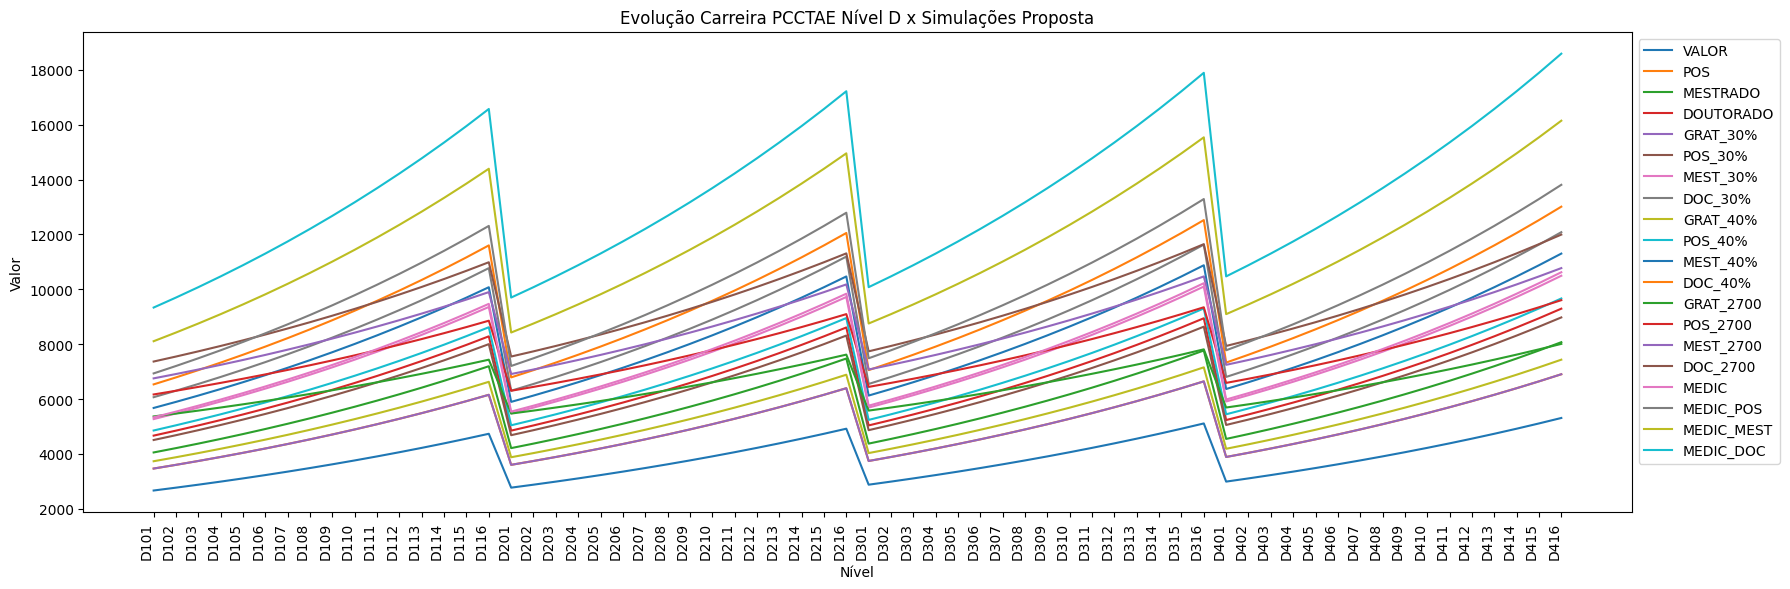

In [ ]:
import matplotlib.pyplot as plt
# Configurar o tamanho da figura
plt.figure(figsize=(18, 6))

# Filtrar níveis que começam com D
df_nivel_D = df_nivel[df_nivel['NIVEL'].str.startswith('D')]

colunas_nivel_D = ['NIVEL', 'VALOR', 'POS', 'MESTRADO', 'DOUTORADO', 'GRAT_30%', 'POS_30%',	'MEST_30%',	'DOC_30%', 'GRAT_40%', 'POS_40%',	'MEST_40%',	'DOC_40%', 'GRAT_2700', 'POS_2700', 'MEST_2700', 'DOC_2700', 'MEDIC', 'MEDIC_POS', 'MEDIC_MEST', 'MEDIC_DOC']
df_nivel_D = df_nivel_D[colunas_nivel_D]
# Plotar as linhas para cada coluna
for column in df_nivel_D.columns[1:]:
  plt.plot(df_nivel_D['NIVEL'], df_nivel_D[column], label=column)

# Adicionar rótulos e título
plt.xlabel('Nível')
plt.ylabel('Valor')
plt.title('Evolução Carreira PCCTAE Nível D x Simulações Proposta')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Adicionar legenda fora do gráfico

# Rotacionar os rótulos no eixo x para melhor visualização
plt.xticks(rotation=90, ha="right")

# Exibir o gráfico
plt.tight_layout()
plt.show()

##### Classe D - Níveis iniciais

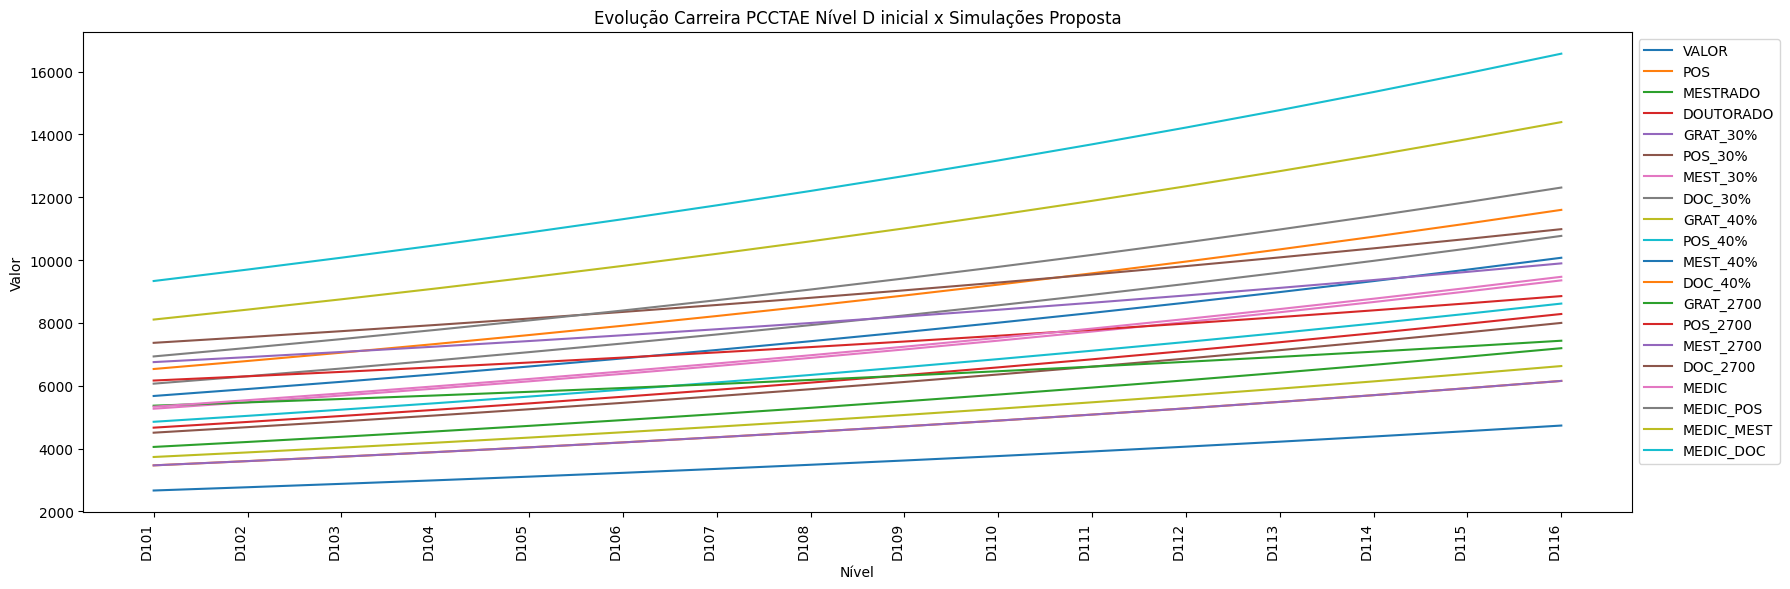

In [ ]:
# Configurar o tamanho da figura
plt.figure(figsize=(18, 6))

# Filtrar níveis que começam com D
df_nivel_D = df_nivel[df_nivel['NIVEL'].str.startswith('D1')]

colunas_nivel_D = ['NIVEL', 'VALOR', 'POS', 'MESTRADO', 'DOUTORADO', 'GRAT_30%', 'POS_30%', 'MEST_30%', 'DOC_30%', 'GRAT_40%', 'POS_40%',	'MEST_40%',	'DOC_40%', 'GRAT_2700', 'POS_2700', 'MEST_2700', 'DOC_2700', 'MEDIC', 'MEDIC_POS', 'MEDIC_MEST', 'MEDIC_DOC']
df_nivel_D = df_nivel_D[colunas_nivel_D]
# Plotar as linhas para cada coluna
for column in df_nivel_D.columns[1:]:
  plt.plot(df_nivel_D['NIVEL'], df_nivel_D[column], label=column)

# Adicionar rótulos e título
plt.xlabel('Nível')
plt.ylabel('Valor')
plt.title('Evolução Carreira PCCTAE Nível D inicial x Simulações Proposta')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Adicionar legenda fora do gráfico


# Rotacionar os rótulos no eixo x para melhor visualização
plt.xticks(rotation=90, ha="right")

# Exibir o gráfico
plt.tight_layout()
plt.show()

##### Classe E - Todos os Níveis

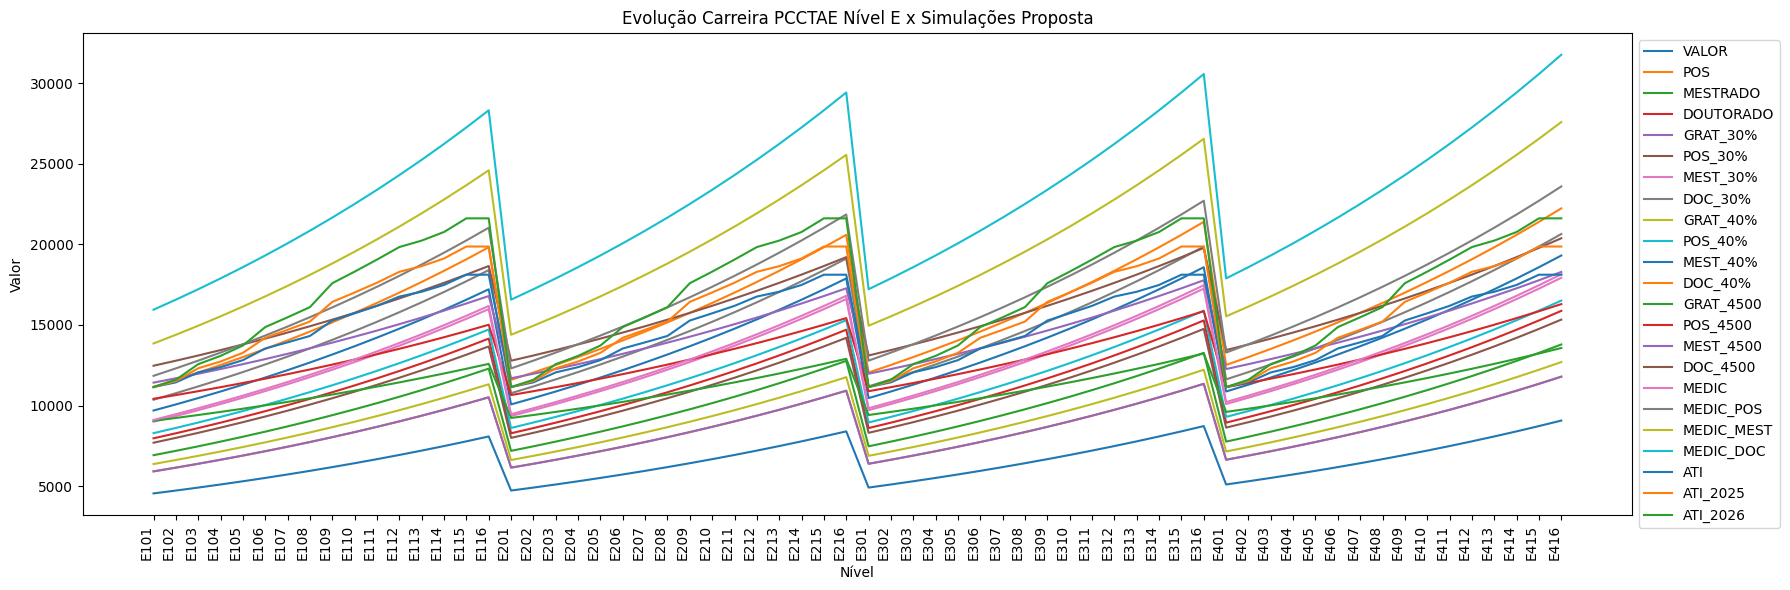

In [ ]:
# Configurar o tamanho da figura
plt.figure(figsize=(18, 6))

# Filtrar níveis que começam com D
df_nivel_E = df_nivel[df_nivel['NIVEL'].str.startswith('E')]
colunas_nivel_E = ['NIVEL', 'VALOR', 'POS', 'MESTRADO', 'DOUTORADO', 'GRAT_30%', 'POS_30%', 'MEST_30%', 'DOC_30%', 'GRAT_40%', 'POS_40%',   'MEST_40%', 'DOC_40%', 'GRAT_4500', 'POS_4500', 'MEST_4500', 'DOC_4500', 'MEDIC', 'MEDIC_POS', 'MEDIC_MEST', 'MEDIC_DOC', 'ATI', 'ATI_2025', 'ATI_2026']
df_nivel_E = df_nivel_E[colunas_nivel_E]
# Plotar as linhas para cada coluna
for column in df_nivel_E.columns[1:]:
  plt.plot(df_nivel_E['NIVEL'], df_nivel_E[column], label=column)

# Adicionar rótulos e título
plt.xlabel('Nível')
plt.ylabel('Valor')
plt.title('Evolução Carreira PCCTAE Nível E x Simulações Proposta')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Adicionar legenda fora do gráfico

# Rotacionar os rótulos no eixo x para melhor visualização
plt.xticks(rotation=90, ha="right")

# Exibir o gráfico
plt.tight_layout()
plt.show()

### Novas colunas para simulações de remuneração


#### Analista de Tecnologia da Informação

df_cadastro_remuneracao_mec_ati

In [ ]:
"""
Colunas auxiliares
"""

# Coluna para verificar o fator de multiplicação da redução da jornada, 1 = 40H (sem redução), 0.75 = 30H e 0.5 = 20H
df_cadastro_remuneracao_mec_ati['REDUCAO_JORNADA'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: reducao_jornada(row['JORNADA_DE_TRABALHO'], row['DESCRICAO_CARGO'], row['CLASSE_CARGO'], row['PADRAO_CARGO'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
#df_cadastro_remuneracao_mec_ati['REDUCAO_JORNADA'] = df_cadastro_remuneracao_mec_ati['REDUCAO_JORNADA'].apply(lambda x: Decimal(x).quantize(Decimal('0.00')))

# Coluna para verificar o fator de multiplicação do IQ. Ex.: 1.30 = Pós, 1.52 = Mestrado
# Ainda há problemas pois existem servidores que estão com CD e FG junto da remuneração básica bruta
df_cadastro_remuneracao_mec_ati['GRAT_TITULACAO'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: nivel_graduacao(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS'], row['REDUCAO_JORNADA'], row['CLASSE_CARGO'], row['PADRAO_CARGO'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()

# Coluna que obtém a quantidade de anos que o servidor está no cargo
df_cadastro_remuneracao_mec_ati['TEMPO_CARGO'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: tempo_cargo(row['DATA_INGRESSO_CARGOFUNCAO']) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()

"""
FIM - Colunas auxiliares
"""

# Colunas referente à valores atuais de pós, mestrado e doutorado
df_cadastro_remuneracao_mec_ati['POS'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: pos(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel)if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['MESTRADO'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: mestrado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['DOUTORADO'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: doutorado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()

# Coluna referente à proposta de gratificação para atividades de TI em valor de 30%
df_cadastro_remuneracao_mec_ati['GRAT_30'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: grat_30(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['POS_30'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: grat_30_pos(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['MEST_30'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: grat_30_mestrado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['DOC_30'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: grat_30_doutorado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()


# Coluna referente à proposta de dedicação exclusiva em valor de 40%
df_cadastro_remuneracao_mec_ati['GRAT_40'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: grat_40(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['POS_40'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: grat_40_pos(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['MEST_40'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: grat_40_mestrado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['DOC_40'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: grat_40_doutorado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()


# Colunas referente à proposta de gratificação para atividades de TI em valor fixo de 4500
df_cadastro_remuneracao_mec_ati['GRAT_2700'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: grat_fixa_2700(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['POS_2700'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: pos_2700(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['MEST_2700'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: mest_2700(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['DOC_2700'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: doc_2700(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()

# Colunas referente à proposta de gratificação para atividades de TI em valor fixo de 4500
df_cadastro_remuneracao_mec_ati['GRAT_4500'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: grat_fixa_4500(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['POS_4500'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: pos_4500(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['MEST_4500'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: mest_4500(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['DOC_4500'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: doc_4500(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()

# Colunas referente à proposta de vinculação à tabela de cargos específicos do PCCTAE
df_cadastro_remuneracao_mec_ati['MEDIC'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: medic(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['MEDIC_POS'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: medic_pos(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['MEDIC_MEST'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: medic_mest(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['MEDIC_DOC'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: medic_doc(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()

# Colunas referente à proposta de migração da carreira para ATI do MGI
df_cadastro_remuneracao_mec_ati['ATI'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: ati(row['TEMPO_CARGO'], row['CLASSE_CARGO'], row['REDUCAO_JORNADA'], ati_remuneracao_dict) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['ATI_2025'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: ati(row['TEMPO_CARGO'], row['CLASSE_CARGO'], row['REDUCAO_JORNADA'], ati_remuneracao_dict_2025) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_ati['ATI_2026'] = df_cadastro_remuneracao_mec_ati.apply(lambda row: ati(row['TEMPO_CARGO'], row['CLASSE_CARGO'], row['REDUCAO_JORNADA'], ati_remuneracao_dict_2026) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()



# Configurando o Pandas para exibir somente 11 linhas
pd.set_option('display.max_rows', 7)

# Imprimindo as colunas selecionadas do dataframe
df_cadastro_remuneracao_mec_ati[['Id_SERVIDOR_PORTAL',
                                 'NOME',
                                 'DESCRICAO_CARGO',
                                 'CLASSE_CARGO',
                                 'PADRAO_CARGO',
                                 'ORG_LOTACAO',
                                 'JORNADA_DE_TRABALHO',
                                 'DATA_INGRESSO_CARGOFUNCAO',
                                 'GRAT_TITULACAO',
                                 'REDUCAO_JORNADA',
                                 'TEMPO_CARGO',
                                 'REMUNERACAO_BASICA_BRUTA_EM_REAIS',
                                 'POS',
                                 'MESTRADO',
                                 'DOUTORADO',
                                 'GRAT_30',
                                 'POS_30',
                                 'MEST_30',
                                 'DOC_30',
                                 'GRAT_40',
                                 'POS_40',
                                 'MEST_40',
                                 'DOC_40',
                                 'GRAT_2700',
                                 'POS_2700',
                                 'MEST_2700',
                                 'DOC_2700',
                                 'GRAT_4500',
                                 'POS_4500',
                                 'MEST_4500',
                                 'DOC_4500',
                                 'MEDIC',
                                 'MEDIC_POS',
                                 'MEDIC_MEST',
                                 'MEDIC_DOC',
                                 'ATI',
                                 'ATI_2025',
                                 'ATI_2026']]

,Id_SERVIDOR_PORTAL,NOME,DESCRICAO_CARGO,CLASSE_CARGO,PADRAO_CARGO,ORG_LOTACAO,JORNADA_DE_TRABALHO,DATA_INGRESSO_CARGOFUNCAO,GRAT_TITULACAO,REDUCAO_JORNADA,TEMPO_CARGO,REMUNERACAO_BASICA_BRUTA_EM_REAIS,POS,MESTRADO,DOUTORADO,GRAT_30,POS_30,MEST_30,DOC_30,GRAT_40,POS_40,MEST_40,DOC_40,GRAT_2700,POS_2700,MEST_2700,DOC_2700,GRAT_4500,POS_4500,MEST_4500,DOC_4500,MEDIC,MEDIC_POS,MEDIC_MEST,MEDIC_DOC,ATI,ATI_2025,ATI_2026
110,3417274,ABEL CORREA DIAS,ANALISTA DE TEC DA INFORMACAO,E,410,Universidade Federal do Rio Grande do Sul,40 HORAS SEMANAIS,09/07/2009,1.52,1,15,10962.31,9375.65,10962.30,12621.07,14250.99,12188.35,14250.99,16407.39,15347.22,13125.91,15347.22,17669.50,0,0,0,0,15462.30,13875.65,15462.30,17121.07,21924.60,18751.30,21924.60,25242.14,16471.83,17955.92,19440.01
163,1256530,ABELARD RAMOS FERNANDES,ANALISTA DE TEC DA INFORMACAO,E,413,Fundação Universidade Federal de Ouro Preto,40 HORAS SEMANAIS,23/10/2006,1.82,1,18,14715.46,10515.93,12295.55,14156.07,19139.00,13670.71,15984.22,18402.89,20611.23,14722.30,17213.77,19818.50,0,0,0,0,19222.31,15015.93,16795.55,18656.07,29444.62,21031.86,24591.10,28312.14,17483.74,19124.82,20765.90
583,1008844,ACELINO GEHLEN DA SILVA,ANALISTA DE TEC DA INFORMACAO,E,208,Universidade Federal do Rio Grande do Sul,40 HORAS SEMANAIS,20/08/2013,2.03,1,11,12581.90,8045.25,9406.75,10830.14,16331.85,10458.83,12228.78,14079.18,17588.14,11263.35,13169.45,15162.20,0,0,0,0,17062.96,12545.25,13906.75,15330.14,25125.92,16090.50,18813.50,21660.28,14731.88,15749.17,16766.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
587072,1776357,YURI RANGEL RABELO PALHETA,ANALISTA DE TEC DA INFORMACAO,E,202,Universidade Federal Rural da Amazônia,40 HORAS SEMANAIS,05/09/2022,1.30,1,2,6395.09,6395.08,7477.32,8608.76,8313.60,8313.60,9720.52,11191.39,8953.11,8953.11,10468.25,12052.26,0,0,0,0,10895.08,10895.08,11977.32,13108.76,12790.15,12790.16,14954.64,17217.52,11443.21,11524.47,11605.72
587751,3489155,ZENILDO DE MELO CEZAR FILHO,ANALISTA DE TEC DA INFORMACAO,E,411,Universidade Federal da Paraíba,40 HORAS SEMANAIS,22/08/2008,1.52,1,16,11389.83,9741.30,11389.83,13113.29,14806.78,12663.69,14806.78,17047.28,15945.76,13637.82,15945.76,18358.61,0,0,0,0,15889.83,14241.30,15889.83,17613.29,22779.66,19482.60,22779.66,26226.58,16763.43,18298.02,19832.60
587836,3449202,ZEUS OLENCHUK GANIMI,ANALISTA DE TEC DA INFORMACAO,E,202,Universidade Federal do Rio de Janeiro,40 HORAS SEMANAIS,03/12/2021,1.30,1,3,6395.09,6395.08,7477.32,8608.76,8313.60,8313.60,9720.52,11191.39,8953.11,8953.11,10468.25,12052.26,0,0,0,0,10895.08,10895.08,11977.32,13108.76,12790.15,12790.16,14954.64,17217.52,11746.93,11913.07,12079.21


In [ ]:
df_cadastro_remuneracao_mec_ati.to_csv('mec_ati_simulacoes.csv')

##### Testes no dataframe de Analista de Tecnologia da Informação

In [ ]:
# Teste imprimir nome da planilha de cadastro e nome originado da planilha de orçamento através da busca pele nome de algum servidor
print(df_cadastro_remuneracao_mec_ati.loc[df_cadastro_remuneracao_mec_ati['NOME'].str.contains("fernando felix amorim", case=False), ['Id_SERVIDOR_PORTAL',
                                                                                                                                 'NOME',
                                                                                                                                 'DESCRICAO_CARGO',
                                                                                                                                 'CLASSE_CARGO',
                                                                                                                                 'PADRAO_CARGO',
                                                                                                                                 'ORG_LOTACAO',
                                                                                                                                 'JORNADA_DE_TRABALHO',
                                                                                                                                 'DATA_INGRESSO_CARGOFUNCAO',
                                                                                                                                 'GRAT_TITULACAO',
                                                                                                                                 'REDUCAO_JORNADA',
                                                                                                                                 'TEMPO_CARGO',
                                                                                                                                 'REMUNERACAO_BASICA_BRUTA_EM_REAIS',
                                                                                                                                 'POS',
                                                                                                                                 'MESTRADO',
                                                                                                                                 'DOUTORADO',
                                                                                                                                 'GRAT_30',
                                                                                                                                 'POS_30',
                                                                                                                                 'MEST_30',
                                                                                                                                 'DOC_30',
                                                                                                                                 'GRAT_40',
                                                                                                                                 'POS_40',
                                                                                                                                 'MEST_40',
                                                                                                                                 'DOC_40',
                                                                                                                                 'GRAT_2700',
                                                                                                                                 'POS_2700',
                                                                                                                                 'MEST_2700',
                                                                                                                                 'DOC_2700',
                                                                                                                                 'GRAT_4500',
                                                                                                                                 'POS_4500',
                                                                                                                                 'MEST_4500',
                                                                                                                                 'DOC_4500',
                                                                                                                                 'MEDIC',
                                                                                                                                 'MEDIC_POS',
                                                                                                                                 'MEDIC_MEST',
                                                                                                                                 'MEDIC_DOC',
                                                                                                                                 'ATI',
                                                                                                                                 'ATI_2025',
                                                                                                                                 'ATI_2026']])


        Id_SERVIDOR_PORTAL                   NOME  \
194046             1130788  FERNANDO FELIX AMORIM   

                      DESCRICAO_CARGO CLASSE_CARGO PADRAO_CARGO  \
194046  ANALISTA DE TEC DA INFORMACAO            E          411   

                                ORG_LOTACAO JORNADA_DE_TRABALHO  \
194046  Instituto Federal do Espírito Santo   40 HORAS SEMANAIS   

       DATA_INGRESSO_CARGOFUNCAO GRAT_TITULACAO REDUCAO_JORNADA TEMPO_CARGO  \
194046                14/01/2009           1.52               1          16   

       REMUNERACAO_BASICA_BRUTA_EM_REAIS      POS  MESTRADO DOUTORADO  \
194046                          11389.83  9741.30  11389.83  13113.29   

         GRAT_30    POS_30   MEST_30    DOC_30   GRAT_40    POS_40   MEST_40  \
194046  14806.78  12663.69  14806.78  17047.28  15945.76  13637.82  15945.76   

          DOC_40 GRAT_2700 POS_2700 MEST_2700 DOC_2700 GRAT_4500  POS_4500  \
194046  18358.61         0        0         0        0  15889.83  14241.30   


##### Impacto Orçamentário

Analista de tecnologia da Informação

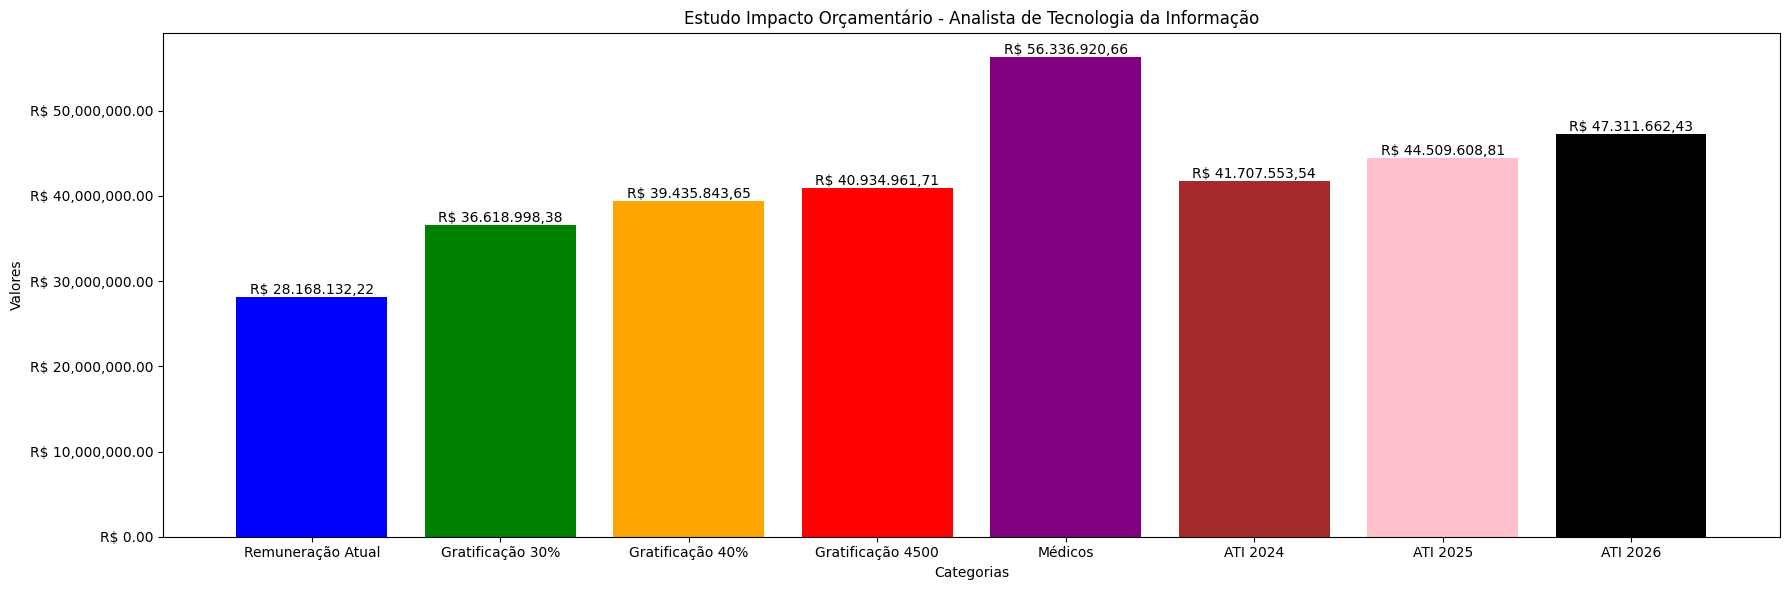

In [ ]:
import matplotlib.ticker as mtick
from babel.numbers import format_currency

total_remuneracao_atual_ati = df_cadastro_remuneracao_mec_ati['REMUNERACAO_BASICA_BRUTA_EM_REAIS'].sum()
total_grat_30_perc_ati = df_cadastro_remuneracao_mec_ati['GRAT_30'].sum()
total_grat_40_perc_ati = df_cadastro_remuneracao_mec_ati['GRAT_40'].sum()
total_grat_4500_ati = df_cadastro_remuneracao_mec_ati['GRAT_4500'].sum()
total_medic_ati = df_cadastro_remuneracao_mec_ati['MEDIC'].sum()
total_ati_2024_ati = df_cadastro_remuneracao_mec_ati['ATI'].sum()
total_ati_2025_ati = df_cadastro_remuneracao_mec_ati['ATI_2025'].sum()
total_ati_2026_ati = df_cadastro_remuneracao_mec_ati['ATI_2026'].sum()

categorias = ['Remuneração Atual', 'Gratificação 30%', 'Gratificação 40%', 'Gratificação 4500', 'Médicos', 'ATI 2024', 'ATI 2025', 'ATI 2026']
valores = [
    total_remuneracao_atual_ati,
    total_grat_30_perc_ati,
    total_grat_40_perc_ati,
    total_grat_4500_ati,
    total_medic_ati,
    total_ati_2024_ati,
    total_ati_2025_ati,
    total_ati_2026_ati
]

# Cores diferentes para cada barra
cores = ['blue', 'green', 'orange', 'red', 'purple', 'brown', 'pink', 'black']

# Configurar o tamanho da figura
plt.figure(figsize=(18, 6))

# Criar gráfico de barras com cores
bars = plt.bar(categorias, valores, color=cores)

# Adicionar rótulos e título
plt.xlabel('Categorias')
plt.ylabel('Valores')
plt.title('Estudo Impacto Orçamentário - Analista de Tecnologia da Informação')

# Adicionar rótulos com os valores formatados em moeda brasileira acima das barras
for bar, valor in zip(bars, valores):
    formatted_value = format_currency(Decimal(str(valor)), 'BRL', locale='pt_BR')
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000, formatted_value, ha='center', va='bottom')

# Formatar eixo y como moeda brasileira
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('R$ {x:,.2f}'))

# Exibir o gráfico
plt.tight_layout()
plt.show()

#### Tecnólogo Formação Area - TI


In [ ]:
"""
Colunas auxiliares
"""

# Coluna para verificar o fator de multiplicação da redução da jornada, 1 = 40H (sem redução), 0.75 = 30H e 0.5 = 20H
df_cadastro_remuneracao_mec_tecn_ti['REDUCAO_JORNADA'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: reducao_jornada(row['JORNADA_DE_TRABALHO'], row['DESCRICAO_CARGO'], row['CLASSE_CARGO'], row['PADRAO_CARGO'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
#df_cadastro_remuneracao_mec_tecn_ti['REDUCAO_JORNADA'] = df_cadastro_remuneracao_mec_tecn_ti['REDUCAO_JORNADA'].apply(lambda x: Decimal(x).quantize(Decimal('0.00')))

# Coluna para verificar o fator de multiplicação do IQ. Ex.: 1.30 = Pós, 1.52 = Mestrado
# Ainda há problemas pois existem servidores que estão com CD e FG junto da remuneração básica bruta
df_cadastro_remuneracao_mec_tecn_ti['GRAT_TITULACAO'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: nivel_graduacao(row['REMUNERAÇÃO BÁSICA BRUTA (R$)'], row['REDUCAO_JORNADA'], row['CLASSE_CARGO'], row['PADRAO_CARGO'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()

# Coluna que obtém a quantidade de anos que o servidor está no cargo
df_cadastro_remuneracao_mec_tecn_ti['TEMPO_CARGO'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: tempo_cargo(row['DATA_INGRESSO_CARGOFUNCAO_x']) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()

"""
FIM - Colunas auxiliares
"""

# Colunas referente à valores atuais de pós, mestrado e doutorado
df_cadastro_remuneracao_mec_tecn_ti['POS'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: pos(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel)if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['MESTRADO'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: mestrado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['DOUTORADO'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: doutorado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()

# Coluna referente à proposta de gratificação para atividades de TI em valor de 30%
df_cadastro_remuneracao_mec_tecn_ti['GRAT_30'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: grat_30(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['POS_30'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: grat_30_pos(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['MEST_30'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: grat_30_mestrado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['DOC_30'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: grat_30_doutorado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()


# Coluna referente à proposta de dedicação exclusiva em valor de 40%
df_cadastro_remuneracao_mec_tecn_ti['GRAT_40'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: grat_40(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['POS_40'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: grat_40_pos(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['MEST_40'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: grat_40_mestrado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['DOC_40'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: grat_40_doutorado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()


# Colunas referente à proposta de gratificação para atividades de TI em valor fixo de 4500
df_cadastro_remuneracao_mec_tecn_ti['GRAT_2700'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: grat_fixa_2700(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['POS_2700'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: pos_2700(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['MEST_2700'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: mest_2700(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['DOC_2700'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: doc_2700(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()

# Colunas referente à proposta de gratificação para atividades de TI em valor fixo de 4500
df_cadastro_remuneracao_mec_tecn_ti['GRAT_4500'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: grat_fixa_4500(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['POS_4500'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: pos_4500(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['MEST_4500'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: mest_4500(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['DOC_4500'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: doc_4500(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()

# Colunas referente à proposta de vinculação à tabela de cargos específicos do PCCTAE
df_cadastro_remuneracao_mec_tecn_ti['MEDIC'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: medic(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['MEDIC_POS'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: medic_pos(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['MEDIC_MEST'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: medic_mest(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['MEDIC_DOC'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: medic_doc(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()

# Colunas referente à proposta de migração da carreira para ATI do MGI
df_cadastro_remuneracao_mec_tecn_ti['ATI'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: ati(row['TEMPO_CARGO'], row['CLASSE_CARGO'], row['REDUCAO_JORNADA'], ati_remuneracao_dict) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['ATI_2025'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: ati(row['TEMPO_CARGO'], row['CLASSE_CARGO'], row['REDUCAO_JORNADA'], ati_remuneracao_dict_2025) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tecn_ti['ATI_2026'] = df_cadastro_remuneracao_mec_tecn_ti.apply(lambda row: ati(row['TEMPO_CARGO'], row['CLASSE_CARGO'], row['REDUCAO_JORNADA'], ati_remuneracao_dict_2026) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()



# Configurando o Pandas para exibir somente 11 linhas
pd.set_option('display.max_rows', 7)

# Imprimindo as colunas selecionadas do dataframe
df_cadastro_remuneracao_mec_tecn_ti[['Id_SERVIDOR_PORTAL',
                                 'NOME_x',
                                 'DESCRICAO_CARGO',
                                 'CARGO_AREA',
                                 'CLASSE_CARGO',
                                 'PADRAO_CARGO',
                                 'ORG_LOTACAO',
                                 'JORNADA_DE_TRABALHO',
                                 'DATA_INGRESSO_CARGOFUNCAO_x',
                                 'GRAT_TITULACAO',
                                 'REDUCAO_JORNADA',
                                 'TEMPO_CARGO',
                                 'REMUNERAÇÃO BÁSICA BRUTA (R$)',
                                 'POS',
                                 'MESTRADO',
                                 'DOUTORADO',
                                 'GRAT_30',
                                 'POS_30',
                                 'MEST_30',
                                 'DOC_30',
                                 'GRAT_40',
                                 'POS_40',
                                 'MEST_40',
                                 'DOC_40',
                                 'GRAT_2700',
                                 'POS_2700',
                                 'MEST_2700',
                                 'DOC_2700',
                                 'GRAT_4500',
                                 'POS_4500',
                                 'MEST_4500',
                                 'DOC_4500',
                                 'MEDIC',
                                 'MEDIC_POS',
                                 'MEDIC_MEST',
                                 'MEDIC_DOC',
                                 'ATI',
                                 'ATI_2025',
                                 'ATI_2026']]

,Id_SERVIDOR_PORTAL,NOME_x,DESCRICAO_CARGO,CARGO_AREA,CLASSE_CARGO,PADRAO_CARGO,ORG_LOTACAO,JORNADA_DE_TRABALHO,DATA_INGRESSO_CARGOFUNCAO_x,GRAT_TITULACAO,REDUCAO_JORNADA,TEMPO_CARGO,REMUNERAÇÃO BÁSICA BRUTA (R$),POS,MESTRADO,DOUTORADO,GRAT_30,POS_30,MEST_30,DOC_30,GRAT_40,POS_40,MEST_40,DOC_40,GRAT_2700,POS_2700,MEST_2700,DOC_2700,GRAT_4500,POS_4500,MEST_4500,DOC_4500,MEDIC,MEDIC_POS,MEDIC_MEST,MEDIC_DOC,ATI,ATI_2025,ATI_2026
0,1011559,ADA GUAGLIARDI FARIA,TECNOLOGO-FORMACAO,GOVERNANÇA DE TECNOLOGIA DA INFORMAÇÃO,E,406,Instituto Federal do Rio de Janeiro,40 HORAS SEMANAIS,07/03/2016,1.52,1,9,9406.74,8045.25,9406.75,10830.14,12228.77,10458.83,12228.78,14079.18,13169.45,11263.35,13169.45,15162.20,0,0,0,0,13906.75,12545.25,13906.75,15330.14,18813.50,16090.50,18813.50,21660.28,13924.84,14701.32,15477.79
11,3448353,ADRIANO DOS REIS CARVALHO,TECNOLOGO-FORMACAO,INFORMÁTICA,E,405,Instituto Federal do Sul de Minas Gerais,40 HORAS SEMANAIS,26/07/2018,1.52,1,6,9053.66,7743.26,9053.65,10423.61,11769.75,10066.24,11769.75,13550.69,12675.11,10840.56,12675.11,14593.05,0,0,0,0,13553.65,12243.26,13553.65,14923.61,18107.30,15486.52,18107.30,20847.22,12820.77,13274.44,13728.10
12,3759417,ADRIANO REIS PRAIA,TECNOLOGO-FORMACAO,INFORMÁTICA,E,406,Instituto Federal do Amazonas,40 HORAS SEMANAIS,10/10/2016,1.42,1,8,8760.59,8045.25,9406.75,10830.14,11424.25,10458.83,12228.78,14079.18,12303.04,11263.35,13169.45,15162.20,0,0,0,0,13287.88,12545.25,13906.75,15330.14,17575.77,16090.50,18813.50,21660.28,13543.24,14207.17,14871.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851,80086,THAIS FERNANDA BUENO DA SILVA,TECNOLOGO-FORMACAO,ANÁLISE E DESENVOLVIMENTO DE SISTEMAS,E,406,Universidade Federal de Mato Grosso,40 HORAS SEMANAIS,25/07/2016,1.30,1,8,8045.24,8045.25,9406.75,10830.14,10458.82,10458.83,12228.78,14079.18,11263.34,11263.35,13169.45,15162.20,0,0,0,0,12545.25,12545.25,13906.75,15330.14,16090.49,16090.50,18813.50,21660.28,13543.24,14207.17,14871.09
859,377588,THAYRON CRYSTIAN HORTENCES DE MORAES,TECNOLOGO-FORMACAO,REDES DE COMPUTADORES,E,408,Universidade Federal de Mato Grosso,40 HORAS SEMANAIS,07/06/2013,1.68,1,11,11218.09,8685.01,10154.79,11691.37,14590.82,11290.51,13201.23,15198.78,15713.19,12159.01,14216.71,16367.92,0,0,0,0,15723.71,13185.01,14654.79,16191.37,22447.42,17370.02,20309.58,23382.74,14731.88,15749.17,16766.46
889,65838,VANESSA CRISTINA DOS ANJOS SILVEIRA,TECNOLOGO-FORMACAO,ANÁLISE E DESENVOLVIMENTO DE SISTEMAS,E,405,Universidade Federal de Mato Grosso,40 HORAS SEMANAIS,04/05/2018,1.52,1,6,9053.66,7743.26,9053.65,10423.61,11769.75,10066.24,11769.75,13550.69,12675.11,10840.56,12675.11,14593.05,0,0,0,0,13553.65,12243.26,13553.65,14923.61,18107.30,15486.52,18107.30,20847.22,12820.77,13274.44,13728.10


In [ ]:
df_cadastro_remuneracao_mec_tecn_ti.to_csv('mec_tecn_ti_simulacoes.csv')

##### Análise de extração de Área do Cargo - DOU


In [ ]:
# Criar um DataFrame para exibição dos detalhes da quantidade de servidores em cada ambiente
sum_data_tecn = {
    'Cargo': ['Total Tecnólogos-formação Área',
              'Total Área Cargo Extraídos DOU',
              'Tecnólogos-formação Área TI - Extraídos DOU',
              ],
    'Quantidade': [df_cadastro_remuneracao_mec_tecn.shape[0],
                                            df_cadastro_remuneracao_mec_tecn['CARGO_AREA'].notna().sum(),
                                            df_cadastro_remuneracao_mec_tecn_ti.shape[0]
                                            ],
    'Porcentagem do Total': [100.0,
                             Decimal((df_cadastro_remuneracao_mec_tecn['CARGO_AREA'].notna().sum() / df_cadastro_remuneracao_mec_tecn.shape[0]) * 100).quantize(Decimal('0.00')),
                             Decimal((df_cadastro_remuneracao_mec_tecn_ti.shape[0] / df_cadastro_remuneracao_mec_tecn.shape[0]) * 100).quantize(Decimal('0.00'))
                             ],
    'Porcentagem do Total Extraído': ['-',
                                      Decimal((df_cadastro_remuneracao_mec_tecn['CARGO_AREA'].notna().sum() / df_cadastro_remuneracao_mec_tecn['CARGO_AREA'].notna().sum()) * 100).quantize(Decimal('0.00')),
                                      Decimal((df_cadastro_remuneracao_mec_tecn_ti.shape[0] / df_cadastro_remuneracao_mec_tecn['CARGO_AREA'].notna().sum()) * 100).quantize(Decimal('0.00')),
                                      ]
}


df_sum_tecn = pd.DataFrame(sum_data_tecn)
df_sum_tecn

,Cargo,Quantidade,Porcentagem do Total,Porcentagem do Total Extraído
0,Total Tecnólogos-formação Área,933,100.0,-
1,Total Área Cargo Extraídos DOU,580,62.17,100.00
2,Tecnólogos-formação Área TI - Extraídos DOU,64,6.86,11.03


##### Impacto Orçamentário

Tecnólogo Formação Área - TI

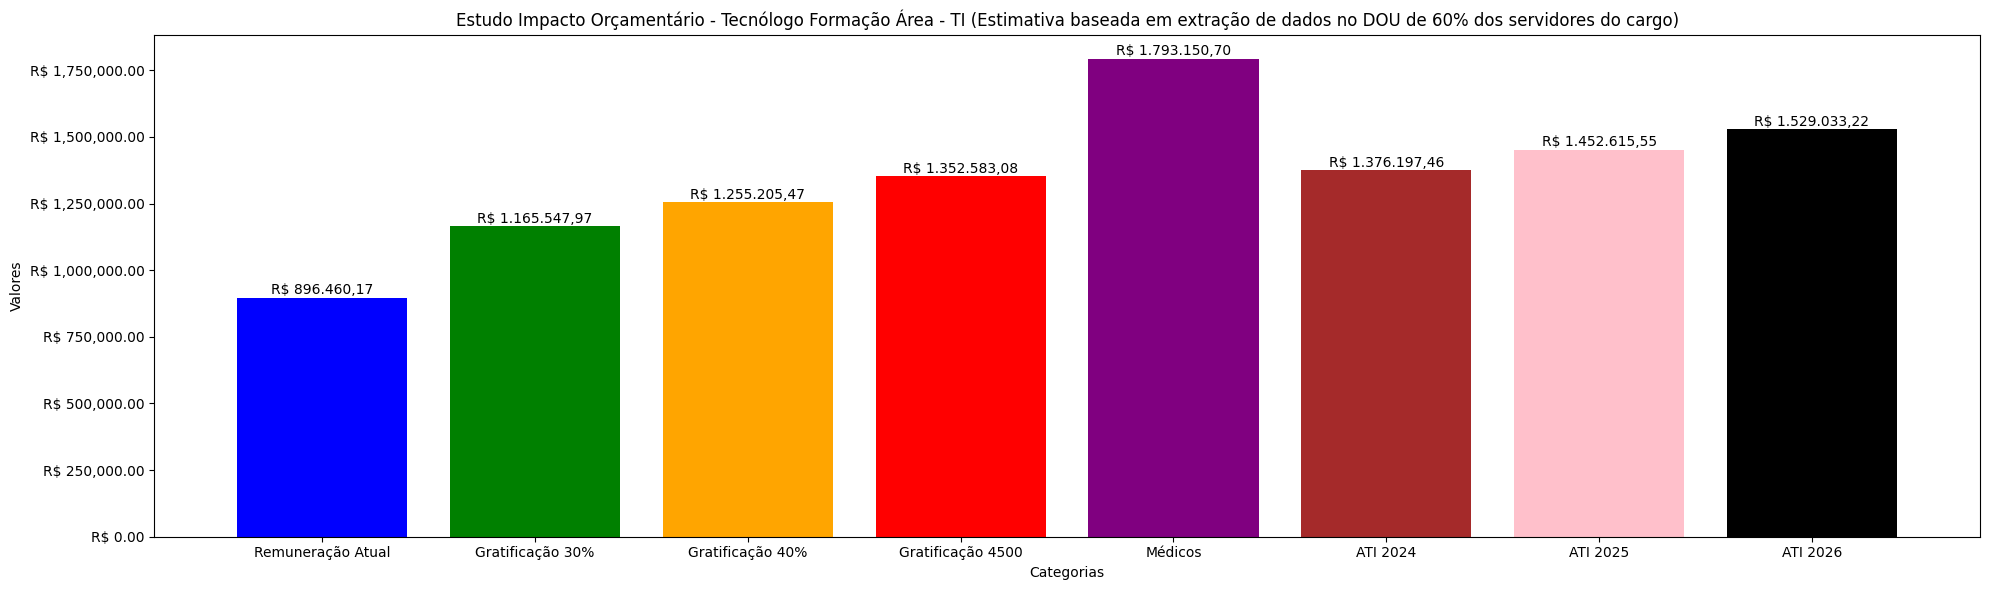

In [ ]:
total_remuneracao_atual_tecn_ti = df_cadastro_remuneracao_mec_tecn_ti['REMUNERAÇÃO BÁSICA BRUTA (R$)'].sum()
total_grat_30_perc_tecn_ti = df_cadastro_remuneracao_mec_tecn_ti['GRAT_30'].sum()
total_grat_40_perc_tecn_ti = df_cadastro_remuneracao_mec_tecn_ti['GRAT_40'].sum()
total_grat_4500_tecn_ti = df_cadastro_remuneracao_mec_tecn_ti['GRAT_4500'].sum()
total_medic_tecn_ti = df_cadastro_remuneracao_mec_tecn_ti['MEDIC'].sum()
total_ati_2024_tecn_ti = df_cadastro_remuneracao_mec_tecn_ti['ATI'].sum()
total_ati_2025_tecn_ti = df_cadastro_remuneracao_mec_tecn_ti['ATI_2025'].sum()
total_ati_2026_tecn_ti = df_cadastro_remuneracao_mec_tecn_ti['ATI_2026'].sum()

# Valores com a estimativa baseada na extração DOU
total_remuneracao_atual_tecn_ti_estim = (total_remuneracao_atual_tecn_ti*100)/sum_data_tecn['Porcentagem do Total'][1]
total_grat_30_perc_tecn_ti_estim = (total_grat_30_perc_tecn_ti*100)/sum_data_tecn['Porcentagem do Total'][1]
total_grat_40_perc_tecn_ti_estim = (total_grat_40_perc_tecn_ti*100)/sum_data_tecn['Porcentagem do Total'][1]
total_grat_4500_tecn_ti_estim = (total_grat_4500_tecn_ti*100)/sum_data_tecn['Porcentagem do Total'][1]
total_medic_tecn_ti_estim = (total_medic_tecn_ti*100)/sum_data_tecn['Porcentagem do Total'][1]
total_ati_2024_tecn_ti_estim = (total_ati_2024_tecn_ti*100)/sum_data_tecn['Porcentagem do Total'][1]
total_ati_2025_tecn_ti_estim = (total_ati_2025_tecn_ti*100)/sum_data_tecn['Porcentagem do Total'][1]
total_ati_2026_tecn_ti_estim = (total_ati_2026_tecn_ti*100)/sum_data_tecn['Porcentagem do Total'][1]


categorias = ['Remuneração Atual', 'Gratificação 30%', 'Gratificação 40%', 'Gratificação 4500', 'Médicos', 'ATI 2024', 'ATI 2025', 'ATI 2026']
# Colocando os valores em termos da estimativa
valores = [
    total_remuneracao_atual_tecn_ti_estim,
    total_grat_30_perc_tecn_ti_estim,
    total_grat_40_perc_tecn_ti_estim,
    total_grat_4500_tecn_ti_estim,
    total_medic_tecn_ti_estim,
    total_ati_2024_tecn_ti_estim,
    total_ati_2025_tecn_ti_estim,
    total_ati_2026_tecn_ti_estim
]

# Cores diferentes para cada barra
cores = ['blue', 'green', 'orange', 'red', 'purple', 'brown', 'pink', 'black', 'gray']

# Configurar o tamanho da figura
plt.figure(figsize=(20, 6))

# Criar gráfico de barras com cores
bars = plt.bar(categorias, valores, color=cores)

# Adicionar rótulos e título
plt.xlabel('Categorias')
plt.ylabel('Valores')
plt.title('Estudo Impacto Orçamentário - Tecnólogo Formação Área - TI (Estimativa baseada em extração de dados no DOU de 60% dos servidores do cargo)')

# Adicionar rótulos com os valores formatados em moeda brasileira acima das barras
for bar, valor in zip(bars, valores):
    formatted_value = format_currency(Decimal(str(valor)), 'BRL', locale='pt_BR')
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000, formatted_value, ha='center', va='bottom')

# Formatar eixo y como moeda brasileira
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('R$ {x:,.2f}'))

# Exibir o gráfico
plt.tight_layout()
plt.show()

#### Técnicos de Tecnologia da Informação

 df_cadastro_remuneracao_mec_tti

In [ ]:
"""
Colunas auxiliares
"""

# Coluna para verificar o fator de multiplicação da redução da jornada, 1 = 40H (sem redução), 0.75 = 30H e 0.5 = 20H
df_cadastro_remuneracao_mec_tti['REDUCAO_JORNADA'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: reducao_jornada(row['JORNADA_DE_TRABALHO'], row['DESCRICAO_CARGO'], row['CLASSE_CARGO'], row['PADRAO_CARGO'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
#df_cadastro_remuneracao_mec_tti['REDUCAO_JORNADA'] = df_cadastro_remuneracao_mec_tti['REDUCAO_JORNADA'].apply(lambda x: Decimal(x).quantize(Decimal('0.00')))

# Coluna para verificar o fator de multiplicação do IQ. Ex.: 1.30 = Pós, 1.52 = Mestrado
# Ainda há problemas pois existem servidores que estão com CD e FG junto da remuneração básica bruta
df_cadastro_remuneracao_mec_tti['GRAT_TITULACAO'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: nivel_graduacao(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS'], row['REDUCAO_JORNADA'], row['CLASSE_CARGO'], row['PADRAO_CARGO'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()

# Coluna que obtém a quantidade de anos que o servidor está no cargo
df_cadastro_remuneracao_mec_tti['TEMPO_CARGO'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: tempo_cargo(row['DATA_INGRESSO_CARGOFUNCAO']) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()

"""
FIM - Colunas auxiliares
"""

# Colunas referente à valores atuais de pós, mestrado e doutorado
df_cadastro_remuneracao_mec_tti['POS'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: pos(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel)if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['MESTRADO'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: mestrado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['DOUTORADO'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: doutorado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()

# Coluna referente à proposta de gratificação para atividades de TI em valor de 30%
df_cadastro_remuneracao_mec_tti['GRAT_30'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: grat_30(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['POS_30'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: grat_30_pos(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['MEST_30'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: grat_30_mestrado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['DOC_30'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: grat_30_doutorado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()


# Coluna referente à proposta de dedicação exclusiva em valor de 40%
df_cadastro_remuneracao_mec_tti['GRAT_40'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: grat_40(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['POS_40'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: grat_40_pos(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['MEST_40'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: grat_40_mestrado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['DOC_40'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: grat_40_doutorado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()


# Colunas referente à proposta de gratificação para atividades de TI em valor fixo de 4500
df_cadastro_remuneracao_mec_tti['GRAT_2700'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: grat_fixa_2700(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['POS_2700'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: pos_2700(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['MEST_2700'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: mest_2700(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['DOC_2700'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: doc_2700(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()

# Colunas referente à proposta de gratificação para atividades de TI em valor fixo de 4500
df_cadastro_remuneracao_mec_tti['GRAT_4500'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: grat_fixa_4500(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['POS_4500'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: pos_4500(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['MEST_4500'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: mest_4500(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['DOC_4500'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: doc_4500(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()

# Colunas referente à proposta de vinculação à tabela de cargos específicos do PCCTAE
df_cadastro_remuneracao_mec_tti['MEDIC'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: medic(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['MEDIC_POS'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: medic_pos(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['MEDIC_MEST'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: medic_mest(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['MEDIC_DOC'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: medic_doc(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()


# Colunas referente à proposta de migração da carreira para ATI do MGI
df_cadastro_remuneracao_mec_tti['ATI'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: ati(row['TEMPO_CARGO'], row['CLASSE_CARGO'], row['REDUCAO_JORNADA'], ati_remuneracao_dict) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['ATI_2025'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: ati(row['TEMPO_CARGO'], row['CLASSE_CARGO'], row['REDUCAO_JORNADA'], ati_remuneracao_dict_2025) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tti['ATI_2026'] = df_cadastro_remuneracao_mec_tti.apply(lambda row: ati(row['TEMPO_CARGO'], row['CLASSE_CARGO'], row['REDUCAO_JORNADA'], ati_remuneracao_dict_2026) if pd.notna(row['REMUNERACAO_BASICA_BRUTA_EM_REAIS']) else pd.NA, axis=1).copy()

# Configurando o Pandas para exibir somente 11 linhas
pd.set_option('display.max_rows', 7)

# Imprimindo as colunas selecionadas do dataframe
df_cadastro_remuneracao_mec_tti[['Id_SERVIDOR_PORTAL',
                                 'NOME',
                                 'DESCRICAO_CARGO',
                                 'CLASSE_CARGO',
                                 'PADRAO_CARGO',
                                 'ORG_LOTACAO',
                                 'JORNADA_DE_TRABALHO',
                                 'DATA_INGRESSO_CARGOFUNCAO',
                                 'GRAT_TITULACAO',
                                 'REDUCAO_JORNADA',
                                 'TEMPO_CARGO',
                                 'REMUNERACAO_BASICA_BRUTA_EM_REAIS',
                                 'POS',
                                 'MESTRADO',
                                 'DOUTORADO',
                                 'GRAT_30',
                                 'POS_30',
                                 'MEST_30',
                                 'DOC_30',
                                 'GRAT_40',
                                 'POS_40',
                                 'MEST_40',
                                 'DOC_40',
                                 'GRAT_2700',
                                 'POS_2700',
                                 'MEST_2700',
                                 'DOC_2700',
                                 'GRAT_4500',
                                 'POS_4500',
                                 'MEST_4500',
                                 'DOC_4500',
                                 'MEDIC',
                                 'MEDIC_POS',
                                 'MEDIC_MEST',
                                 'MEDIC_DOC',
                                 'ATI',
                                 'ATI_2025',
                                 'ATI_2026'
                                 ]]

,Id_SERVIDOR_PORTAL,NOME,DESCRICAO_CARGO,CLASSE_CARGO,PADRAO_CARGO,ORG_LOTACAO,JORNADA_DE_TRABALHO,DATA_INGRESSO_CARGOFUNCAO,GRAT_TITULACAO,REDUCAO_JORNADA,TEMPO_CARGO,REMUNERACAO_BASICA_BRUTA_EM_REAIS,POS,MESTRADO,DOUTORADO,GRAT_30,POS_30,MEST_30,DOC_30,GRAT_40,POS_40,MEST_40,DOC_40,GRAT_2700,POS_2700,MEST_2700,DOC_2700,GRAT_4500,POS_4500,MEST_4500,DOC_4500,MEDIC,MEDIC_POS,MEDIC_MEST,MEDIC_DOC,ATI,ATI_2025,ATI_2026
153,2841519,ABEL SMITH MENEZES,TEC DE TECNOLOGIA DA INFORMACAO,D,416,Fundação Universidade Federal de Sergipe,40 HORAS SEMANAIS,01/03/2005,3.03,1,20,16106.58,6903.62,8071.93,9293.34,20917.98,8974.71,10493.51,12081.34,22527.06,9665.07,11300.70,13010.68,18790.75,9603.62,10771.93,11993.34,0,0,0,0,32181.51,13807.24,16143.86,18586.68,11052.06,12118.02,13183.99
156,299123,ABEL TELES BARBOSA,TEC DE TECNOLOGIA DA INFORMACAO,D,407,Instituto Federal Goiano,40 HORAS SEMANAIS,20/10/2014,1.49,1,10,5607.92,4892.58,5720.55,6586.16,7289.94,6360.35,7436.72,8562.01,7850.70,6849.61,8008.77,9220.62,8307.64,7592.58,8420.55,9286.16,0,0,0,0,11215.29,9785.16,11441.10,13172.32,8735.84,9281.24,9826.64
202,3863729,ABHNER ADRIEL CRISTOVAO SILVA,TEC DE TECNOLOGIA DA INFORMACAO,D,101,Universidade Federal de Pernambuco,40 HORAS SEMANAIS,05/02/2024,1.00,1,1,2667.19,3467.35,4054.13,4667.58,3467.35,4507.56,5270.37,6067.85,3734.07,4854.29,5675.78,6534.61,5367.19,6167.35,6754.13,7367.58,0,0,0,0,5334.38,6934.70,8108.26,9335.16,6801.99,6801.99,6801.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
587462,57689,ZEDEQUIAS DE OLIVEIRA CAMPOS JUNIOR,TEC DE TECNOLOGIA DA INFORMACAO,D,410,Instituto Federal do Maranhão,40 HORAS SEMANAIS,28/09/2010,1.47,1,14,6202.96,5487.61,6416.28,7387.17,8066.79,7133.89,8341.16,9603.32,8687.31,7682.65,8982.79,10342.04,8905.22,8187.61,9116.28,10087.17,0,0,0,0,12410.45,10975.22,12832.56,14774.34,9874.15,10748.91,11623.67
587544,2932087,ZELIA MARIA RODRIGUES LOPES,TEC DE TECNOLOGIA DA INFORMACAO,D,216,Universidade Federal de Goiás,40 HORAS SEMANAIS,01/03/2005,1.26,1,20,6192.42,6395.08,7477.32,8608.76,8057.80,8313.60,9720.52,11191.39,8677.63,8953.11,10468.25,12052.26,8898.31,9095.08,10177.32,11308.76,0,0,0,0,12396.61,12790.16,14954.64,17217.52,11052.06,12118.02,13183.99
588076,1170799,ZILTON GUEDES RIBEIRO DE FREITAS,TEC DE TECNOLOGIA DA INFORMACAO,D,407,Universidade Federal do Ceará,40 HORAS SEMANAIS,02/06/2014,1.30,1,10,4892.57,4892.58,5720.55,6586.16,6360.35,6360.35,7436.72,8562.01,6849.61,6849.61,8008.77,9220.62,7592.58,7592.58,8420.55,9286.16,0,0,0,0,9785.15,9785.16,11441.10,13172.32,8735.84,9281.24,9826.64


In [ ]:
df_cadastro_remuneracao_mec_tti.to_csv('mec_tti_simulacoes.csv')

##### Impacto Orçamentário
### Técnico de Tecnologia da Informação

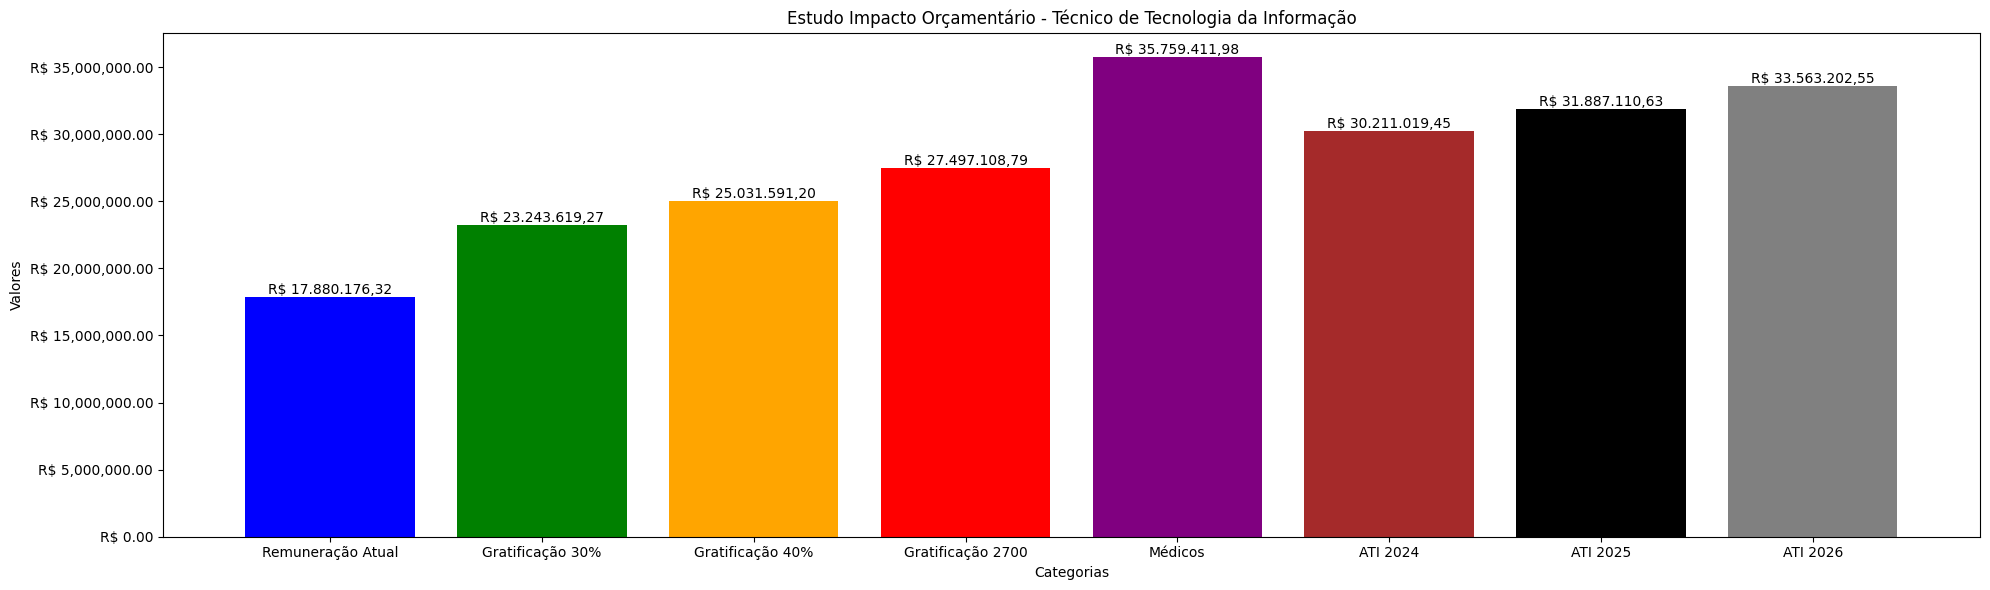

In [ ]:
total_remuneracao_atual_tti = df_cadastro_remuneracao_mec_tti['REMUNERACAO_BASICA_BRUTA_EM_REAIS'].sum()
total_grat_30_perc_tti = df_cadastro_remuneracao_mec_tti['GRAT_30'].sum()
total_grat_40_perc_tti = df_cadastro_remuneracao_mec_tti['GRAT_40'].sum()
total_grat_2700_tti = df_cadastro_remuneracao_mec_tti['GRAT_2700'].sum()
total_medic_tti = df_cadastro_remuneracao_mec_tti['MEDIC'].sum()
total_ati_2024_tti = df_cadastro_remuneracao_mec_tti['ATI'].sum()
total_ati_2025_tti = df_cadastro_remuneracao_mec_tti['ATI_2025'].sum()
total_ati_2026_tti = df_cadastro_remuneracao_mec_tti['ATI_2026'].sum()

categorias = ['Remuneração Atual', 'Gratificação 30%', 'Gratificação 40%', 'Gratificação 2700', 'Médicos', 'ATI 2024', 'ATI 2025', 'ATI 2026']
valores = [
    total_remuneracao_atual_tti,
    total_grat_30_perc_tti,
    total_grat_40_perc_tti,
    total_grat_2700_tti,
    total_medic_tti,
    total_ati_2024_tti,
    total_ati_2025_tti,
    total_ati_2026_tti
]

# Cores diferentes para cada barra
cores = ['blue', 'green', 'orange', 'red', 'purple', 'brown', 'black', 'gray']

# Configurar o tamanho da figura
plt.figure(figsize=(20, 6))

# Criar gráfico de barras com cores
bars = plt.bar(categorias, valores, color=cores)

# Adicionar rótulos e título
plt.xlabel('Categorias')
plt.ylabel('Valores')
plt.title('Estudo Impacto Orçamentário - Técnico de Tecnologia da Informação')

# Adicionar rótulos com os valores formatados em moeda brasileira acima das barras
for bar, valor in zip(bars, valores):
    formatted_value = format_currency(Decimal(str(valor)), 'BRL', locale='pt_BR')
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000, formatted_value, ha='center', va='bottom')

# Formatar eixo y como moeda brasileira
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('R$ {x:,.2f}'))

# Exibir o gráfico
plt.tight_layout()
plt.show()

#### Técnico de Laboratório Àrea - TI


In [ ]:
"""
Colunas auxiliares
"""

# Coluna para verificar o fator de multiplicação da redução da jornada, 1 = 40H (sem redução), 0.75 = 30H e 0.5 = 20H
df_cadastro_remuneracao_mec_tlab_ti['REDUCAO_JORNADA'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: reducao_jornada(row['JORNADA_DE_TRABALHO'], row['DESCRICAO_CARGO'], row['CLASSE_CARGO'], row['PADRAO_CARGO'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()

# Coluna para verificar o fator de multiplicação do IQ. Ex.: 1.30 = Pós, 1.52 = Mestrado
# Ainda há problemas pois existem servidores que estão com CD e FG junto da remuneração básica bruta
df_cadastro_remuneracao_mec_tlab_ti['GRAT_TITULACAO'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: nivel_graduacao(row['REMUNERAÇÃO BÁSICA BRUTA (R$)'], row['REDUCAO_JORNADA'], row['CLASSE_CARGO'], row['PADRAO_CARGO'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()

# Coluna que obtém a quantidade de anos que o servidor está no cargo
df_cadastro_remuneracao_mec_tlab_ti['TEMPO_CARGO'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: tempo_cargo(row['DATA_INGRESSO_CARGOFUNCAO_x']) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()

"""
FIM - Colunas auxiliares
"""

# Colunas referente à valores atuais de pós, mestrado e doutorado
df_cadastro_remuneracao_mec_tlab_ti['POS'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: pos(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel)if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['MESTRADO'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: mestrado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['DOUTORADO'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: doutorado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()

# Coluna referente à proposta de gratificação para atividades de TI em valor de 30%
df_cadastro_remuneracao_mec_tlab_ti['GRAT_30'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: grat_30(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['POS_30'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: grat_30_pos(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['MEST_30'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: grat_30_mestrado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['DOC_30'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: grat_30_doutorado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()


# Coluna referente à proposta de dedicação exclusiva em valor de 40%
df_cadastro_remuneracao_mec_tlab_ti['GRAT_40'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: grat_40(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['POS_40'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: grat_40_pos(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['MEST_40'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: grat_40_mestrado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['DOC_40'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: grat_40_doutorado(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()


# Colunas referente à proposta de gratificação para atividades de TI em valor fixo de 4500
df_cadastro_remuneracao_mec_tlab_ti['GRAT_2700'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: grat_fixa_2700(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['POS_2700'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: pos_2700(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['MEST_2700'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: mest_2700(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['DOC_2700'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: doc_2700(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()

# Colunas referente à proposta de gratificação para atividades de TI em valor fixo de 4500
df_cadastro_remuneracao_mec_tlab_ti['GRAT_4500'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: grat_fixa_4500(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['POS_4500'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: pos_4500(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['MEST_4500'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: mest_4500(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['DOC_4500'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: doc_4500(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()

# Colunas referente à proposta de vinculação à tabela de cargos específicos do PCCTAE
df_cadastro_remuneracao_mec_tlab_ti['MEDIC'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: medic(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['GRAT_TITULACAO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['MEDIC_POS'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: medic_pos(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['MEDIC_MEST'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: medic_mest(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['MEDIC_DOC'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: medic_doc(row['CLASSE_CARGO'], row['PADRAO_CARGO'], row['REDUCAO_JORNADA'], df_nivel) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()

# Colunas referente à proposta de migração da carreira para ATI do MGI
df_cadastro_remuneracao_mec_tlab_ti['ATI'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: ati(row['TEMPO_CARGO'], row['CLASSE_CARGO'], row['REDUCAO_JORNADA'], ati_remuneracao_dict) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['ATI_2025'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: ati(row['TEMPO_CARGO'], row['CLASSE_CARGO'], row['REDUCAO_JORNADA'], ati_remuneracao_dict_2025) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()
df_cadastro_remuneracao_mec_tlab_ti['ATI_2026'] = df_cadastro_remuneracao_mec_tlab_ti.apply(lambda row: ati(row['TEMPO_CARGO'], row['CLASSE_CARGO'], row['REDUCAO_JORNADA'], ati_remuneracao_dict_2026) if pd.notna(row['REMUNERAÇÃO BÁSICA BRUTA (R$)']) else pd.NA, axis=1).copy()

# Configurando o Pandas para exibir somente 11 linhas
pd.set_option('display.max_rows', 7)

# Imprimindo as colunas selecionadas do dataframe
df_cadastro_remuneracao_mec_tlab_ti[['Id_SERVIDOR_PORTAL',
                                 'NOME_x',
                                 'DESCRICAO_CARGO',
                                 'CARGO_AREA',
                                 'CLASSE_CARGO',
                                 'PADRAO_CARGO',
                                 'ORG_LOTACAO',
                                 'JORNADA_DE_TRABALHO',
                                 'DATA_INGRESSO_CARGOFUNCAO_x',
                                 'GRAT_TITULACAO',
                                 'REDUCAO_JORNADA',
                                 'TEMPO_CARGO',
                                 'REMUNERAÇÃO BÁSICA BRUTA (R$)',
                                 'POS',
                                 'MESTRADO',
                                 'DOUTORADO',
                                 'GRAT_30',
                                 'POS_30',
                                 'MEST_30',
                                 'DOC_30',
                                 'GRAT_40',
                                 'POS_40',
                                 'MEST_40',
                                 'DOC_40',
                                 'GRAT_2700',
                                 'POS_2700',
                                 'MEST_2700',
                                 'DOC_2700',
                                 'GRAT_4500',
                                 'POS_4500',
                                 'MEST_4500',
                                 'DOC_4500',
                                 'MEDIC',
                                 'MEDIC_POS',
                                 'MEDIC_MEST',
                                 'MEDIC_DOC',
                                 'ATI',
                                 'ATI_2025',
                                 'ATI_2026'
                                 ]]

,Id_SERVIDOR_PORTAL,NOME_x,DESCRICAO_CARGO,CARGO_AREA,CLASSE_CARGO,PADRAO_CARGO,ORG_LOTACAO,JORNADA_DE_TRABALHO,DATA_INGRESSO_CARGOFUNCAO_x,GRAT_TITULACAO,REDUCAO_JORNADA,TEMPO_CARGO,REMUNERAÇÃO BÁSICA BRUTA (R$),POS,MESTRADO,DOUTORADO,GRAT_30,POS_30,MEST_30,DOC_30,GRAT_40,POS_40,MEST_40,DOC_40,GRAT_2700,POS_2700,MEST_2700,DOC_2700,GRAT_4500,POS_4500,MEST_4500,DOC_4500,MEDIC,MEDIC_POS,MEDIC_MEST,MEDIC_DOC,ATI,ATI_2025,ATI_2026
4,359185,ABRAAO DE SOUZA LOPES,TECNICO DE LABORATORIO AREA,INFORMÁTICA,D,407,Instituto Federal do Amazonas,40 HORAS SEMANAIS,23/02/2015,1.30,1,10,4892.57,4892.58,5720.55,6586.16,6360.35,6360.35,7436.72,8562.01,6849.61,6849.61,8008.77,9220.62,7592.58,7592.58,8420.55,9286.16,0,0,0,0,9785.15,9785.16,11441.10,13172.32,8735.84,9281.24,9826.64
18,921259,ADALVAN FERREIRA DE SOUSA,TECNICO DE LABORATORIO AREA,INFORMÁTICA,D,405,Instituto Federal do Piauí,40 HORAS SEMANAIS,10/07/2017,1.30,1,7,4532.17,4532.16,5299.15,6100.99,5891.81,5891.81,6888.90,7931.29,6345.03,6345.02,7418.81,8541.39,7232.16,7232.16,7999.15,8800.99,0,0,0,0,9064.33,9064.32,10598.30,12201.98,8036.87,8376.33,8715.78
19,49257,ADAM OLIVEIRA CAVALCANTE,TECNICO DE LABORATORIO AREA,INFORMÁTICA,D,410,Fundação Universidade Federal do Amazonas,40 HORAS SEMANAIS,01/02/2010,1.25,1,15,5284.55,5487.61,6416.28,7387.17,6859.52,7133.89,8341.16,9603.32,7387.17,7682.65,8982.79,10342.04,7976.55,8187.61,9116.28,10087.17,0,0,0,0,10553.10,10975.22,12832.56,14774.34,10047.82,10953.11,11858.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10358,1662026,WILTON BERNARDES DA SILVA,TECNICO DE LABORATORIO AREA,INFORMÁTICA,D,407,Instituto Federal de Goiás,40 HORAS SEMANAIS,01/09/2014,1.52,1,10,5720.55,4892.58,5720.55,6586.16,7436.72,6360.35,7436.72,8562.01,8008.77,6849.61,8008.77,9220.62,8420.55,7592.58,8420.55,9286.16,0,0,0,0,11441.10,9785.16,11441.10,13172.32,8735.84,9281.24,9826.64
10359,1403541,WILTON FERREIRA BORGES,TECNICO DE LABORATORIO AREA,INFORMÁTICA,D,202,Instituto Federal do Maranhão,40 HORAS SEMANAIS,27/09/2022,1.55,1,2,4458.42,3743.08,4376.52,5038.76,5801.77,4866.00,5689.48,6550.39,6248.06,5240.31,6127.13,7054.26,7162.90,6443.08,7076.52,7738.76,0,0,0,0,8925.80,7486.16,8753.04,10077.52,6980.36,7029.93,7079.49
10368,1035219,WOLLKER CUNHA SOARES,TECNICO DE LABORATORIO AREA,INFORMÁTICA,D,303,Universidade Federal do Ceará,40 HORAS SEMANAIS,28/10/2021,1.52,1,3,4724.54,4040.73,4724.54,5439.44,6141.90,5252.95,6141.90,7071.27,6614.36,5657.02,6614.36,7615.22,7424.54,6740.73,7424.54,8139.44,0,0,0,0,9449.08,8081.46,9449.08,10878.88,7165.63,7266.97,7368.32


In [ ]:
df_cadastro_remuneracao_mec_tlab_ti.to_csv('mec_tlab_ti_simulacoes.csv')

##### Análise de extração de Área do Cargo - DOU

In [ ]:
# Criar um DataFrame para exibição dos detalhes da quantidade de servidores em cada ambiente
sum_data_tlab = {
    'Cargo': ['Total  Técnico de Laboratório Àrea',
              'Total Área Cargo Extraídos DOU',
              'Técnico de Laboratório Àrea - TI - Extraídos DOU'
              ],
    'Quantidade': [df_cadastro_remuneracao_mec_tlab.shape[0],
                                            df_cadastro_remuneracao_mec_tlab['CARGO_AREA'].notna().sum(),
                                            df_cadastro_remuneracao_mec_tlab_ti.shape[0]
                                            ],
    'Porcentagem do Total': [100.0,
                             Decimal((df_cadastro_remuneracao_mec_tlab['CARGO_AREA'].notna().sum() / df_cadastro_remuneracao_mec_tlab.shape[0]) * 100).quantize(Decimal('0.00')),
                             Decimal((df_cadastro_remuneracao_mec_tlab_ti.shape[0] / df_cadastro_remuneracao_mec_tlab.shape[0]) * 100).quantize(Decimal('0.00'))
                             ],
     'Porcentagem do Total Extraído': ['-',
                                      Decimal((df_cadastro_remuneracao_mec_tlab['CARGO_AREA'].notna().sum() / df_cadastro_remuneracao_mec_tlab['CARGO_AREA'].notna().sum()) * 100).quantize(Decimal('0.00')),
                                      Decimal((df_cadastro_remuneracao_mec_tlab_ti.shape[0] / df_cadastro_remuneracao_mec_tlab['CARGO_AREA'].notna().sum()) * 100).quantize(Decimal('0.00')),
                                      ]
}

df_sum_tlab = pd.DataFrame(sum_data_tlab)
df_sum_tlab


,Cargo,Quantidade,Porcentagem do Total,Porcentagem do Total Extraído
0,Total Técnico de Laboratório Àrea,10414,100.0,-
1,Total Área Cargo Extraídos DOU,3743,35.94,100.00
2,Técnico de Laboratório Àrea - TI - Extraídos DOU,414,3.98,11.06


##### Impacto Orçamentário
### Técnico de Laboratório Área

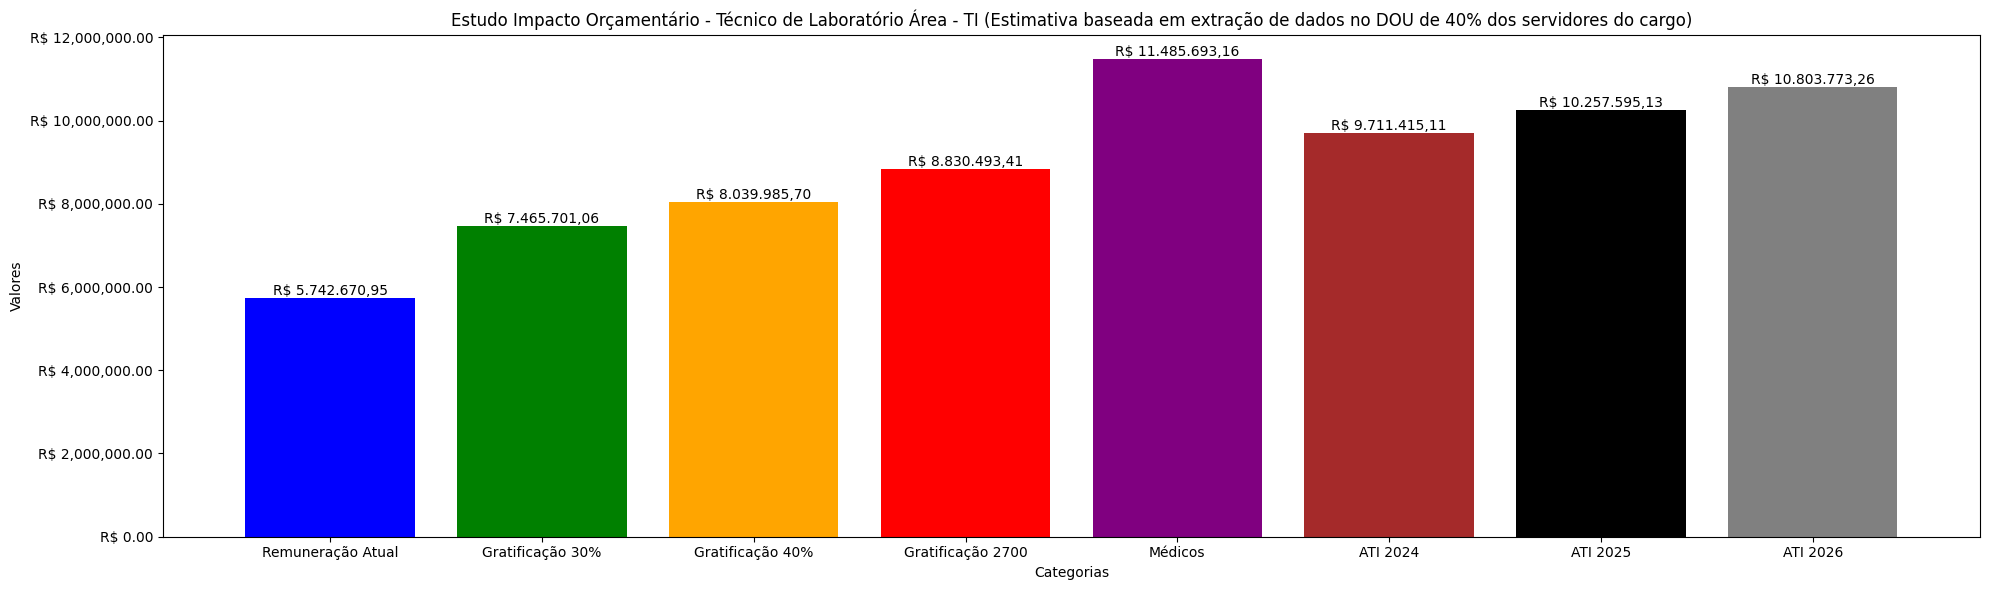

In [ ]:
total_remuneracao_atual_tlab_ti = df_cadastro_remuneracao_mec_tlab_ti['REMUNERAÇÃO BÁSICA BRUTA (R$)'].sum()
total_grat_30_perc_tlab_ti = df_cadastro_remuneracao_mec_tlab_ti['GRAT_30'].sum()
total_grat_40_perc_tlab_ti = df_cadastro_remuneracao_mec_tlab_ti['GRAT_40'].sum()
total_grat_2700_tlab_ti = df_cadastro_remuneracao_mec_tlab_ti['GRAT_2700'].sum()
total_medic_tlab_ti = df_cadastro_remuneracao_mec_tlab_ti['MEDIC'].sum()
total_ati_2024_tlab_ti = df_cadastro_remuneracao_mec_tlab_ti['ATI'].sum()
total_ati_2025_tlab_ti = df_cadastro_remuneracao_mec_tlab_ti['ATI_2025'].sum()
total_ati_2026_tlab_ti = df_cadastro_remuneracao_mec_tlab_ti['ATI_2026'].sum()

# Valores com a estimativa baseada na extração DOU
total_remuneracao_atual_tlab_ti_estim = (total_remuneracao_atual_tlab_ti*100)/sum_data_tlab['Porcentagem do Total'][1]
total_grat_30_perc_tlab_ti_estim = (total_grat_30_perc_tlab_ti*100)/sum_data_tlab['Porcentagem do Total'][1]
total_grat_40_perc_tlab_ti_estim = (total_grat_40_perc_tlab_ti*100)/sum_data_tlab['Porcentagem do Total'][1]
total_grat_2700_tlab_ti_estim = (total_grat_2700_tlab_ti*100)/sum_data_tlab['Porcentagem do Total'][1]
total_medic_tlab_ti_estim = (total_medic_tlab_ti*100)/sum_data_tlab['Porcentagem do Total'][1]
total_ati_2024_tlab_ti_estim = (total_ati_2024_tlab_ti*100)/sum_data_tlab['Porcentagem do Total'][1]
total_ati_2025_tlab_ti_estim = (total_ati_2025_tlab_ti*100)/sum_data_tlab['Porcentagem do Total'][1]
total_ati_2026_tlab_ti_estim = (total_ati_2026_tlab_ti*100)/sum_data_tlab['Porcentagem do Total'][1]

categorias = ['Remuneração Atual', 'Gratificação 30%', 'Gratificação 40%', 'Gratificação 2700', 'Médicos', 'ATI 2024', 'ATI 2025', 'ATI 2026']
valores = [
    total_remuneracao_atual_tlab_ti_estim,
    total_grat_30_perc_tlab_ti_estim,
    total_grat_40_perc_tlab_ti_estim,
    total_grat_2700_tlab_ti_estim,
    total_medic_tlab_ti_estim,
    total_ati_2024_tlab_ti_estim,
    total_ati_2025_tlab_ti_estim,
    total_ati_2026_tlab_ti_estim
]

# Cores diferentes para cada barra
cores = ['blue', 'green', 'orange', 'red', 'purple', 'brown', 'black', 'gray']

# Configurar o tamanho da figura
plt.figure(figsize=(20, 6))

# Criar gráfico de barras com cores
bars = plt.bar(categorias, valores, color=cores)

# Adicionar rótulos e título
plt.xlabel('Categorias')
plt.ylabel('Valores')
plt.title('Estudo Impacto Orçamentário - Técnico de Laboratório Área - TI (Estimativa baseada em extração de dados no DOU de 40% dos servidores do cargo)')

# Adicionar rótulos com os valores formatados em moeda brasileira acima das barras
for bar, valor in zip(bars, valores):
    formatted_value = format_currency(Decimal(str(valor)), 'BRL', locale='pt_BR')
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000, formatted_value, ha='center', va='bottom')

# Formatar eixo y como moeda brasileira
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('R$ {x:,.2f}'))

# Exibir o gráfico
plt.tight_layout()
plt.show()


### Comparativo  Carreiras de TI - Serviço Público

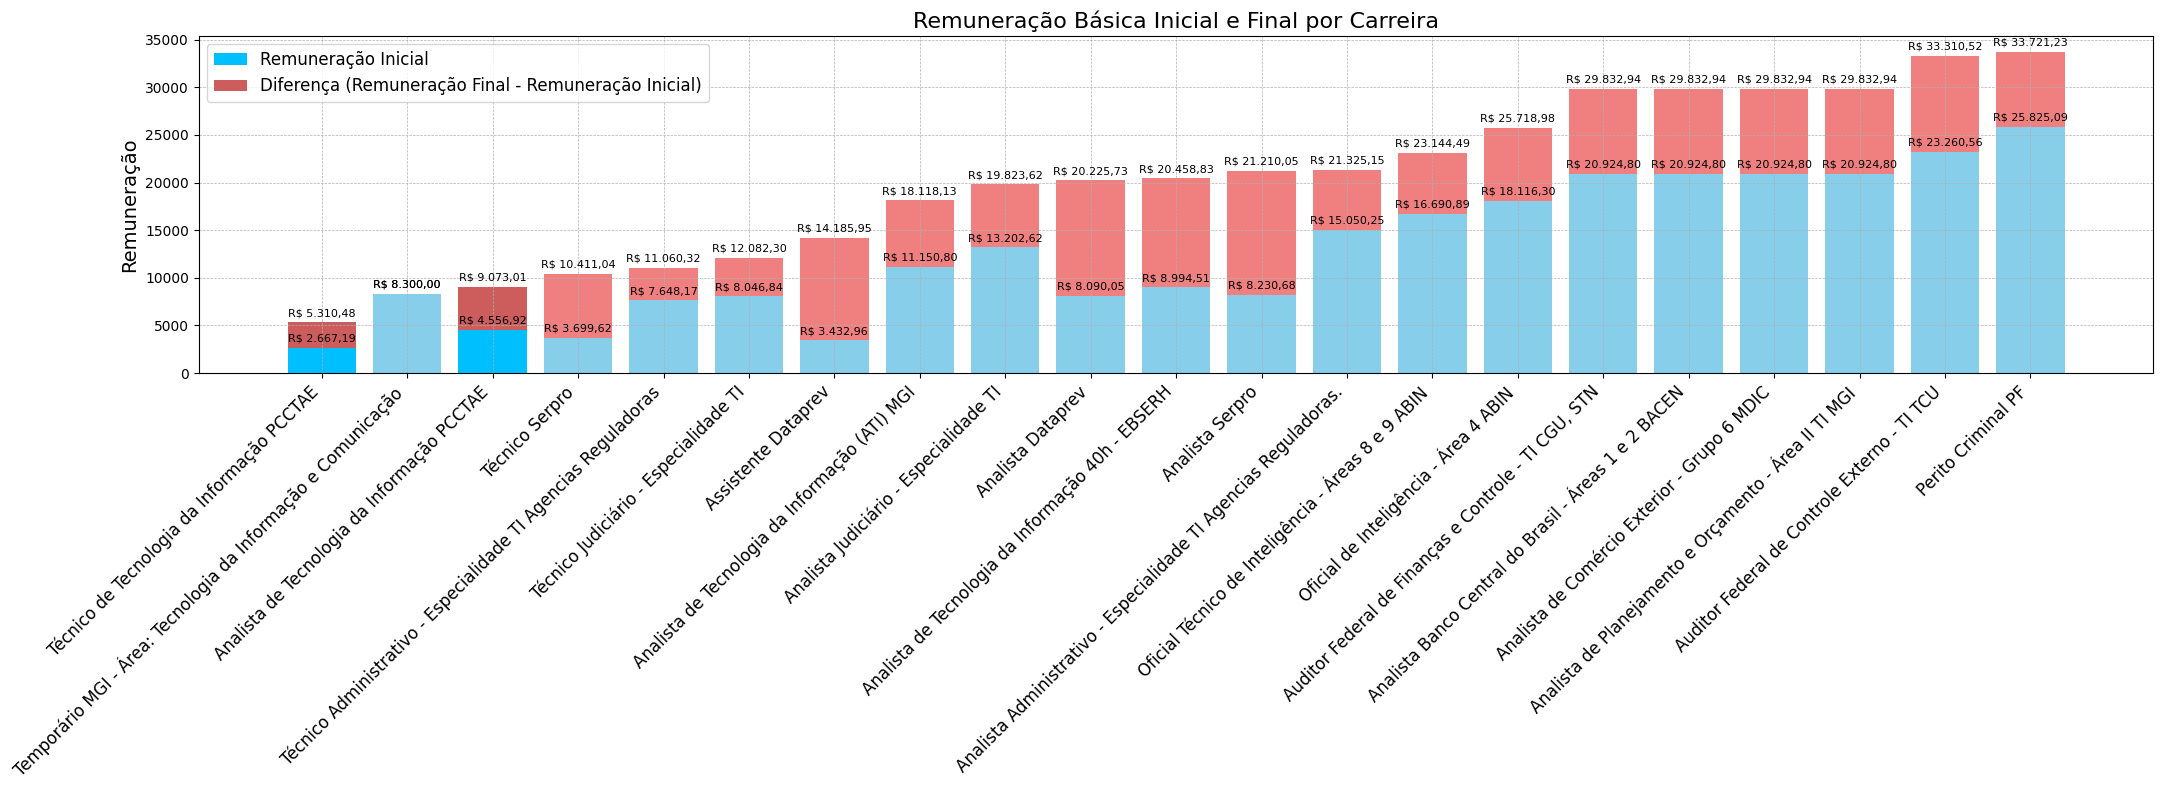

,Carreira,Remuneração Inicial,Remuneração Final
19,Técnico de Tecnologia da Informação PCCTAE,2667.19,5310.48
17,Temporário MGI - Área: Tecnologia da Informaçã...,8300.0,8300.0
20,Analista de Tecnologia da Informação PCCTAE,4556.92,9073.01
...,...,...,...
15,Analista de Planejamento e Orçamento - Área II...,20924.8,29832.94
11,Auditor Federal de Controle Externo - TI TCU,23260.56,33310.52
4,Perito Criminal PF,25825.09,33721.23


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from babel.numbers import format_currency

# Adicionando os dados do PCCTAE
novos_dados_carreira = {
    'Carreira': ['Técnico de Tecnologia da Informação PCCTAE', 'Analista de Tecnologia da Informação PCCTAE'],
    'Remuneração Inicial': [valor_padrao_vencimento("D", 101, df_nivel), valor_padrao_vencimento("E", 101, df_nivel)],
    'Remuneração Final': [valor_padrao_vencimento("D", 416, df_nivel), valor_padrao_vencimento("E", 416, df_nivel)]
}

# Criar um DataFrame com os novos dados
df_nova_carreira = pd.DataFrame(novos_dados_carreira)

# Concatenar os DataFrames existente e o novo
df_salarios_carreiras = pd.concat([df_salarios_carreiras, df_nova_carreira], ignore_index=True)

# Ordenar o DataFrame pelo Salário Final
df_salarios_carreiras = df_salarios_carreiras.sort_values(by='Remuneração Final', ascending=True)

# Filtrar para incluir apenas as 11 primeiras carreiras
#df_salarios_carreiras = df_salarios_carreiras.head(22)

# Função para formatar valores em moeda brasileira
def format_brl(value):
    return format_currency(value, 'BRL', locale='pt_BR')

# Destacar as carreiras específicas com cores diferentes
highlight_careers = ['Técnico de Tecnologia da Informação PCCTAE', 'Analista de Tecnologia da Informação PCCTAE']
colors_initial = ['deepskyblue' if career in highlight_careers else 'skyblue' for career in df_salarios_carreiras['Carreira']]
colors_final = ['indianred' if career in highlight_careers else 'lightcoral' for career in df_salarios_carreiras['Carreira']]

# Plotar o gráfico de barras empilhadas
fig, ax = plt.subplots(figsize=(22, 8))

# Barra do Salário Inicial
bars1 = ax.bar(df_salarios_carreiras['Carreira'], df_salarios_carreiras['Remuneração Inicial'], label='Remuneração Inicial', color=colors_initial)

# Barra do Salário Final
bars2 = ax.bar(df_salarios_carreiras['Carreira'], df_salarios_carreiras['Remuneração Final'] - df_salarios_carreiras['Remuneração Inicial'],
               bottom=df_salarios_carreiras['Remuneração Inicial'], label='Diferença (Remuneração Final - Remuneração Inicial)', color=colors_final)

# Adicionar valores nas barras
for bar in bars1:
    height = bar.get_height()
    ax.annotate(format_brl(height),
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8, color='black')

for bar in bars2:
    height = bar.get_height() + bar.get_y()
    ax.annotate(format_brl(height),
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8, color='black')

# Configurações do gráfico
ax.set_ylabel('Remuneração', fontsize=14)
ax.set_title('Remuneração Básica Inicial e Final por Carreira', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Rotacionar rótulos do eixo x para melhor visualização
plt.xticks(rotation=45, ha='right', fontsize=12)

plt.tight_layout()
plt.show()

df_salarios_carreiras


## 04 - Modelagem e Desenvolvimento

A princípio não há modelos para realização de previsões neste estudo.



## 05 - Interpretação e Comunicação dos Resultados


### Quantitativo resumo

In [ ]:
import numpy as np
sum_pcctae = df_cadastro_remuneracao_mec_pcctae.shape[0]
sum_ati = df_cadastro_remuneracao_mec_ati.shape[0]
sum_tecn = df_cadastro_remuneracao_mec_tecn_ti.shape[0]
sum_tti = df_cadastro_remuneracao_mec_tti.shape[0]
sum_tlab = df_cadastro_remuneracao_mec_tlab_ti.shape[0]

sum_tecn_estim = Decimal((sum_tecn*100)/sum_data_tecn['Porcentagem do Total'][1]).quantize(Decimal('0'))
sum_tlab_estim = Decimal((sum_tlab*100)/sum_data_tlab['Porcentagem do Total'][1]).quantize(Decimal('0'))

# Criar um DataFrame com o somatorio
sum_cargos_data = {
    'Cargo': ['Total Cargos MEC',
              'Total Cargos PCCTAE',
              'Analistas de TI',
              'Técnicos de TI',
              'Tecnólogos-formação Área TI - Estim.',
              'Técnicos de Laboratório Área TI - Estim.',
              'Total cargos de TI - Estim.'],
    'Quantidade': [df_cadastro_remuneracao_mec.shape[0],
           sum_pcctae,
           sum_ati,
           sum_tti,
           sum_tecn_estim,
           sum_tlab_estim,
           sum_ati + sum_tti + sum_tecn_estim + sum_tlab_estim],
    '% em relação ao MEC': [100,
           Decimal((sum_pcctae / df_cadastro_remuneracao_mec.shape[0]) * 100).quantize(Decimal('0.000')),
           Decimal((sum_ati / df_cadastro_remuneracao_mec.shape[0]) * 100).quantize(Decimal('0.000')),
           Decimal((sum_tti / df_cadastro_remuneracao_mec.shape[0]) * 100).quantize(Decimal('0.000')),
           Decimal((sum_tecn_estim / df_cadastro_remuneracao_mec.shape[0]) * 100).quantize(Decimal('0.000')),
           Decimal((sum_tlab_estim / df_cadastro_remuneracao_mec.shape[0]) * 100).quantize(Decimal('0.000')),
           Decimal((sum_ati + sum_tti + sum_tecn_estim + sum_tlab_estim) / df_cadastro_remuneracao_mec.shape[0] * 100).quantize(Decimal('0.000'))],
    '% em relação ao PCCTAE': ["-",
           Decimal((sum_pcctae / df_cadastro_remuneracao_mec_pcctae.shape[0]) * 100).quantize(Decimal('0.000')),
           Decimal((sum_ati / df_cadastro_remuneracao_mec_pcctae.shape[0]) * 100).quantize(Decimal('0.000')),
           Decimal((sum_tti / df_cadastro_remuneracao_mec_pcctae.shape[0]) * 100).quantize(Decimal('0.000')),
           Decimal((sum_tecn_estim / df_cadastro_remuneracao_mec_pcctae.shape[0]) * 100).quantize(Decimal('0.000')),
           Decimal((sum_tlab_estim / df_cadastro_remuneracao_mec_pcctae.shape[0]) * 100).quantize(Decimal('0.000')),
           Decimal((sum_ati + sum_tti + sum_tecn_estim + sum_tlab_estim) / df_cadastro_remuneracao_mec_pcctae.shape[0] * 100).quantize(Decimal('0.000'))]
}

quantitativo_resumo = pd.DataFrame(sum_cargos_data)
# Convertendo a coluna "Quantidade" para inteiro
quantitativo_resumo['Quantidade'] = quantitativo_resumo['Quantidade'].astype(int)

quantitativo_resumo

,Cargo,Quantidade,% em relação ao MEC,% em relação ao PCCTAE
0,Total Cargos MEC,266282,100,-
1,Total Cargos PCCTAE,132173,49.636,100.000
2,Analistas de TI,2874,1.079,2.174
3,Técnicos de TI,3601,1.352,2.724
4,Tecnólogos-formação Área TI - Estim.,103,0.039,0.078
5,Técnicos de Laboratório Área TI - Estim.,1152,0.433,0.872
6,Total cargos de TI - Estim.,7730,2.903,5.848


### Dados orçamentários

Valores mensais

In [ ]:
# Configurar opção para exibir números flutuantes sem notação científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)

sum_remuneracao = df_cadastro_remuneracao['REMUNERAÇÃO BÁSICA BRUTA (R$)'].sum()
sum_remuneracao_mec = df_cadastro_remuneracao_mec['REMUNERAÇÃO BÁSICA BRUTA (R$)'].sum()
sum_remuneracao_pcctae = df_cadastro_remuneracao_mec_pcctae['REMUNERAÇÃO BÁSICA BRUTA (R$)'].sum()

total_remuneracao_atual_tecn_ti_estim = (total_remuneracao_atual_tecn_ti*100)/Decimal(sum_data_tecn['Porcentagem do Total'][1])
total_remuneracao_atual_tlab_ti_estim = (total_remuneracao_atual_tlab_ti*100)/Decimal(sum_data_tlab['Porcentagem do Total'][1])

# Criar um DataFrame com o somatorio
sum_data = {
    'Cargo': ['Remuneração Total Gov',
              'Remuneração Total MEC',
              'Remuneração Total PCCTAE',
              'Analistas de TI',
              'Técnicos de TI',
              'Tecnólogos-formação Área TI - Estim.',
              'Técnicos de Laboratório Área TI - Estim.',
              'Total TI - Estim.'
              ],
    'Remuneração Básica Bruta Total EM REAIS': [sum_remuneracao,
                                            sum_remuneracao_mec,
                                            sum_remuneracao_pcctae,
                                            total_remuneracao_atual_ati,
                                            total_remuneracao_atual_tti,
                                            total_remuneracao_atual_tecn_ti_estim,
                                            total_remuneracao_atual_tlab_ti_estim,
                                            total_remuneracao_atual_ati + total_remuneracao_atual_tti + total_remuneracao_atual_tlab_ti_estim + total_remuneracao_atual_tecn_ti_estim]
}


df_sum_remuneracao = pd.DataFrame(sum_data)

# Criando outro data frame para axibir em formato de moeda brasileira
df_sum_remuneracao_print = df_sum_remuneracao.copy()
df_sum_remuneracao_print['Remuneração Básica Bruta Total EM REAIS'] = df_sum_remuneracao['Remuneração Básica Bruta Total EM REAIS'].map(lambda x: format_currency(Decimal(x), 'BRL', locale='pt_BR'))

pd.set_option('display.max_rows', None)
df_sum_remuneracao_print

,Cargo,Remuneração Básica Bruta Total EM REAIS
0,Remuneração Total Gov,"R$ 6.024.752.212,39"
1,Remuneração Total MEC,"R$ 3.181.838.603,52"
2,Remuneração Total PCCTAE,"R$ 1.021.652.318,81"
3,Analistas de TI,"R$ 28.168.132,22"
4,Técnicos de TI,"R$ 17.880.176,32"
5,Tecnólogos-formação Área TI - Estim.,"R$ 896.460,17"
6,Técnicos de Laboratório Área TI - Estim.,"R$ 5.742.670,95"
7,Total TI - Estim.,"R$ 52.687.439,67"


#### Análise Folha MEC x Cargos TI

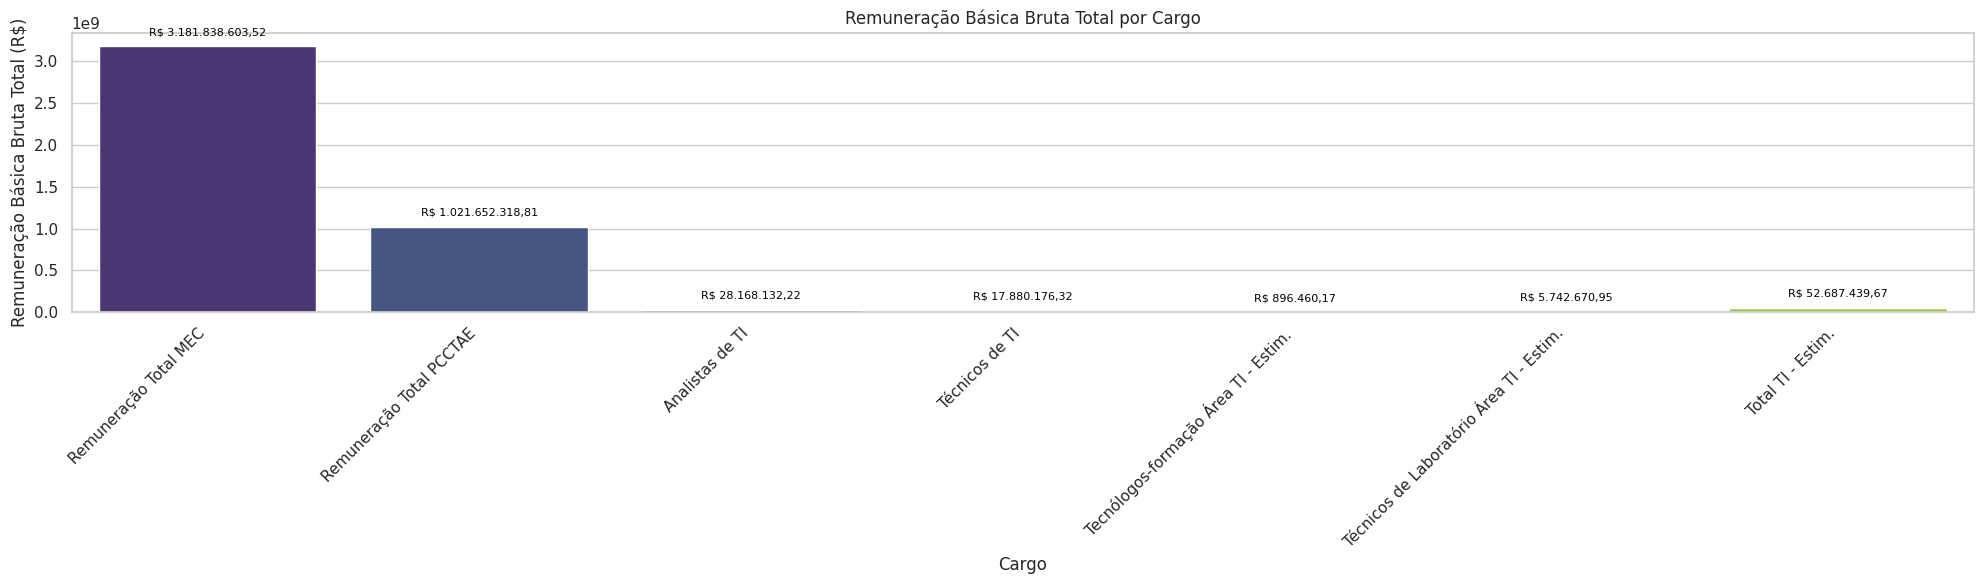

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Escolher apenas as colunas desejadas
cargos_selecionados = ['Total TI - Estim.', 'Analistas de TI', 'Tecnólogos-formação Área TI - Estim.', 'Técnicos de TI', 'Técnicos de Laboratório Área TI - Estim.', 'Remuneração Total PCCTAE', 'Remuneração Total MEC']
df_plot = df_sum_remuneracao[df_sum_remuneracao['Cargo'].isin(cargos_selecionados)]

# Configurar o estilo seaborn apenas para melhorar a estética do gráfico
sns.set(style="whitegrid")

# Criar o gráfico de barras
plt.figure(figsize=(20, 6))
barplot = sns.barplot(x='Cargo', y='Remuneração Básica Bruta Total EM REAIS', hue='Cargo', data=df_plot, palette='viridis', legend=False)

# Adicionar rótulos nas barras
for p in barplot.patches:
    value = p.get_height()
    formatted_value = format_currency(Decimal(str(value)), 'BRL', locale='pt_BR')
    barplot.annotate(f'{formatted_value}', (p.get_x() + p.get_width() / 2., value),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=8, color='black')

# Adicionar grade horizontal
plt.axhline(0, color='gray', linewidth=0.8, linestyle='dashed', alpha=0.7)

# Ajustar layout
plt.xticks(rotation=45, ha='right')
plt.xlabel('Cargo')
plt.ylabel('Remuneração Básica Bruta Total (R$)')
plt.title('Remuneração Básica Bruta Total por Cargo')

# Exibir o gráfico
plt.tight_layout()
plt.show()


#### Análises entre os TIs


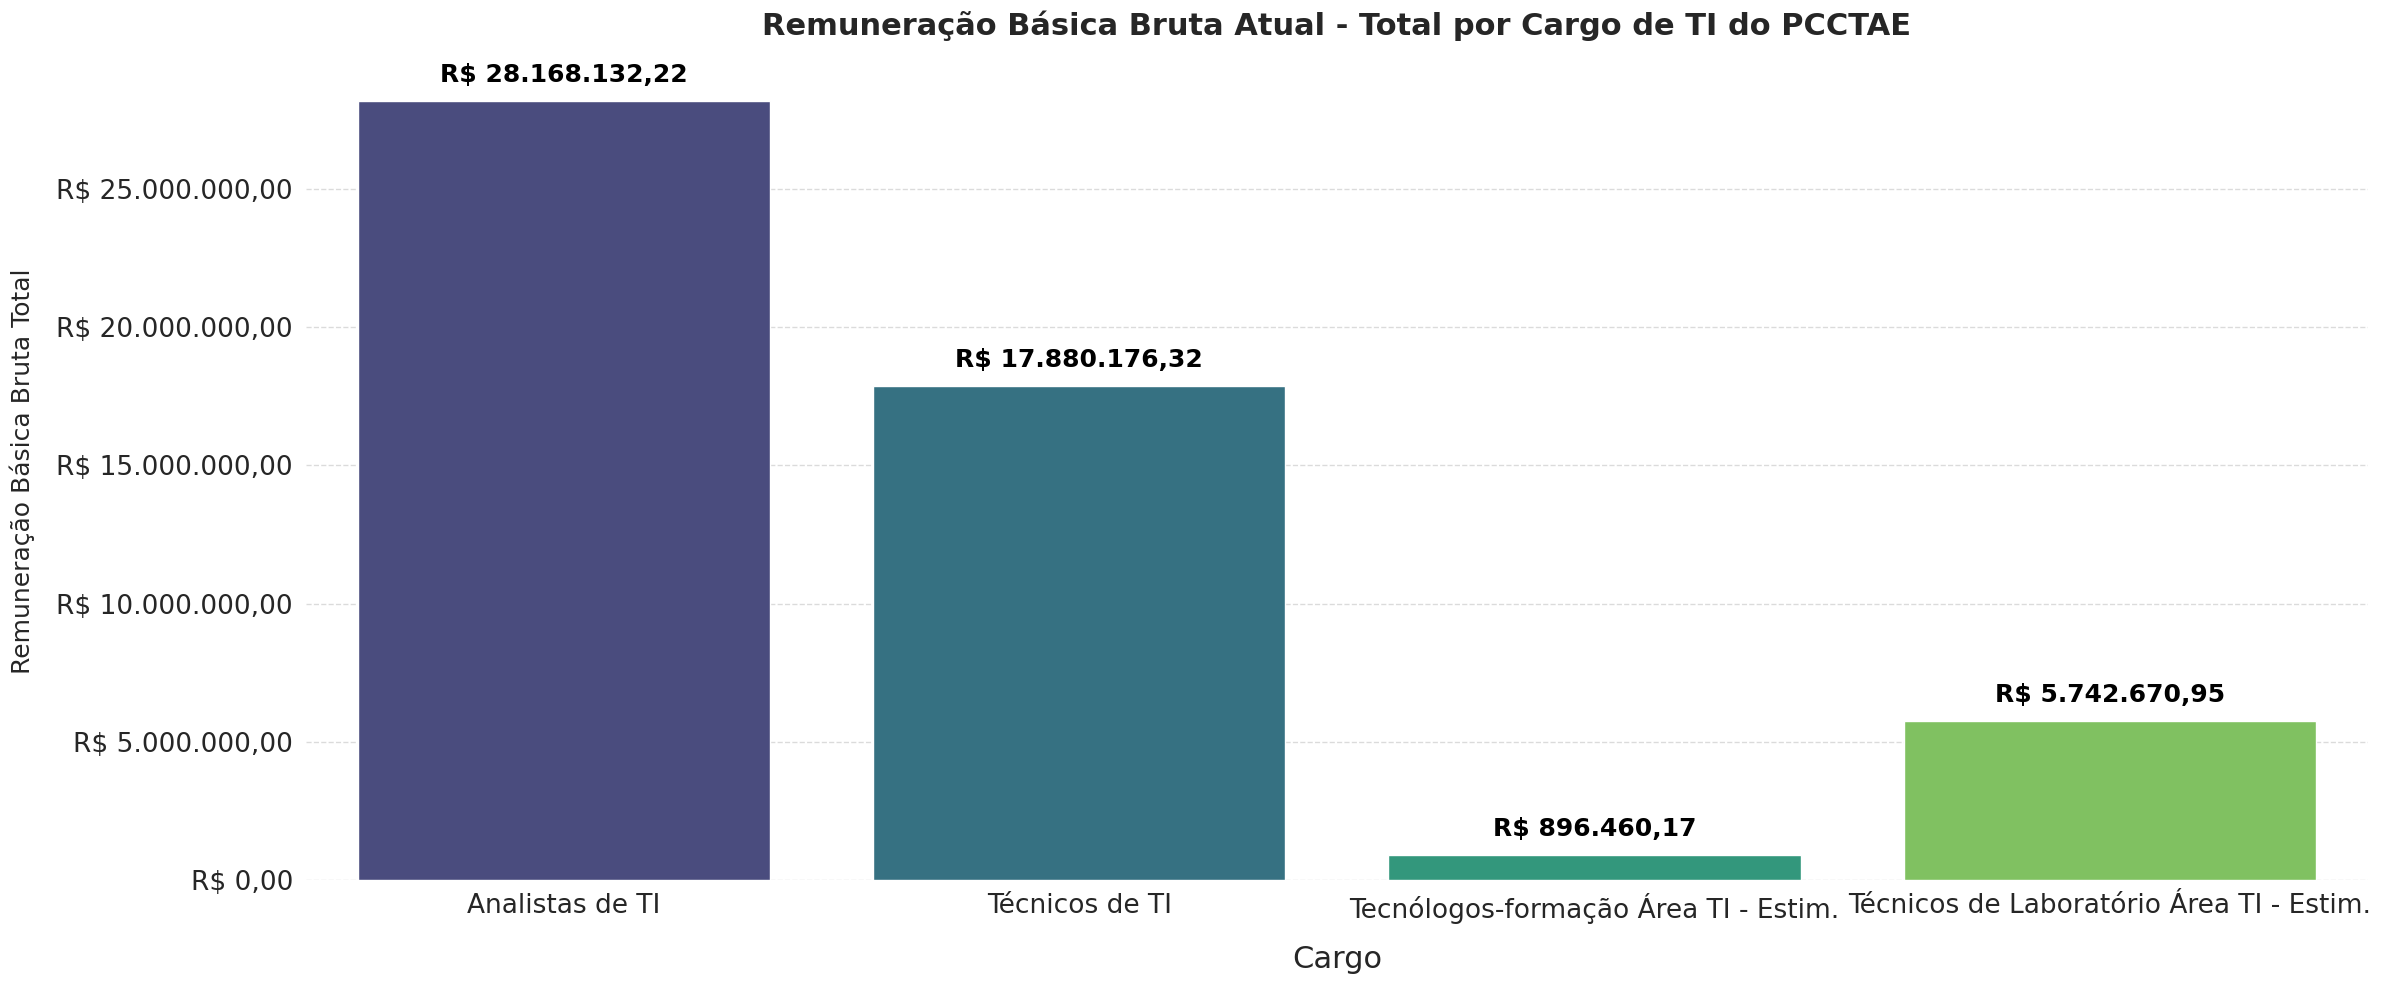

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from decimal import Decimal
from babel.numbers import format_currency

# Escolher apenas as colunas desejadas
cargos_selecionados = [
    'Analistas de TI',
    'Tecnólogos-formação Área TI - Estim.',
    'Técnicos de TI',
    'Técnicos de Laboratório Área TI - Estim.'
]

df_plot = df_sum_remuneracao[df_sum_remuneracao['Cargo'].isin(cargos_selecionados)]

# Configurar o estilo seaborn
sns.set(style="whitegrid")

# Criar o gráfico de barras com margens melhoradas
plt.figure(figsize=(24, 10))

# Criar o barplot
barplot = sns.barplot(
    x='Cargo',
    y='Remuneração Básica Bruta Total EM REAIS',
    hue='Cargo',
    data=df_plot,
    palette='viridis',
    legend=False
)

# Adicionar rótulos nas barras com formatação de moeda
for p in barplot.patches:
    value = p.get_height()
    formatted_value = format_currency(Decimal(str(value)), 'BRL', locale='pt_BR')
    barplot.annotate(
        f'{formatted_value}',
        (p.get_x() + p.get_width() / 2., value),
        ha='center',
        va='bottom',  # Mudado para 'bottom' para ficar acima da barra
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=18,
        color='black',
        weight='bold'  # Fonte em negrito para melhor visibilidade
    )

# Formatar o eixo Y para mostrar valores em reais
import matplotlib.ticker as ticker

def currency_formatter(x, pos):
    return format_currency(Decimal(str(x)), 'BRL', locale='pt_BR')

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(currency_formatter))

# Adicionar grade horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajustar labels e títulos com mais espaço
#plt.xticks(rotation=30, ha='right', fontsize=16)  # Rotação reduzida para melhor leitura
plt.xlabel('Cargo', fontsize=22, labelpad=15)
plt.ylabel('Remuneração Básica Bruta Total', fontsize=18, labelpad=15)
plt.title('Remuneração Básica Bruta Atual - Total por Cargo de TI do PCCTAE',
          fontsize=22,
          pad=20,  # Aumentar o padding do título
          weight='bold')

# Adicionar padding extra ao redor do gráfico
plt.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.2)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
sns.despine(top=True, right=True, left=True, bottom=True)
# Exibir o gráfico com layout ajustado
plt.tight_layout()
plt.show()


### Todos os custos em análise



In [ ]:
# @title
from babel.numbers import format_currency
import openpyxl

# Somando os gastos de ATI e TTI para cada proposta
total_remuneracao_atual_TI = total_remuneracao_atual_ati + total_remuneracao_atual_tti + total_remuneracao_atual_tlab_ti_estim + total_remuneracao_atual_tecn_ti_estim
total_medic_TI = total_medic_ati + total_medic_tti + total_medic_tlab_ti_estim + total_medic_tecn_ti_estim
total_ati_2024_TI = total_ati_2024_ati + total_ati_2024_tecn_ti_estim
total_ati_2025_TI = total_ati_2025_ati + total_ati_2025_tecn_ti_estim
total_ati_2026_TI = total_ati_2026_ati + total_ati_2026_tecn_ti_estim
total_grat_30_perc_TI = total_grat_30_perc_ati + total_grat_30_perc_tti + total_grat_30_perc_tlab_ti_estim + total_grat_30_perc_tecn_ti_estim
total_grat_40_perc_TI = total_grat_40_perc_ati + total_grat_40_perc_tti + total_grat_40_perc_tlab_ti_estim + total_grat_40_perc_tecn_ti_estim
total_grat_fixa_TI = total_grat_4500_ati + total_grat_2700_tti + total_grat_2700_tlab_ti_estim + total_grat_4500_tecn_ti_estim
dedicacao_exclusiva = total_remuneracao_atual_TI * Decimal(1.4)

analise_geral = {
    'Cargo': ['Rem. Total MEC - Atual',
              'Analistas de TI - atual',
              '* Tecnólogo Formação TI - atual',
              '* Técnicos de TI - atual',
              '* Téc. Laboratorio TI - atual',
              'Cargos de TI - Atual',
              'Proposta Médicos',
              '** Proposta ATI 2024',
              '** Proposta ATI 2025',
              '** Proposta ATI 2026',
              '*** Proposta ATI 2024 + 2700 tti',
              '*** Proposta ATI 2025 + 2700 tti',
              '*** Proposta ATI 2026 + 2700 tti',
              'Proposta 30% RMB',
              'Proposta GT 4500/2700',
              'Dedicação Excl.'
              ],
    'Total (R$)': [sum_remuneracao_mec,
                  total_remuneracao_atual_ati,
                  total_remuneracao_atual_tecn_ti_estim,
                  total_remuneracao_atual_tti,
                  total_remuneracao_atual_tlab_ti_estim,
                  total_remuneracao_atual_TI,
                  total_medic_TI,
                  total_ati_2024_TI,
                  total_ati_2025_TI,
                  total_ati_2026_TI,
                  total_ati_2024_TI + total_grat_2700_tti,
                  total_ati_2025_TI + total_grat_2700_tti,
                  total_ati_2026_TI  + total_grat_2700_tti,
                  total_grat_30_perc_TI,
                  total_grat_fixa_TI,
                  dedicacao_exclusiva,
                  ],
      'Acréscimo na folha (R$)': [sum_remuneracao_mec-sum_remuneracao_mec,
                  total_remuneracao_atual_ati-total_remuneracao_atual_ati,
                  total_remuneracao_atual_tecn_ti_estim-total_remuneracao_atual_tecn_ti_estim,
                  total_remuneracao_atual_tti-total_remuneracao_atual_tti,
                  total_remuneracao_atual_tlab_ti_estim-total_remuneracao_atual_tlab_ti_estim,
                  total_remuneracao_atual_TI-total_remuneracao_atual_TI,
                  total_medic_TI-total_remuneracao_atual_TI,
                  total_ati_2024_TI-(total_remuneracao_atual_ati+total_remuneracao_atual_tecn_ti_estim),
                  total_ati_2025_TI-(total_remuneracao_atual_ati+total_remuneracao_atual_tecn_ti_estim),
                  total_ati_2026_TI-(total_remuneracao_atual_ati+total_remuneracao_atual_tecn_ti_estim),
                  total_ati_2024_TI+total_grat_2700_tti-total_remuneracao_atual_TI,
                  total_ati_2025_TI+total_grat_2700_tti-total_remuneracao_atual_TI,
                  total_ati_2026_TI+total_grat_2700_tti-total_remuneracao_atual_TI,
                  total_grat_30_perc_TI-total_remuneracao_atual_TI,
                  total_grat_fixa_TI-total_remuneracao_atual_TI,
                  dedicacao_exclusiva-total_remuneracao_atual_TI,
                  ],
    'Perc. em relação ao MEC - %': ['0.00',
                                    (100 * (total_remuneracao_atual_ati / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * (total_remuneracao_atual_tecn_ti_estim / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * (total_remuneracao_atual_tti / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * (total_remuneracao_atual_tlab_ti_estim / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * (total_remuneracao_atual_TI / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * (total_medic_TI / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * (total_ati_2024_TI / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * (total_ati_2025_TI / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * (total_ati_2026_TI / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * ((total_ati_2024_TI+total_grat_2700_tti) / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * ((total_ati_2025_TI+total_grat_2700_tti) / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * ((total_ati_2026_TI+total_grat_2700_tti) / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (total_grat_30_perc_TI / Decimal(sum_remuneracao_mec)).quantize(Decimal('00.000'), rounding=ROUND_HALF_UP),
                                    (total_grat_fixa_TI / Decimal(sum_remuneracao_mec)).quantize(Decimal('00.000'), rounding=ROUND_HALF_UP),
                                    (dedicacao_exclusiva / Decimal(sum_remuneracao_mec)).quantize(Decimal('00.000'), rounding=ROUND_HALF_UP)
                                     ],

    'Perc. real de aumento  folha MEC- %': ['0.00',
                                    '0.00',
                                    '0.00',
                                    '0.00',
                                    '0.00',
                                    '0.00',
                                    (100 * ((total_medic_TI-total_remuneracao_atual_TI) / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * ((total_ati_2024_TI-total_remuneracao_atual_ati) / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * ((total_ati_2025_TI-total_remuneracao_atual_ati) / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * ((total_ati_2026_TI-total_remuneracao_atual_ati) / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * (((total_ati_2024_TI+total_grat_2700_tti)-total_remuneracao_atual_TI) / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * (((total_ati_2025_TI+total_grat_2700_tti)-total_remuneracao_atual_TI) / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * (((total_ati_2026_TI+total_grat_2700_tti)-total_remuneracao_atual_TI) / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * ((total_grat_30_perc_TI-total_remuneracao_atual_TI) / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * ((total_grat_fixa_TI-total_remuneracao_atual_TI) / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (10 * ((dedicacao_exclusiva-total_remuneracao_atual_TI) / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                     ]
}

df_analise_geral = pd.DataFrame(analise_geral)

# Configurando o Pandas para exibir somente 15 linhas
pd.set_option('display.max_rows', 15)

# Formatar os valores como moeda brasileira
df_analise_geral['Total (R$)'] = df_analise_geral['Total (R$)'].map(lambda x: format_currency(Decimal(x), 'BRL', locale='pt_BR'))
df_analise_geral['Acréscimo na folha (R$)'] = df_analise_geral['Acréscimo na folha (R$)'].map(lambda x: format_currency(Decimal(x), 'BRL', locale='pt_BR'))

#expandir a visão dos dados pra não ter quebra de linha
pd.set_option('display.expand_frame_repr', False)
#exportando o dataframe para csv
df_analise_geral.to_csv('analise_geral.csv', index=False)

print("")
print("Observações")
print("* Tecnólogos e tti lab foi realizada estimativa com base em extração de dados no DOU de 60% e 40% dos servidores respectivamente.")
print("** Analistas e Tecnólogos indo para carreira ATI/MGISP")
print("*** Analistas e Tecnólogos indo para carreira ATI/MGISP e os técnicos permanecendo no PCCTAE com gratificação de R$ 2.700,00")
print("")
print("")
print("")


def grafico_geral():

    categorias = ['Rem. Atual - Ana', 'Rem. Atual - tecn', 'Rem. Atual - Tec*', 'Rem. Atual - TLab*', 'Rem. total TI', 'Médicos todos TI', 'An. p/ ATI MGISP','An. ATI MGISP + 2700 TTI','Grat. 30% ','Grat. fixa 4500/2700','ATI para MGISP','TTI+2700','Dedicação Excl.']
    valores = [
        total_remuneracao_atual_ati,
        total_remuneracao_atual_tecn_ti_estim,
        total_remuneracao_atual_tti,
        total_remuneracao_atual_tlab_ti_estim,
        total_remuneracao_atual_TI,
        total_remuneracao_atual_TI*2,
        total_ati_2024_TI,
        total_ati_2024_TI + total_grat_2700_tti,
        total_grat_30_perc_TI,
        total_grat_fixa_TI,
        -total_ati_2024_TI,
        total_grat_2700_tti,
        dedicacao_exclusiva,
    ]


    sns.set_style("whitegrid")
    palette = sns.color_palette("bright", len(categorias))
    plt.figure(figsize=(25, 8))
    sns.barplot(x=categorias, y=valores, hue=categorias, palette=palette, legend=False)
    plt.xlabel('Categorias', fontsize=14)
    plt.ylabel('Valores', fontsize=14)
    plt.title('Estudo Impacto Orçamentário - Todas propostas', fontsize=16)
    # Adicionar rótulos com os valores formatados em moeda brasileira acima das barras
    for i, valor in enumerate(valores):
        plt.text(i, valor + 1000, 'R$ {:,.2f}'.format(valor), ha='center', va='bottom', fontsize=10)
    # Formatar eixo y como moeda brasileira
    plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('R$ {x:,.2f}'))
    # Ajustar o layout
    plt.tight_layout()
    # Exibir o gráfico
    plt.show()


pd.set_option('display.max_rows', None)
df_analise_geral


Observações
* Tecnólogos e tti lab foi realizada estimativa com base em extração de dados no DOU de 60% e 40% dos servidores respectivamente.
** Analistas e Tecnólogos indo para carreira ATI/MGISP
*** Analistas e Tecnólogos indo para carreira ATI/MGISP e os técnicos permanecendo no PCCTAE com gratificação de R$ 2.700,00





,Cargo,Total (R$),Acréscimo na folha (R$),Perc. em relação ao MEC - %,Perc. real de aumento folha MEC- %
0,Rem. Total MEC - Atual,"R$ 3.181.838.603,52","R$ 0,00",0.00,0.00
1,Analistas de TI - atual,"R$ 28.168.132,22","R$ 0,00",0.89,0.00
2,* Tecnólogo Formação TI - atual,"R$ 896.460,17","R$ 0,00",0.03,0.00
3,* Técnicos de TI - atual,"R$ 17.880.176,32","R$ 0,00",0.56,0.00
4,* Téc. Laboratorio TI - atual,"R$ 5.742.670,95","R$ 0,00",0.18,0.00
5,Cargos de TI - Atual,"R$ 52.687.439,67","R$ 0,00",1.66,0.00
6,Proposta Médicos,"R$ 105.375.176,49","R$ 52.687.736,83",3.31,1.66
7,** Proposta ATI 2024,"R$ 43.083.751,00","R$ 14.019.158,60",1.35,0.47
8,** Proposta ATI 2025,"R$ 45.962.224,36","R$ 16.897.631,97",1.44,0.56
9,** Proposta ATI 2026,"R$ 48.840.695,65","R$ 19.776.103,25",1.53,0.65


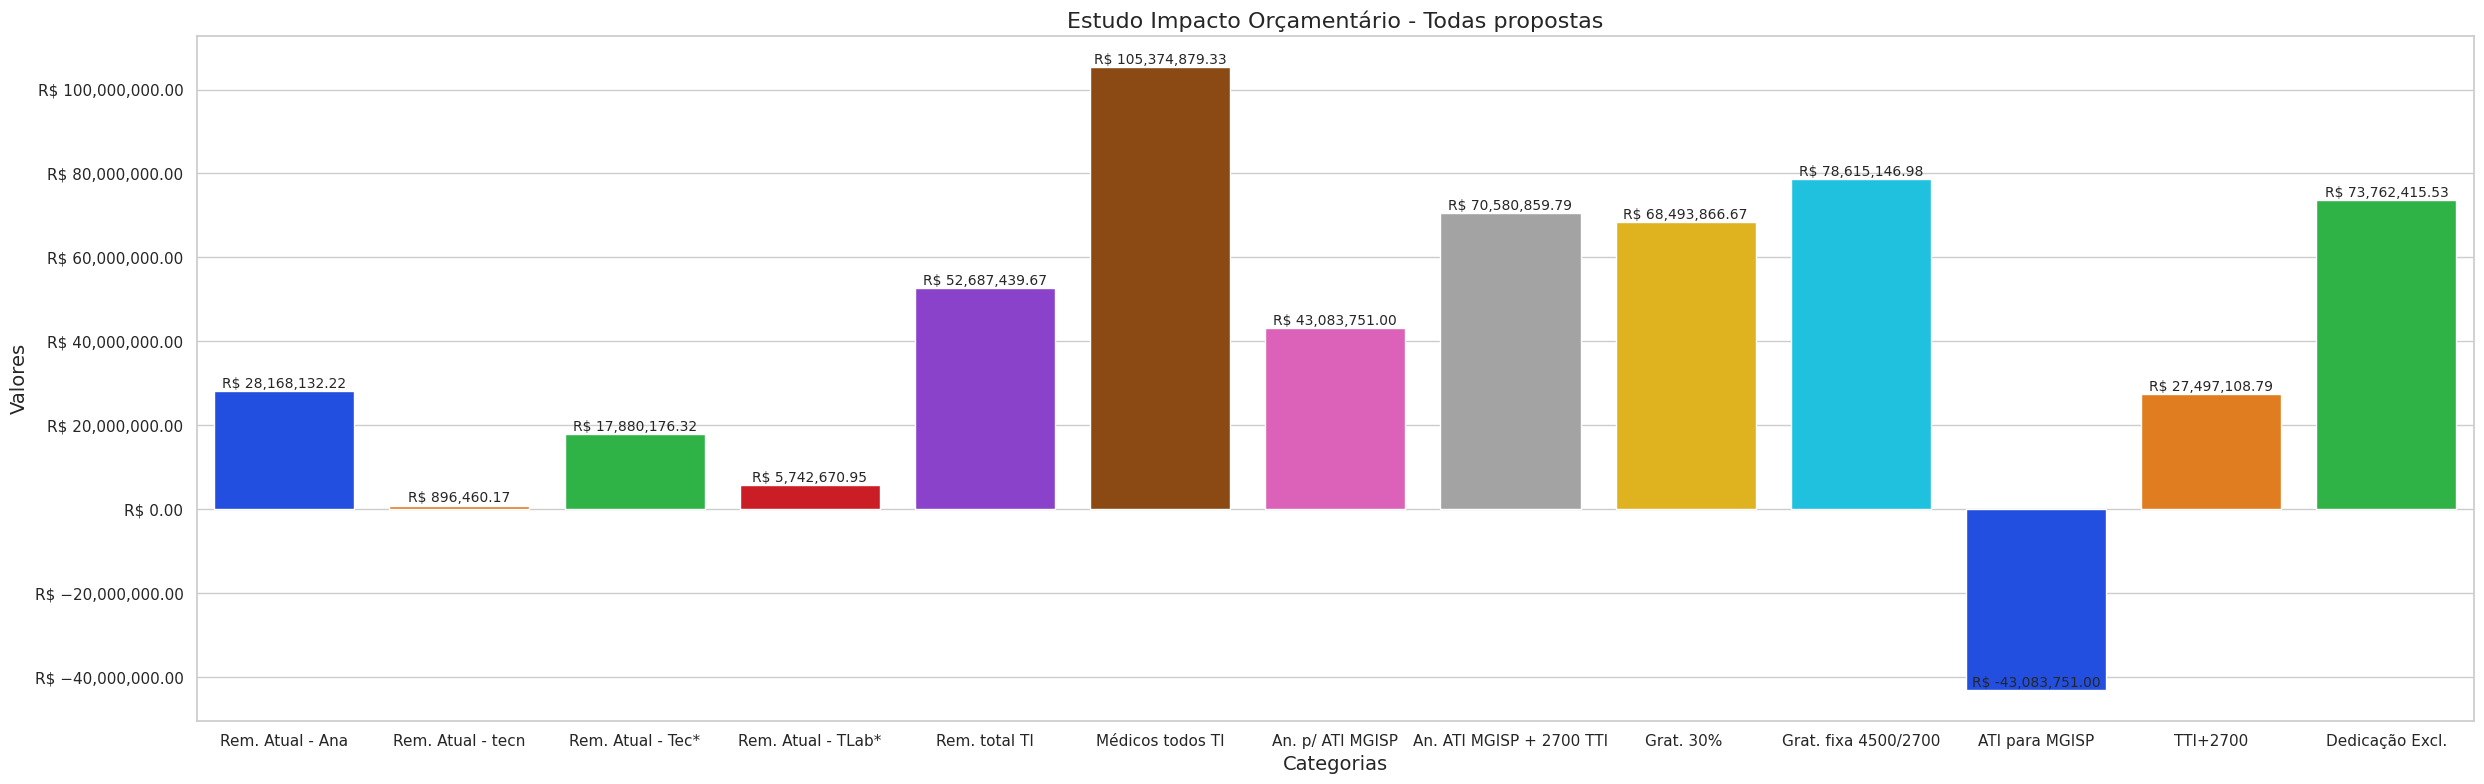

In [ ]:
grafico_geral()


### Proposta Tabela de Cargos Específicos PCCTAE - Médicos/Veterinários


In [ ]:
# @title
from babel.numbers import format_currency
import openpyxl

analise_geral_medic = {
    'Cargo': ['Rem. Total MEC - Atual',
              'Analistas de TI - atual',
              '* Tecnólogo Formação TI - atual',
              '* Técnicos de TI - atual',
              '* Téc. Laboratorio TI - atual',
              'Cargos de TI - Atual',
              'Proposta Médicos'
              ],
    'Total (R$)': [sum_remuneracao_mec,
                  total_remuneracao_atual_ati,
                  total_remuneracao_atual_tecn_ti_estim,
                  total_remuneracao_atual_tti,
                  total_remuneracao_atual_tlab_ti_estim,
                  total_remuneracao_atual_TI,
                  total_remuneracao_atual_TI*2
                  ],
      'Acréscimo na folha (R$)': [sum_remuneracao_mec-sum_remuneracao_mec,
                  total_remuneracao_atual_ati-total_remuneracao_atual_ati,
                  total_remuneracao_atual_tecn_ti_estim-total_remuneracao_atual_tecn_ti_estim,
                  total_remuneracao_atual_tti-total_remuneracao_atual_tti,
                  total_remuneracao_atual_tlab_ti_estim-total_remuneracao_atual_tlab_ti_estim,
                  total_remuneracao_atual_TI-total_remuneracao_atual_TI,
                  total_remuneracao_atual_TI
                  ],
    'Perc. em relação ao MEC - %': ['0.00',
                                    (100 * (total_remuneracao_atual_ati / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * (total_remuneracao_atual_tecn_ti_estim / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * (total_remuneracao_atual_tti / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * (total_remuneracao_atual_tlab_ti_estim / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * (total_remuneracao_atual_TI / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP),
                                    (100 * (total_medic_TI / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP)
                                     ],

    'Perc. real de aumento  folha MEC- %': ['0.00',
                                    '0.00',
                                    '0.00',
                                    '0.00',
                                    '0.00',
                                    '0.00',
                                    (100 * ((total_medic_TI-total_remuneracao_atual_TI) / Decimal(sum_remuneracao_mec))).quantize(Decimal('00.00'), rounding=ROUND_HALF_UP)
                                    ]
}

df_analise_geral_medic = pd.DataFrame(analise_geral_medic)

# Configurando o Pandas para exibir somente 15 linhas
pd.set_option('display.max_rows', 15)

# Formatar os valores como moeda brasileira
df_analise_geral_medic['Total (R$)'] = df_analise_geral_medic['Total (R$)'].map(lambda x: format_currency(Decimal(x), 'BRL', locale='pt_BR'))
df_analise_geral_medic['Acréscimo na folha (R$)'] = df_analise_geral_medic['Acréscimo na folha (R$)'].map(lambda x: format_currency(Decimal(x), 'BRL', locale='pt_BR'))

#expandir a visão dos dados pra não ter quebra de linha
pd.set_option('display.expand_frame_repr', False)
#exportando o dataframe para csv
df_analise_geral_medic.to_csv('df_analise_geral_medic.csv', index=False)

print("")
print("Observações")
print("* Tecnólogos e tti lab foi realizada estimativa com base em extração de dados no DOU de 60% e 40% dos servidores respectivamente.")
print("** Analistas e Tecnólogos indo para carreira ATI/MGISP")
print("*** Analistas e Tecnólogos indo para carreira ATI/MGISP e os técnicos permanecendo no PCCTAE com gratificação de R$ 2.700,00")
print("")
print("")
print("")


pd.set_option('display.max_rows', None)
df_analise_geral_medic


Observações
* Tecnólogos e tti lab foi realizada estimativa com base em extração de dados no DOU de 60% e 40% dos servidores respectivamente.
** Analistas e Tecnólogos indo para carreira ATI/MGISP
*** Analistas e Tecnólogos indo para carreira ATI/MGISP e os técnicos permanecendo no PCCTAE com gratificação de R$ 2.700,00





,Cargo,Total (R$),Acréscimo na folha (R$),Perc. em relação ao MEC - %,Perc. real de aumento folha MEC- %
0,Rem. Total MEC - Atual,"R$ 3.181.838.603,52","R$ 0,00",0.00,0.00
1,Analistas de TI - atual,"R$ 28.168.132,22","R$ 0,00",0.89,0.00
2,* Tecnólogo Formação TI - atual,"R$ 896.460,17","R$ 0,00",0.03,0.00
3,* Técnicos de TI - atual,"R$ 17.880.176,32","R$ 0,00",0.56,0.00
4,* Téc. Laboratorio TI - atual,"R$ 5.742.670,95","R$ 0,00",0.18,0.00
5,Cargos de TI - Atual,"R$ 52.687.439,67","R$ 0,00",1.66,0.00
6,Proposta Médicos,"R$ 105.374.879,33","R$ 52.687.439,67",3.31,1.66


### Custos da Reorganização dos ATIs


In [ ]:
analise_reorganizacao_ati = {
    'Proposta/ano': ['Reorganização ATI / 2024',
              'Reorganização ATI / 2025',
              'Reorganização ATI / 2026',
              ],
    'Custo Total EM REAIS': [total_ati_2024_ati,
                  total_ati_2025_ati,
                  total_ati_2026_ati,],
    'Acréscimo na folha EM REAIS': [total_ati_2024_ati-(total_remuneracao_atual_ati),
                  total_ati_2025_TI-(total_remuneracao_atual_ati),
                  total_ati_2026_TI-(total_remuneracao_atual_ati),]
}

df_analise_reorganizacao_ati = pd.DataFrame(analise_reorganizacao_ati)


# Formatar os valores como moeda brasileira
df_analise_reorganizacao_ati['Custo Total EM REAIS'] = df_analise_reorganizacao_ati['Custo Total EM REAIS'].map(lambda x: format_currency(Decimal(x), 'BRL', locale='pt_BR'))
df_analise_reorganizacao_ati['Acréscimo na folha EM REAIS'] = df_analise_reorganizacao_ati['Acréscimo na folha EM REAIS'].map(lambda x: format_currency(Decimal(x), 'BRL', locale='pt_BR'))

df_analise_reorganizacao_ati

,Proposta/ano,Custo Total EM REAIS,Acréscimo na folha EM REAIS
0,Reorganização ATI / 2024,"R$ 41.707.553,54","R$ 13.539.421,32"
1,Reorganização ATI / 2025,"R$ 44.509.608,81","R$ 17.794.092,14"
2,Reorganização ATI / 2026,"R$ 47.311.662,43","R$ 20.672.563,43"


### Custos da Reorganização dos TTIs
61% do ATI, conforme acordo de greve

In [ ]:
analise_reorganizacao_tti = {
    'Proposta/ano': ['Reorganização TEC TI / 2024',
              'Reorganização TEC TI / 2025',
              'Reorganização TEC TI / 2026',
              ],
    'Custo Total (R$)': [total_ati_2024_tti,
                         total_ati_2025_tti,
                         total_ati_2026_tti],
    'Acréscimo na folha (R$)': [total_ati_2024_tti-(total_remuneracao_atual_tti),
                  total_ati_2025_tti-(total_remuneracao_atual_tti),
                  total_ati_2026_tti-(total_remuneracao_atual_tti),]
}

df_analise_reorganizacao_tti = pd.DataFrame(analise_reorganizacao_tti)


# Formatar os valores como moeda brasileira
df_analise_reorganizacao_tti['Custo Total (R$)'] = df_analise_reorganizacao_tti['Custo Total (R$)'].map(lambda x: format_currency(Decimal(x), 'BRL', locale='pt_BR'))
df_analise_reorganizacao_tti['Acréscimo na folha (R$)'] = df_analise_reorganizacao_tti['Acréscimo na folha (R$)'].map(lambda x: format_currency(Decimal(x), 'BRL', locale='pt_BR'))

df_analise_reorganizacao_tti

,Proposta/ano,Custo Total (R$),Acréscimo na folha (R$)
0,Reorganização TEC TI / 2024,"R$ 30.211.019,45","R$ 12.330.843,13"
1,Reorganização TEC TI / 2025,"R$ 31.887.110,63","R$ 14.006.934,31"
2,Reorganização TEC TI / 2026,"R$ 33.563.202,55","R$ 15.683.026,23"


### Custos da Reorganização dos TECN

In [ ]:
analise_reorganizacao_tecn_ti_estim = {
    'Proposta/ano': ['Reorganização TECN TI / 2024',
              'Reorganização TECN TI / 2025',
              'Reorganização TECN TI / 2026',
              ],
    'Custo Total EM REAIS': [total_ati_2024_tecn_ti_estim,
                         total_ati_2025_tecn_ti_estim,
                         total_ati_2026_tecn_ti_estim],
    'Acréscimo na folha EM REAIS': [total_ati_2024_tecn_ti_estim-(total_remuneracao_atual_tecn_ti_estim),
                  total_ati_2025_tecn_ti_estim-(total_remuneracao_atual_tecn_ti_estim),
                  total_ati_2026_tecn_ti_estim-(total_remuneracao_atual_tecn_ti_estim),]
}

df_analise_reorganizacao_tecn_ti_estim = pd.DataFrame(analise_reorganizacao_tecn_ti_estim)


# Formatar os valores como moeda brasileira
df_analise_reorganizacao_tecn_ti_estim['Custo Total EM REAIS'] = df_analise_reorganizacao_tecn_ti_estim['Custo Total EM REAIS'].map(lambda x: format_currency(Decimal(x), 'BRL', locale='pt_BR'))
df_analise_reorganizacao_tecn_ti_estim['Acréscimo na folha EM REAIS'] = df_analise_reorganizacao_tecn_ti_estim['Acréscimo na folha EM REAIS'].map(lambda x: format_currency(Decimal(x), 'BRL', locale='pt_BR'))

df_analise_reorganizacao_tecn_ti_estim

,Proposta/ano,Custo Total EM REAIS,Acréscimo na folha EM REAIS
0,Reorganização TECN TI / 2024,"R$ 1.376.197,46","R$ 479.737,28"
1,Reorganização TECN TI / 2025,"R$ 1.452.615,55","R$ 556.155,38"
2,Reorganização TECN TI / 2026,"R$ 1.529.033,22","R$ 632.573,04"


### Custos da Reorganização dos TLAB

In [ ]:
analise_reorganizacao_tlab_ti_estim = {
    'Proposta/ano': ['Reorganização TLAB TI / 2024',
              'Reorganização TLAB TI / 2025',
              'Reorganização TLAB TI / 2026',
              ],
    'Custo Total EM REAIS': [total_ati_2024_tlab_ti_estim,
                         total_ati_2025_tlab_ti_estim,
                         total_ati_2026_tlab_ti_estim],
    'Acréscimo na folha EM REAIS': [total_ati_2024_tlab_ti_estim-(total_remuneracao_atual_tlab_ti_estim),
                  total_ati_2025_tlab_ti_estim-(total_remuneracao_atual_tlab_ti_estim),
                  total_ati_2026_tlab_ti_estim-(total_remuneracao_atual_tlab_ti_estim),]
}

df_analise_reorganizacao_tlab_ti_estim = pd.DataFrame(analise_reorganizacao_tlab_ti_estim)


# Formatar os valores como moeda brasileira
df_analise_reorganizacao_tlab_ti_estim['Custo Total EM REAIS'] = df_analise_reorganizacao_tlab_ti_estim['Custo Total EM REAIS'].map(lambda x: format_currency(Decimal(x), 'BRL', locale='pt_BR'))
df_analise_reorganizacao_tlab_ti_estim['Acréscimo na folha EM REAIS'] = df_analise_reorganizacao_tlab_ti_estim['Acréscimo na folha EM REAIS'].map(lambda x: format_currency(Decimal(x), 'BRL', locale='pt_BR'))

df_analise_reorganizacao_tlab_ti_estim

,Proposta/ano,Custo Total EM REAIS,Acréscimo na folha EM REAIS
0,Reorganização TLAB TI / 2024,"R$ 9.711.415,11","R$ 3.968.744,16"
1,Reorganização TLAB TI / 2025,"R$ 10.257.595,13","R$ 4.514.924,18"
2,Reorganização TLAB TI / 2026,"R$ 10.803.773,26","R$ 5.061.102,31"
